# Kernel-Rev vs Kernel-NonRev: Full Analysis (No Starting Tree)

Comparing IQ-TREE 3.1.0 **Kernel-Rev** (eigenspace/reversible) vs **Kernel-NonRev** (state-space) kernels.

- **Runs**: De novo (no `-te` tree) — full ModelFinder + NNI tree search + branch optimization
- **Taxa**: 100
- **Alignment lengths**: 100, 1000, 10000, 100000, 1000000 sites
- **Backends**: 1 CPU thread, 10 CPU threads, 48 CPU threads, GPU (V100)
- **Data types**: DNA (GTR+I+G4, c=4 states), AA/Protein (LG+I+G4, c=20 states)

In [1]:
import os, re, glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import numpy as np

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_BASE = '/Users/u7826985/Projects/Nvidia/results/2026_04_02_kernelrev'
SAVE_DIR = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_04_02_kernelrev'

backend_labels = {
    'VANILA': '1 CPU thread',
    'OMP_10': '10 CPU threads',
    'OMP_48': '48 CPU threads',
    'OPENACC': 'GPU (V100)'
}
backend_order = ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']
kernel_labels = {'kernelrev': 'Kernel-Rev', 'kernelnonrev': 'Kernel-NonRev'}
kernel_colors = {'Kernel-Rev': '#2ca02c', 'Kernel-NonRev': '#d62728'}

def fmt_time(sec):
    if pd.isna(sec): return 'N/A'
    if sec < 60: return f'{sec:.1f}s'
    if sec < 3600: return f'{sec/60:.1f}m'
    return f'{sec/3600:.1f}h'

## 1. Data Loading

In [2]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for key metrics."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()

    m = re.search(r'Best-fit model according to BIC:\s+(\S+)', content)
    if m: data['best_model'] = m.group(1)

    m = re.search(r'Log-likelihood of the tree:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))

    m = re.search(r'Bayesian information criterion \(BIC\) score:\s+([\d.]+)', content)
    if m: data['bic'] = float(m.group(1))

    m = re.search(r'Akaike information criterion \(AIC\) score:\s+([\d.]+)', content)
    if m: data['aic'] = float(m.group(1))

    m = re.search(r'Number of free parameters.*?:\s+(\d+)', content)
    if m: data['free_params'] = int(m.group(1))

    m = re.search(r'Gamma shape alpha:\s+([\d.]+)', content)
    if m: data['gamma_alpha'] = float(m.group(1))

    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))

    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))

    # Parse ModelFinder vs tree search time breakdown
    m = re.search(r'Wall-clock time for ModelFinder:\s+([\d.]+)', content)
    if m: data['modelfinder_wall_sec'] = float(m.group(1))

    m = re.search(r'Wall-clock time used for tree search:\s+([\d.]+)', content)
    if m: data['treesearch_wall_sec'] = float(m.group(1))

    m = re.search(r'Total number of iterations:\s+(\d+)', content)
    if m: data['nni_iterations'] = int(m.group(1))

    return data

def load_notree_results():
    """Load only no-tree (de novo) results for both kernels."""
    records = []
    lengths = [100, 1000, 10000, 100000, 1000000, 10000000]
    backends = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']
    data_types = ['DNA', 'AA']

    for data_type in data_types:
        for length in lengths:
            len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
            if not os.path.isdir(len_dir):
                continue

            for backend in backends:
                # Kernel-Rev (notree without kernelnonrev in name)
                patterns_rev = [
                    os.path.join(len_dir, f'output_fulltest_notree_{data_type}_*_{backend}_*.iqtree'),
                    os.path.join(len_dir, f'output_output_fulltest_notree_{data_type}_*_{backend}_*.iqtree'),
                ]
                for pat in patterns_rev:
                    files = [f for f in glob.glob(pat) if 'kernelnonrev' not in os.path.basename(f)]
                    if files:
                        data = parse_iqtree_file(files[0])
                        if data and 'wall_time_sec' in data:
                            data.update(length=length, kernel='kernelrev', kernel_label='Kernel-Rev',
                                       backend=backend, backend_label=backend_labels[backend], data_type=data_type)
                            records.append(data)
                            break

                # Kernel-NonRev (notree with kernelnonrev in name)
                patterns_nonrev = [
                    os.path.join(len_dir, f'output_fulltest_notree_kernelnonrev_{data_type}_*_{backend}_*.iqtree'),
                    os.path.join(len_dir, f'output_output_fulltest_notree_kernelnonrev_{data_type}_*_{backend}_*.iqtree'),
                ]
                for pat in patterns_nonrev:
                    files = glob.glob(pat)
                    if files:
                        data = parse_iqtree_file(files[0])
                        if data and 'wall_time_sec' in data:
                            data.update(length=length, kernel='kernelnonrev', kernel_label='Kernel-NonRev',
                                       backend=backend, backend_label=backend_labels[backend], data_type=data_type)
                            records.append(data)
                            break

    return pd.DataFrame(records)

df = load_notree_results()
df_dna = df[df['data_type'] == 'DNA'].copy()
df_aa = df[df['data_type'] == 'AA'].copy()

print(f'Total records: {len(df)}')
print(f'DNA: {len(df_dna)}, AA: {len(df_aa)}')
print(f"Lengths: {sorted(df['length'].unique())}")
print(f"Backends: {sorted(df['backend_label'].unique())}")
print(f"Kernels: {sorted(df['kernel_label'].unique())}")

Total records: 69
DNA: 39, AA: 30
Lengths: [100, 1000, 10000, 100000, 1000000]
Backends: ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']
Kernels: ['Kernel-NonRev', 'Kernel-Rev']


In [3]:
# Full summary table
cols = ['data_type', 'length', 'kernel_label', 'backend_label', 'best_model',
        'log_likelihood', 'wall_time_sec', 'cpu_time_sec',
        'modelfinder_wall_sec', 'treesearch_wall_sec', 'nni_iterations']
cols = [c for c in cols if c in df.columns]
summary = df[cols].sort_values(['data_type', 'length', 'backend_label', 'kernel_label']).reset_index(drop=True)
display(summary)

,data_type,length,kernel_label,backend_label,best_model,log_likelihood,wall_time_sec,cpu_time_sec
0,AA,100,Kernel-NonRev,1 CPU thread,LG+G4,-7.670271e+03,679.9740,678.474
1,AA,100,Kernel-Rev,1 CPU thread,LG+G4,-7.670271e+03,154.8040,154.212
2,AA,100,Kernel-NonRev,10 CPU threads,LG+G4,-7.670271e+03,462.2040,4569.010
3,AA,100,Kernel-Rev,10 CPU threads,LG+G4,-7.670271e+03,181.8700,1148.460
4,AA,100,Kernel-NonRev,48 CPU threads,LG+G4,-7.670271e+03,465.5760,5516.960
...,...,...,...,...,...,...,...,...
64,DNA,1000000,Kernel-Rev,10 CPU threads,F81+F+G4,-5.920802e+07,29249.8340,264218.440
65,DNA,1000000,Kernel-NonRev,48 CPU threads,F81+F+G4,-5.920802e+07,18850.7140,790471.260
66,DNA,1000000,Kernel-Rev,48 CPU threads,F81+F+G4,-5.920802e+07,16874.4970,698178.190
67,DNA,1000000,Kernel-NonRev,GPU (V100),F81+F+G4,-5.920802e+07,9799.3471,9672.550


---
# Part 1: DNA Analysis

## 2. Correctness: Log-Likelihood Comparison (DNA)

In [4]:
# Log-likelihood pivot: Rev vs NonRev (DNA)
lnl_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label',
                              values='log_likelihood', aggfunc='first')
if 'Kernel-Rev' in lnl_dna.columns and 'Kernel-NonRev' in lnl_dna.columns:
    lnl_dna['abs_diff'] = (lnl_dna['Kernel-Rev'] - lnl_dna['Kernel-NonRev']).abs()

print('Log-Likelihood: Kernel-Rev vs Kernel-NonRev (DNA)')
display(lnl_dna)

Log-Likelihood: Kernel-Rev vs Kernel-NonRev (DNA)


kernel_label            Kernel-NonRev    Kernel-Rev  abs_diff
length  backend_label                                        
100     1 CPU thread    -4.896594e+03 -4.894189e+03    2.4047
        10 CPU threads  -4.896594e+03 -4.894189e+03    2.4047
        48 CPU threads  -4.896594e+03 -4.894189e+03    2.4047
        GPU (V100)      -4.894189e+03 -4.894189e+03    0.0000
1000    1 CPU thread    -5.618029e+04 -5.618029e+04    0.0000
        10 CPU threads  -5.618029e+04 -5.618029e+04    0.0000
        48 CPU threads  -5.618029e+04 -5.618029e+04    0.0000
        GPU (V100)      -5.618029e+04 -5.618029e+04    0.0001
10000   1 CPU thread    -5.642088e+05 -5.642088e+05    0.0000
        10 CPU threads  -5.642088e+05 -5.642088e+05    0.0000
        48 CPU threads  -5.642088e+05 -5.642088e+05    0.0000
        GPU (V100)      -5.642088e+05 -5.642088e+05    0.0003
100000  1 CPU thread    -5.692985e+06 -5.692985e+06    0.0000
        10 CPU threads  -5.692985e+06 -5.692985e+06    0.0000
        48 CPU threads  -5.692985e+06 -5.692985e+06    0.0000
        GPU (V100)      -5.692985e+06 -5.692985e+06    0.0105
1000000 1 CPU thread              NaN -5.920802e+07       NaN
        10 CPU threads  -5.920802e+07 -5.920802e+07    0.0000
        48 CPU threads  -5.920802e+07 -5.920802e+07    0.0000
        GPU (V100)      -5.920802e+07 -5.920802e+07    0.0330

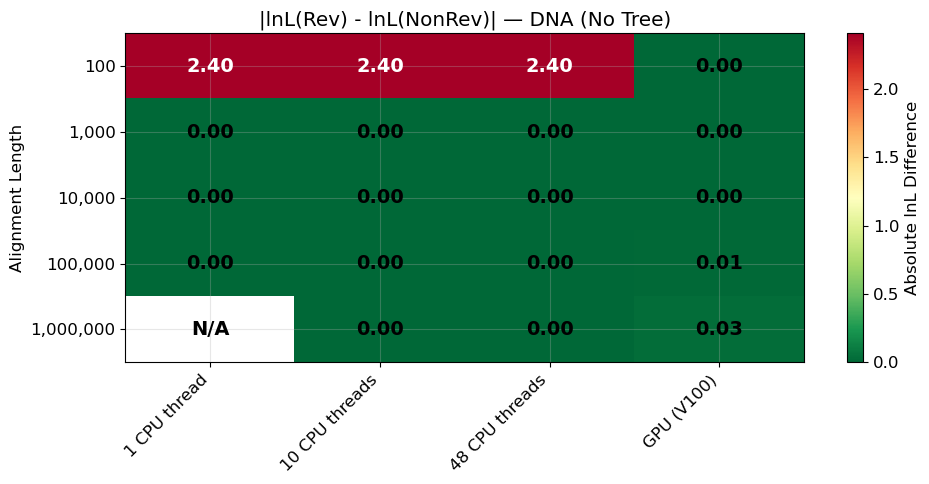

In [5]:
# Log-likelihood difference heatmap (DNA)
if 'abs_diff' in lnl_dna.columns:
    diff_pivot = lnl_dna['abs_diff'].unstack(level='backend_label')
    diff_pivot = diff_pivot[[c for c in backend_order if c in diff_pivot.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot.values, cmap='RdYlGn_r', aspect='auto',
                   norm=Normalize(vmin=0, vmax=max(diff_pivot.max().max(), 0.01)))
    ax.set_xticks(range(len(diff_pivot.columns)))
    ax.set_xticklabels(diff_pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — DNA (No Tree)')
    for i in range(len(diff_pivot.index)):
        for j in range(len(diff_pivot.columns)):
            val = diff_pivot.iloc[i, j]
            ax.text(j, i, f'{val:.2f}' if not pd.isna(val) else 'N/A',
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if val > diff_pivot.max().max()*0.5 else 'black')
    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_notree_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 3. Model Selection Agreement (DNA)

In [6]:
# Model selection comparison (DNA)
model_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label',
                                values='best_model', aggfunc='first')
print('Best-fit Model: Kernel-Rev vs Kernel-NonRev (DNA)')
for length in sorted(df_dna['length'].unique()):
    print(f'\n  Length = {length:,}:')
    for backend in backend_order:
        if (length, backend) in model_dna.index:
            row = model_dna.loc[(length, backend)]
            rev = row.get('Kernel-Rev', 'N/A')
            nonrev = row.get('Kernel-NonRev', 'N/A')
            match = 'MATCH' if rev == nonrev else 'DIFFER'
            print(f'    {backend:20s}  Rev: {str(rev):25s} NonRev: {str(nonrev):25s} [{match}]')

Best-fit Model: Kernel-Rev vs Kernel-NonRev (DNA)

  Length = 100:
    1 CPU thread          Rev: F81+F+ASC+G4              NonRev: F81+F+ASC+G4              [MATCH]
    10 CPU threads        Rev: F81+F+ASC+G4              NonRev: F81+F+ASC+G4              [MATCH]
    48 CPU threads        Rev: F81+F+ASC+G4              NonRev: F81+F+ASC+G4              [MATCH]
    GPU (V100)            Rev: F81+F+ASC+G4              NonRev: F81+F+ASC+G4              [MATCH]

  Length = 1,000:
    1 CPU thread          Rev: F81+F+G4                  NonRev: F81+F+G4                  [MATCH]
    10 CPU threads        Rev: F81+F+G4                  NonRev: F81+F+G4                  [MATCH]
    48 CPU threads        Rev: F81+F+G4                  NonRev: F81+F+G4                  [MATCH]
    GPU (V100)            Rev: F81+F+G4                  NonRev: F81+F+G4                  [MATCH]

  Length = 10,000:
    1 CPU thread          Rev: F81+F+G4                  NonRev: F81+F+G4                  [MATCH]
   

## 4. Wall-Clock Time Comparison (DNA)

In [7]:
# Wall-clock time pivot (DNA)
time_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label',
                               values='wall_time_sec', aggfunc='first')
if 'Kernel-Rev' in time_dna.columns and 'Kernel-NonRev' in time_dna.columns:
    time_dna['ratio_rev/nonrev'] = time_dna['Kernel-Rev'] / time_dna['Kernel-NonRev']
    time_dna['speedup_nonrev/rev'] = time_dna['Kernel-NonRev'] / time_dna['Kernel-Rev']
    time_dna['pct_change'] = (time_dna['Kernel-Rev'] - time_dna['Kernel-NonRev']) / time_dna['Kernel-NonRev'] * 100

print('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)')
print('ratio < 1 means Rev is FASTER; speedup > 1 means Rev is FASTER')
display(time_dna)

Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)
ratio < 1 means Rev is FASTER; speedup > 1 means Rev is FASTER


kernel_label            Kernel-NonRev   Kernel-Rev  ratio_rev/nonrev  \
length  backend_label                                                  
100     1 CPU thread          33.9045      21.3170          0.628737   
        10 CPU threads        54.3168     109.5810          2.017442   
        48 CPU threads        94.2549     277.3380          2.942425   
        GPU (V100)           500.7850     463.4770          0.925501   
1000    1 CPU thread         101.0050      83.3327          0.825035   
        10 CPU threads       104.1790      47.6061          0.456964   
        48 CPU threads       246.7260     255.7690          1.036652   
        GPU (V100)           312.3410     288.2480          0.922863   
10000   1 CPU thread        1016.0100     898.3770          0.884221   
        10 CPU threads       329.6120     236.6330          0.717914   
        48 CPU threads       291.8160     295.3040          1.011953   
        GPU (V100)           330.7980     350.4640          1.059450   
100000  1 CPU thread       10938.1900    9299.0190          0.850142   
        10 CPU threads      2816.2520    1429.3820          0.507548   
        48 CPU threads      1226.2410     967.3022          0.788835   
        GPU (V100)           988.6377     960.4503          0.971489   
1000000 1 CPU thread              NaN  160646.4300               NaN   
        10 CPU threads     36615.3810   29249.8340          0.798840   
        48 CPU threads     18850.7140   16874.4970          0.895165   
        GPU (V100)          9799.3471    7071.1780          0.721597   

kernel_label            speedup_nonrev/rev  pct_change  
length  backend_label                                   
100     1 CPU thread              1.590491  -37.126340  
        10 CPU threads            0.495677  101.744212  
        48 CPU threads            0.339856  194.242527  
        GPU (V100)                1.080496   -7.449904  
1000    1 CPU thread              1.212069  -17.496461  
        10 CPU threads            2.188354  -54.303554  
        48 CPU threads            0.964644    3.665199  
        GPU (V100)                1.083584   -7.713685  
10000   1 CPU thread              1.130939  -11.577937  
        10 CPU threads            1.392925  -28.208621  
        48 CPU threads            0.988188    1.195274  
        GPU (V100)                0.943886    5.945018  
100000  1 CPU thread              1.176274  -14.985761  
        10 CPU threads            1.970258  -49.245238  
        48 CPU threads            1.267692  -21.116469  
        GPU (V100)                1.029348   -2.851135  
1000000 1 CPU thread                   NaN         NaN  
        10 CPU threads            1.251815  -20.115992  
        48 CPU threads            1.117113  -10.483513  
        GPU (V100)                1.385815  -27.840315

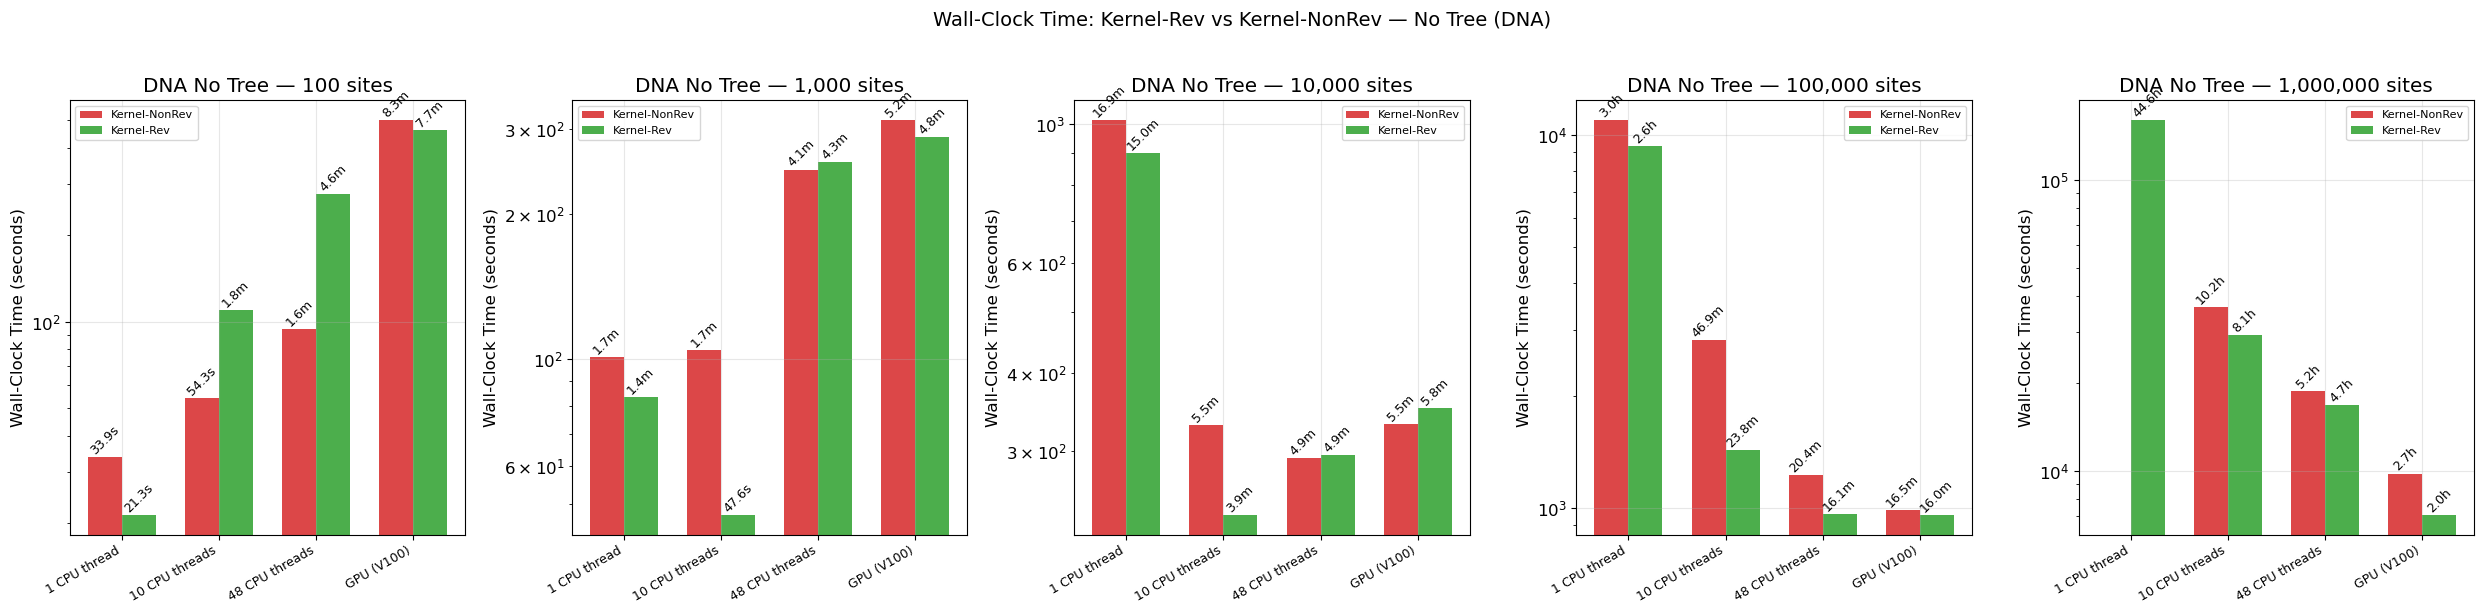

In [8]:
# Grouped bar chart: wall-clock time Rev vs NonRev (DNA)
dna_lengths = sorted(df_dna['length'].unique())
n = len(dna_lengths)
fig, axes = plt.subplots(1, n, figsize=(5*n, 6), sharey=False)
if n == 1: axes = [axes]

for ax, length in zip(axes, dna_lengths):
    sub = df_dna[df_dna['length'] == length]
    backends_present = [b for b in backend_order if b in sub['backend_label'].values]
    x = np.arange(len(backends_present))
    width = 0.35

    rev_times = [sub[(sub['backend_label']==b) & (sub['kernel_label']=='Kernel-Rev')]['wall_time_sec'].values
                 for b in backends_present]
    rev_times = [v[0] if len(v) > 0 else 0 for v in rev_times]
    nonrev_times = [sub[(sub['backend_label']==b) & (sub['kernel_label']=='Kernel-NonRev')]['wall_time_sec'].values
                    for b in backends_present]
    nonrev_times = [v[0] if len(v) > 0 else 0 for v in nonrev_times]

    bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
    bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

    for bar, val in zip(bars1, nonrev_times):
        if val > 0: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt_time(val),
                            ha='center', va='bottom', fontsize=9, rotation=45)
    for bar, val in zip(bars2, rev_times):
        if val > 0: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt_time(val),
                            ha='center', va='bottom', fontsize=9, rotation=45)

    ax.set_xticks(x)
    ax.set_xticklabels(backends_present, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'DNA No Tree — {length:,} sites')
    ax.set_yscale('log')
    ax.legend(fontsize=8)

plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev — No Tree (DNA)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'dna_notree_walltime_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Speedup Heatmap (DNA)

Ratio = NonRev_time / Rev_time. Values **> 1** mean Rev is faster.

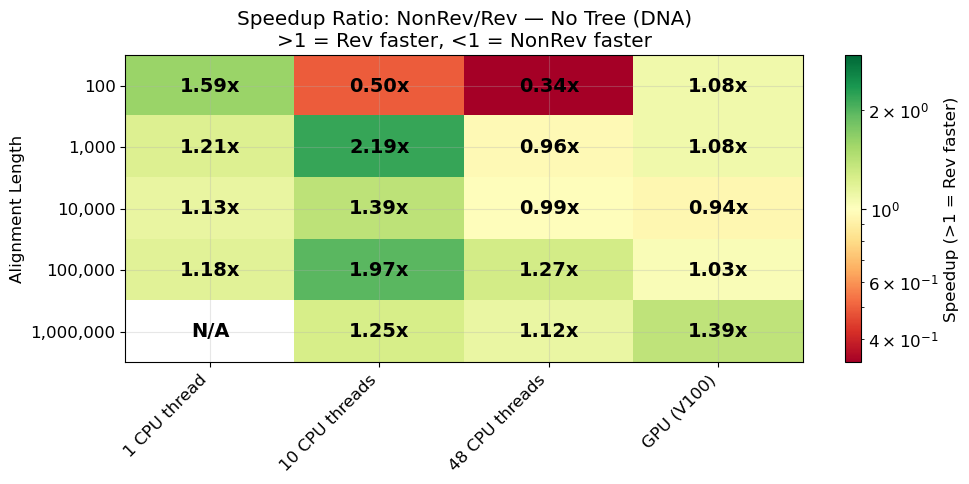

In [9]:
# Speedup heatmap: NonRev_time / Rev_time (DNA)
if 'Kernel-Rev' in time_dna.columns and 'Kernel-NonRev' in time_dna.columns:
    speedup = (time_dna['Kernel-NonRev'] / time_dna['Kernel-Rev']).unstack(level='backend_label')
    speedup = speedup[[c for c in backend_order if c in speedup.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    vmin = min(speedup.min().min(), 1/speedup.max().max())
    vmax = max(speedup.max().max(), 1/speedup.min().min())
    norm = LogNorm(vmin=vmin, vmax=vmax)

    im = ax.imshow(speedup.values, cmap='RdYlGn', norm=norm, aspect='auto')
    ax.set_xticks(range(len(speedup.columns)))
    ax.set_xticklabels(speedup.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev/Rev — No Tree (DNA)\n>1 = Rev faster, <1 = NonRev faster')
    for i in range(len(speedup.index)):
        for j in range(len(speedup.columns)):
            val = speedup.iloc[i, j]
            ax.text(j, i, f'{val:.2f}x' if not pd.isna(val) else 'N/A',
                    ha='center', va='center', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_notree_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 6. Time Breakdown: ModelFinder vs Tree Search (DNA)

Where does Rev gain/lose time? Compare ModelFinder vs tree search wall-clock time.

In [10]:
# Time breakdown: ModelFinder vs Tree Search (DNA)
breakdown_cols = ['data_type', 'length', 'kernel_label', 'backend_label',
                  'wall_time_sec', 'modelfinder_wall_sec', 'treesearch_wall_sec', 'nni_iterations']
breakdown_cols = [c for c in breakdown_cols if c in df_dna.columns]
breakdown_dna = df_dna[breakdown_cols].sort_values(['length', 'backend_label', 'kernel_label']).reset_index(drop=True)

if 'modelfinder_wall_sec' in breakdown_dna.columns and 'treesearch_wall_sec' in breakdown_dna.columns:
    breakdown_dna['mf_pct'] = (breakdown_dna['modelfinder_wall_sec'] / breakdown_dna['wall_time_sec'] * 100).round(1)
    breakdown_dna['ts_pct'] = (breakdown_dna['treesearch_wall_sec'] / breakdown_dna['wall_time_sec'] * 100).round(1)

print('Time Breakdown: DNA (No Tree)')
display(breakdown_dna)

Time Breakdown: DNA (No Tree)


,data_type,length,kernel_label,backend_label,wall_time_sec
0,DNA,100,Kernel-NonRev,1 CPU thread,33.9045
1,DNA,100,Kernel-Rev,1 CPU thread,21.3170
2,DNA,100,Kernel-NonRev,10 CPU threads,54.3168
3,DNA,100,Kernel-Rev,10 CPU threads,109.5810
4,DNA,100,Kernel-NonRev,48 CPU threads,94.2549
5,DNA,100,Kernel-Rev,48 CPU threads,277.3380
6,DNA,100,Kernel-NonRev,GPU (V100),500.7850
7,DNA,100,Kernel-Rev,GPU (V100),463.4770
8,DNA,1000,Kernel-NonRev,1 CPU thread,101.0050
9,DNA,1000,Kernel-Rev,1 CPU thread,83.3327


## 7. Wall-Clock Scaling by Alignment Length (DNA)

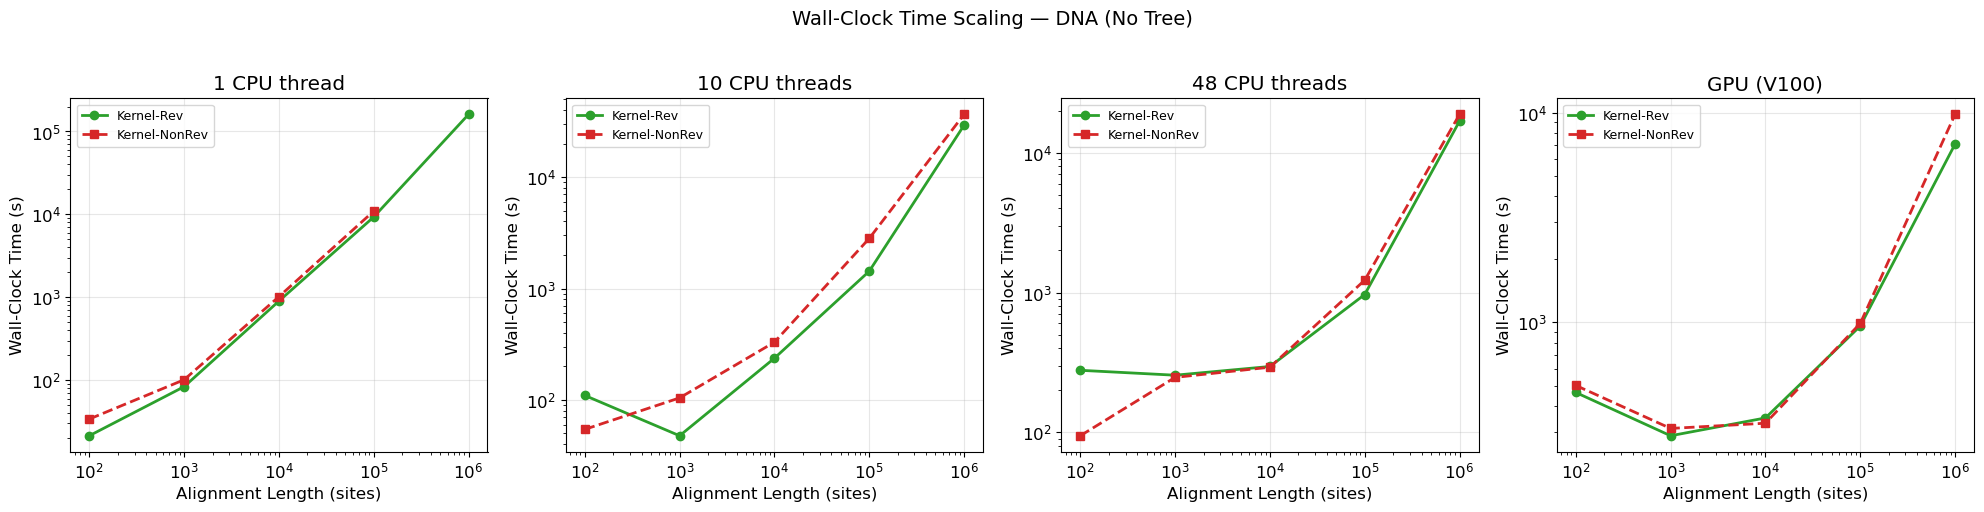

In [11]:
# Line plot: wall-clock time vs alignment length for each backend (DNA)
fig, axes = plt.subplots(1, len(backend_order), figsize=(5*len(backend_order), 5), sharey=False)

for ax, backend in zip(axes, backend_order):
    for kernel, color in kernel_colors.items():
        sub = df_dna[(df_dna['backend_label'] == backend) & (df_dna['kernel_label'] == kernel)]
        if len(sub) > 0:
            sub = sub.sort_values('length')
            ls = '-' if kernel == 'Kernel-Rev' else '--'
            marker = 'o' if kernel == 'Kernel-Rev' else 's'
            ax.plot(sub['length'], sub['wall_time_sec'], ls=ls, marker=marker, color=color,
                    label=kernel, linewidth=2, markersize=6)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (s)')
    ax.set_title(backend)
    ax.legend(fontsize=9)

plt.suptitle('Wall-Clock Time Scaling — DNA (No Tree)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'dna_notree_scaling.png'), dpi=150, bbox_inches='tight')
plt.show()

---
# Part 2: Amino Acid (Protein) Analysis

## 8. Correctness: Log-Likelihood Comparison (AA)

In [12]:
# Log-likelihood pivot: Rev vs NonRev (AA)
lnl_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label',
                            values='log_likelihood', aggfunc='first')
if 'Kernel-Rev' in lnl_aa.columns and 'Kernel-NonRev' in lnl_aa.columns:
    lnl_aa['abs_diff'] = (lnl_aa['Kernel-Rev'] - lnl_aa['Kernel-NonRev']).abs()

print('Log-Likelihood: Kernel-Rev vs Kernel-NonRev (AA)')
display(lnl_aa)

Log-Likelihood: Kernel-Rev vs Kernel-NonRev (AA)


kernel_label           Kernel-NonRev    Kernel-Rev  abs_diff
length backend_label                                        
100    1 CPU thread    -7.670271e+03 -7.670271e+03    0.0000
       10 CPU threads  -7.670271e+03 -7.670271e+03    0.0000
       48 CPU threads  -7.670271e+03 -7.670271e+03    0.0000
       GPU (V100)      -7.670271e+03 -7.670271e+03    0.0000
1000   1 CPU thread    -7.782396e+04 -7.782396e+04    0.0000
       10 CPU threads  -7.782396e+04 -7.782396e+04    0.0000
       48 CPU threads  -7.782396e+04 -7.782396e+04    0.0000
       GPU (V100)      -7.782396e+04 -7.782396e+04    0.0000
10000  1 CPU thread    -8.073500e+05 -8.073500e+05    0.0000
       10 CPU threads  -8.073500e+05 -8.073500e+05    0.0000
       48 CPU threads  -8.073500e+05 -8.073500e+05    0.0000
       GPU (V100)      -8.073500e+05 -8.073500e+05    0.0000
100000 10 CPU threads  -7.541977e+06 -7.541977e+06    0.0028
       48 CPU threads  -7.541977e+06 -7.541977e+06    0.0001
       GPU (V100)      -7.541977e+06 -7.541977e+06    0.0000

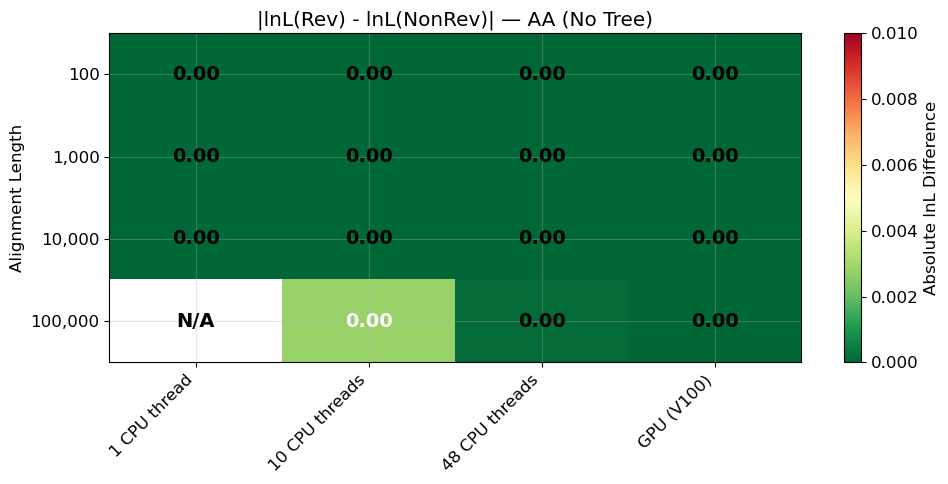

In [13]:
# Log-likelihood difference heatmap (AA)
if 'abs_diff' in lnl_aa.columns:
    diff_pivot_aa = lnl_aa['abs_diff'].unstack(level='backend_label')
    diff_pivot_aa = diff_pivot_aa[[c for c in backend_order if c in diff_pivot_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot_aa.values, cmap='RdYlGn_r', aspect='auto',
                   norm=Normalize(vmin=0, vmax=max(diff_pivot_aa.max().max(), 0.01)))
    ax.set_xticks(range(len(diff_pivot_aa.columns)))
    ax.set_xticklabels(diff_pivot_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — AA (No Tree)')
    for i in range(len(diff_pivot_aa.index)):
        for j in range(len(diff_pivot_aa.columns)):
            val = diff_pivot_aa.iloc[i, j]
            ax.text(j, i, f'{val:.2f}' if not pd.isna(val) else 'N/A',
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if val > diff_pivot_aa.max().max()*0.5 else 'black')
    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_notree_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 9. Model Selection Agreement (AA)

In [14]:
# Model selection comparison (AA)
model_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label',
                              values='best_model', aggfunc='first')
print('Best-fit Model: Kernel-Rev vs Kernel-NonRev (AA)')
for length in sorted(df_aa['length'].unique()):
    print(f'\n  Length = {length:,}:')
    for backend in backend_order:
        if (length, backend) in model_aa.index:
            row = model_aa.loc[(length, backend)]
            rev = row.get('Kernel-Rev', 'N/A')
            nonrev = row.get('Kernel-NonRev', 'N/A')
            match = 'MATCH' if rev == nonrev else 'DIFFER'
            print(f'    {backend:20s}  Rev: {str(rev):25s} NonRev: {str(nonrev):25s} [{match}]')

Best-fit Model: Kernel-Rev vs Kernel-NonRev (AA)

  Length = 100:
    1 CPU thread          Rev: LG+G4                     NonRev: LG+G4                     [MATCH]
    10 CPU threads        Rev: LG+G4                     NonRev: LG+G4                     [MATCH]
    48 CPU threads        Rev: LG+G4                     NonRev: LG+G4                     [MATCH]
    GPU (V100)            Rev: LG+G4                     NonRev: LG+G4                     [MATCH]

  Length = 1,000:
    1 CPU thread          Rev: LG+G4                     NonRev: LG+G4                     [MATCH]
    10 CPU threads        Rev: LG+G4                     NonRev: LG+G4                     [MATCH]
    48 CPU threads        Rev: LG+G4                     NonRev: LG+G4                     [MATCH]
    GPU (V100)            Rev: LG+G4                     NonRev: LG+G4                     [MATCH]

  Length = 10,000:
    1 CPU thread          Rev: LG+G4                     NonRev: LG+G4                     [MATCH]
    

## 10. Wall-Clock Time Comparison (AA)

In [15]:
# Wall-clock time pivot (AA)
time_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label',
                             values='wall_time_sec', aggfunc='first')
if 'Kernel-Rev' in time_aa.columns and 'Kernel-NonRev' in time_aa.columns:
    time_aa['ratio_rev/nonrev'] = time_aa['Kernel-Rev'] / time_aa['Kernel-NonRev']
    time_aa['speedup_nonrev/rev'] = time_aa['Kernel-NonRev'] / time_aa['Kernel-Rev']
    time_aa['pct_change'] = (time_aa['Kernel-Rev'] - time_aa['Kernel-NonRev']) / time_aa['Kernel-NonRev'] * 100

print('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)')
print('ratio < 1 means Rev is FASTER; speedup > 1 means Rev is FASTER')
display(time_aa)

Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)
ratio < 1 means Rev is FASTER; speedup > 1 means Rev is FASTER


kernel_label           Kernel-NonRev  Kernel-Rev  ratio_rev/nonrev  \
length backend_label                                                 
100    1 CPU thread          679.974    154.8040          0.227662   
       10 CPU threads        462.204    181.8700          0.393484   
       48 CPU threads        465.576     84.8658          0.182281   
       GPU (V100)            543.152    431.9150          0.795201   
1000   1 CPU thread         2576.620   1207.1900          0.468517   
       10 CPU threads        632.140    325.0090          0.514141   
       48 CPU threads        582.933    261.1890          0.448060   
       GPU (V100)            482.685    374.8770          0.776649   
10000  1 CPU thread        21609.600  11376.1000          0.526437   
       10 CPU threads       2605.340   1571.8000          0.603299   
       48 CPU threads       1169.630    658.1430          0.562693   
       GPU (V100)           1028.440   1017.8000          0.989654   
100000 10 CPU threads      22682.080  12406.6000          0.546978   
       48 CPU threads       6484.726   4704.7170          0.725507   
       GPU (V100)           5820.965   6608.3510          1.135267   

kernel_label           speedup_nonrev/rev  pct_change  
length backend_label                                   
100    1 CPU thread              4.392483  -77.233835  
       10 CPU threads            2.541398  -60.651574  
       48 CPU threads            5.486026  -81.771870  
       GPU (V100)                1.257544  -20.479902  
1000   1 CPU thread              2.134395  -53.148311  
       10 CPU threads            1.944992  -48.585915  
       48 CPU threads            2.231844  -55.193993  
       GPU (V100)                1.287582  -22.335063  
10000  1 CPU thread              1.899561  -47.356268  
       10 CPU threads            1.657552  -39.670062  
       48 CPU threads            1.777167  -43.730667  
       GPU (V100)                1.010454   -1.034577  
100000 10 CPU threads            1.828227  -45.302195  
       48 CPU threads            1.378346  -27.449255  
       GPU (V100)                0.880850   13.526726

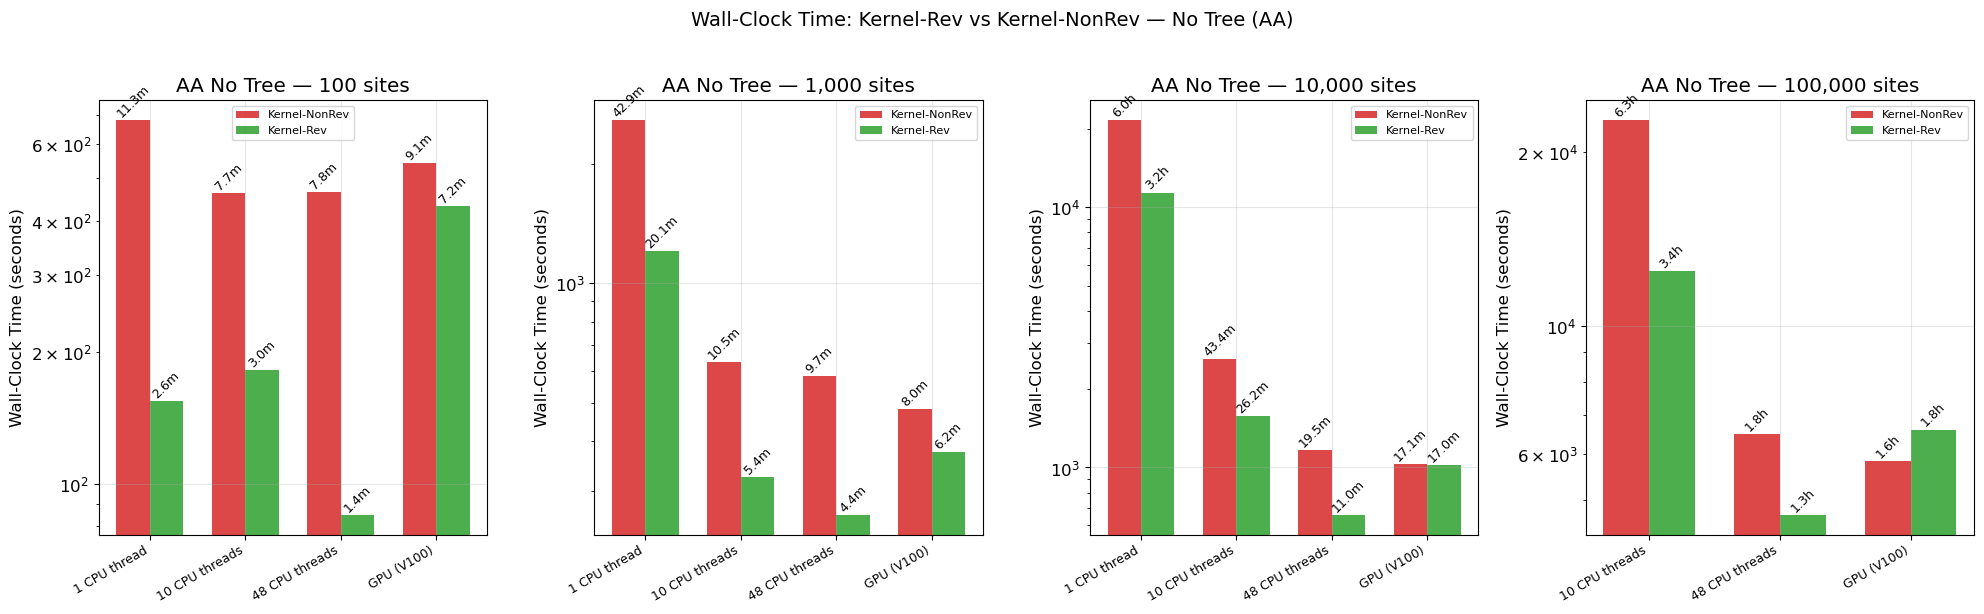

In [16]:
# Grouped bar chart: wall-clock time Rev vs NonRev (AA)
aa_lengths = sorted(df_aa['length'].unique())
n = len(aa_lengths)
fig, axes = plt.subplots(1, n, figsize=(5*n, 6), sharey=False)
if n == 1: axes = [axes]

for ax, length in zip(axes, aa_lengths):
    sub = df_aa[df_aa['length'] == length]
    backends_present = [b for b in backend_order if b in sub['backend_label'].values]
    x = np.arange(len(backends_present))
    width = 0.35

    rev_times = [sub[(sub['backend_label']==b) & (sub['kernel_label']=='Kernel-Rev')]['wall_time_sec'].values
                 for b in backends_present]
    rev_times = [v[0] if len(v) > 0 else 0 for v in rev_times]
    nonrev_times = [sub[(sub['backend_label']==b) & (sub['kernel_label']=='Kernel-NonRev')]['wall_time_sec'].values
                    for b in backends_present]
    nonrev_times = [v[0] if len(v) > 0 else 0 for v in nonrev_times]

    bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
    bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

    for bar, val in zip(bars1, nonrev_times):
        if val > 0: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt_time(val),
                            ha='center', va='bottom', fontsize=9, rotation=45)
    for bar, val in zip(bars2, rev_times):
        if val > 0: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt_time(val),
                            ha='center', va='bottom', fontsize=9, rotation=45)

    ax.set_xticks(x)
    ax.set_xticklabels(backends_present, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'AA No Tree — {length:,} sites')
    ax.set_yscale('log')
    ax.legend(fontsize=8)

plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev — No Tree (AA)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'aa_notree_walltime_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Speedup Heatmap (AA)

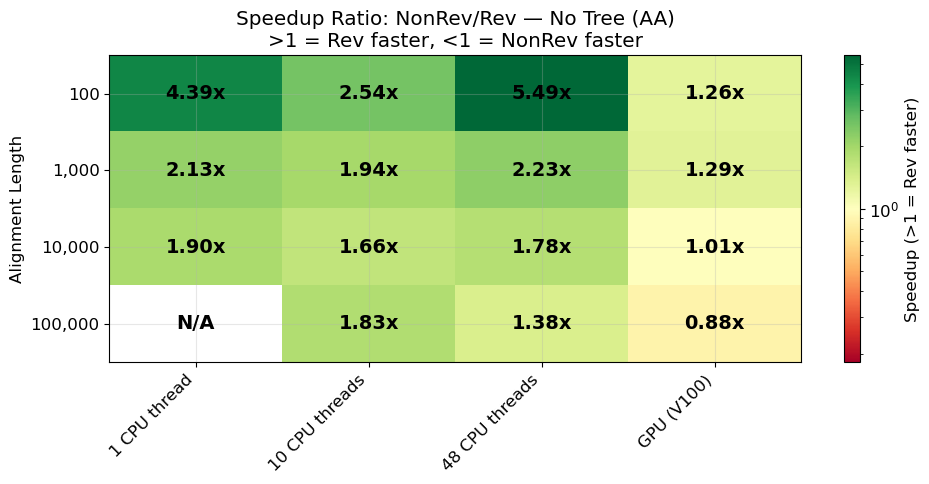

In [17]:
# Speedup heatmap: NonRev_time / Rev_time (AA)
if 'Kernel-Rev' in time_aa.columns and 'Kernel-NonRev' in time_aa.columns:
    speedup_aa = (time_aa['Kernel-NonRev'] / time_aa['Kernel-Rev']).unstack(level='backend_label')
    speedup_aa = speedup_aa[[c for c in backend_order if c in speedup_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    vmin_aa = min(speedup_aa.min().min(), 1/speedup_aa.max().max())
    vmax_aa = max(speedup_aa.max().max(), 1/speedup_aa.min().min())
    norm_aa = LogNorm(vmin=vmin_aa, vmax=vmax_aa)

    im = ax.imshow(speedup_aa.values, cmap='RdYlGn', norm=norm_aa, aspect='auto')
    ax.set_xticks(range(len(speedup_aa.columns)))
    ax.set_xticklabels(speedup_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev/Rev — No Tree (AA)\n>1 = Rev faster, <1 = NonRev faster')
    for i in range(len(speedup_aa.index)):
        for j in range(len(speedup_aa.columns)):
            val = speedup_aa.iloc[i, j]
            ax.text(j, i, f'{val:.2f}x' if not pd.isna(val) else 'N/A',
                    ha='center', va='center', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_notree_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 12. Time Breakdown: ModelFinder vs Tree Search (AA)

In [18]:
# Time breakdown: ModelFinder vs Tree Search (AA)
breakdown_cols = ['data_type', 'length', 'kernel_label', 'backend_label',
                  'wall_time_sec', 'modelfinder_wall_sec', 'treesearch_wall_sec', 'nni_iterations']
breakdown_cols = [c for c in breakdown_cols if c in df_aa.columns]
breakdown_aa = df_aa[breakdown_cols].sort_values(['length', 'backend_label', 'kernel_label']).reset_index(drop=True)

if 'modelfinder_wall_sec' in breakdown_aa.columns and 'treesearch_wall_sec' in breakdown_aa.columns:
    breakdown_aa['mf_pct'] = (breakdown_aa['modelfinder_wall_sec'] / breakdown_aa['wall_time_sec'] * 100).round(1)
    breakdown_aa['ts_pct'] = (breakdown_aa['treesearch_wall_sec'] / breakdown_aa['wall_time_sec'] * 100).round(1)

print('Time Breakdown: AA (No Tree)')
display(breakdown_aa)

Time Breakdown: AA (No Tree)


,data_type,length,kernel_label,backend_label,wall_time_sec
0,AA,100,Kernel-NonRev,1 CPU thread,679.9740
1,AA,100,Kernel-Rev,1 CPU thread,154.8040
2,AA,100,Kernel-NonRev,10 CPU threads,462.2040
3,AA,100,Kernel-Rev,10 CPU threads,181.8700
4,AA,100,Kernel-NonRev,48 CPU threads,465.5760
5,AA,100,Kernel-Rev,48 CPU threads,84.8658
6,AA,100,Kernel-NonRev,GPU (V100),543.1520
7,AA,100,Kernel-Rev,GPU (V100),431.9150
8,AA,1000,Kernel-NonRev,1 CPU thread,2576.6200
9,AA,1000,Kernel-Rev,1 CPU thread,1207.1900


## 13. Wall-Clock Scaling by Alignment Length (AA)

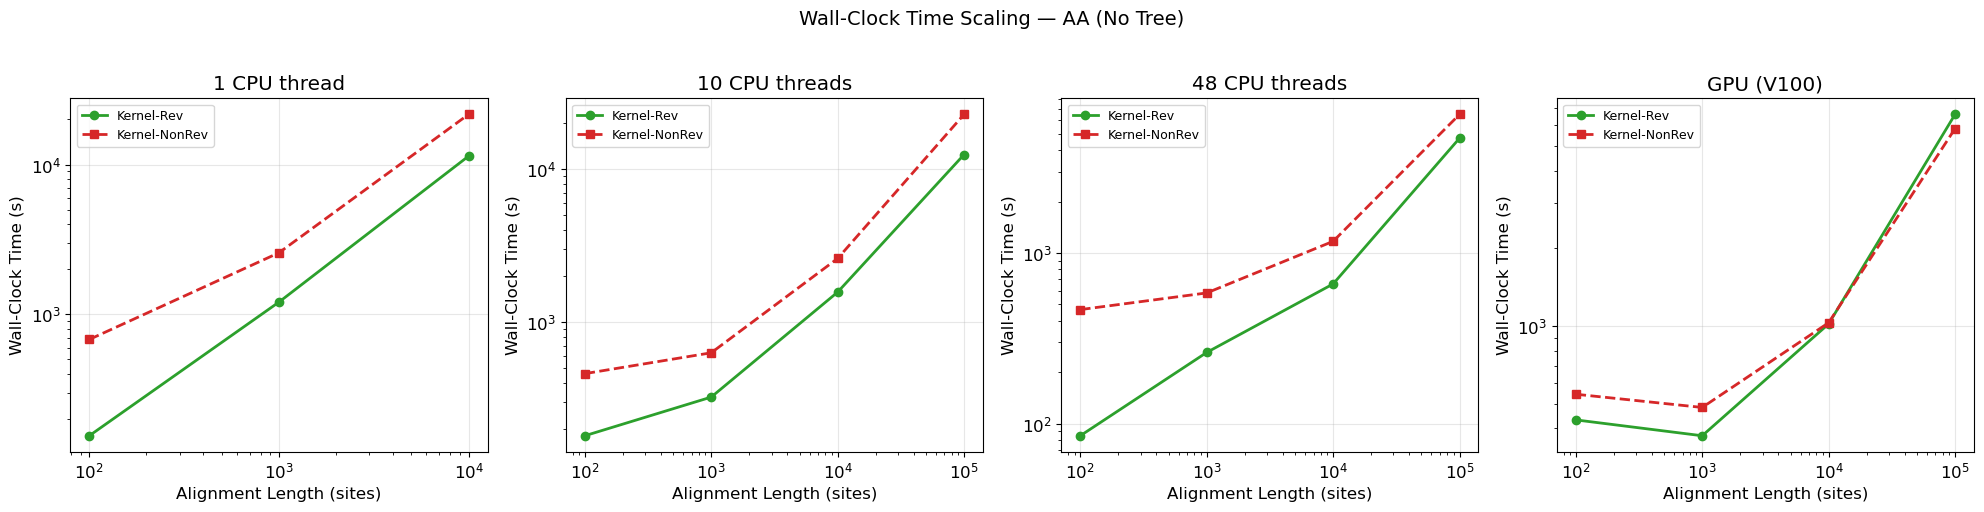

In [19]:
# Line plot: wall-clock time vs alignment length for each backend (AA)
fig, axes = plt.subplots(1, len(backend_order), figsize=(5*len(backend_order), 5), sharey=False)

for ax, backend in zip(axes, backend_order):
    for kernel, color in kernel_colors.items():
        sub = df_aa[(df_aa['backend_label'] == backend) & (df_aa['kernel_label'] == kernel)]
        if len(sub) > 0:
            sub = sub.sort_values('length')
            ls = '-' if kernel == 'Kernel-Rev' else '--'
            marker = 'o' if kernel == 'Kernel-Rev' else 's'
            ax.plot(sub['length'], sub['wall_time_sec'], ls=ls, marker=marker, color=color,
                    label=kernel, linewidth=2, markersize=6)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (s)')
    ax.set_title(backend)
    ax.legend(fontsize=9)

plt.suptitle('Wall-Clock Time Scaling — AA (No Tree)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'aa_notree_scaling.png'), dpi=150, bbox_inches='tight')
plt.show()

---
# Part 3: Combined DNA vs AA Comparison

## 14. Side-by-Side Speedup Heatmaps

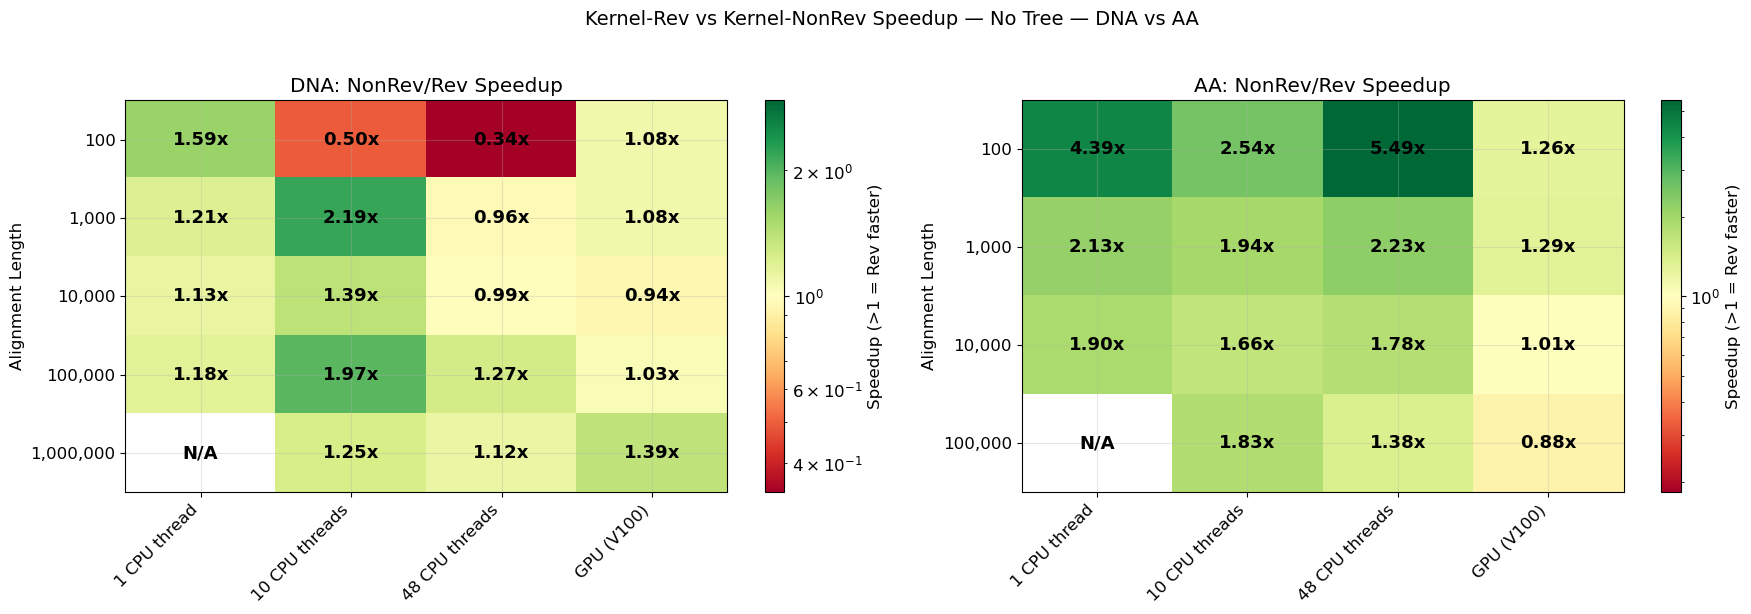

In [20]:
# Combined side-by-side speedup heatmaps: DNA vs AA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for ax, dtype, time_pivot, title in [
    (ax1, 'DNA', time_dna, 'DNA: NonRev/Rev Speedup'),
    (ax2, 'AA', time_aa, 'AA: NonRev/Rev Speedup')
]:
    if 'Kernel-Rev' not in time_pivot.columns or 'Kernel-NonRev' not in time_pivot.columns:
        continue
    sp = (time_pivot['Kernel-NonRev'] / time_pivot['Kernel-Rev']).unstack(level='backend_label')
    sp = sp[[c for c in backend_order if c in sp.columns]]

    vmin = min(sp.min().min(), 1/sp.max().max())
    vmax = max(sp.max().max(), 1/sp.min().min())
    norm = LogNorm(vmin=vmin, vmax=vmax)

    im = ax.imshow(sp.values, cmap='RdYlGn', norm=norm, aspect='auto')
    ax.set_xticks(range(len(sp.columns)))
    ax.set_xticklabels(sp.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(sp.index)))
    ax.set_yticklabels([f'{l:,}' for l in sp.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title(title)
    for i in range(len(sp.index)):
        for j in range(len(sp.columns)):
            val = sp.iloc[i, j]
            ax.text(j, i, f'{val:.2f}x' if not pd.isna(val) else 'N/A',
                    ha='center', va='center', fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')

plt.suptitle('Kernel-Rev vs Kernel-NonRev Speedup — No Tree — DNA vs AA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'combined_notree_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Combined Wall-Clock Time Lines (All Backends)

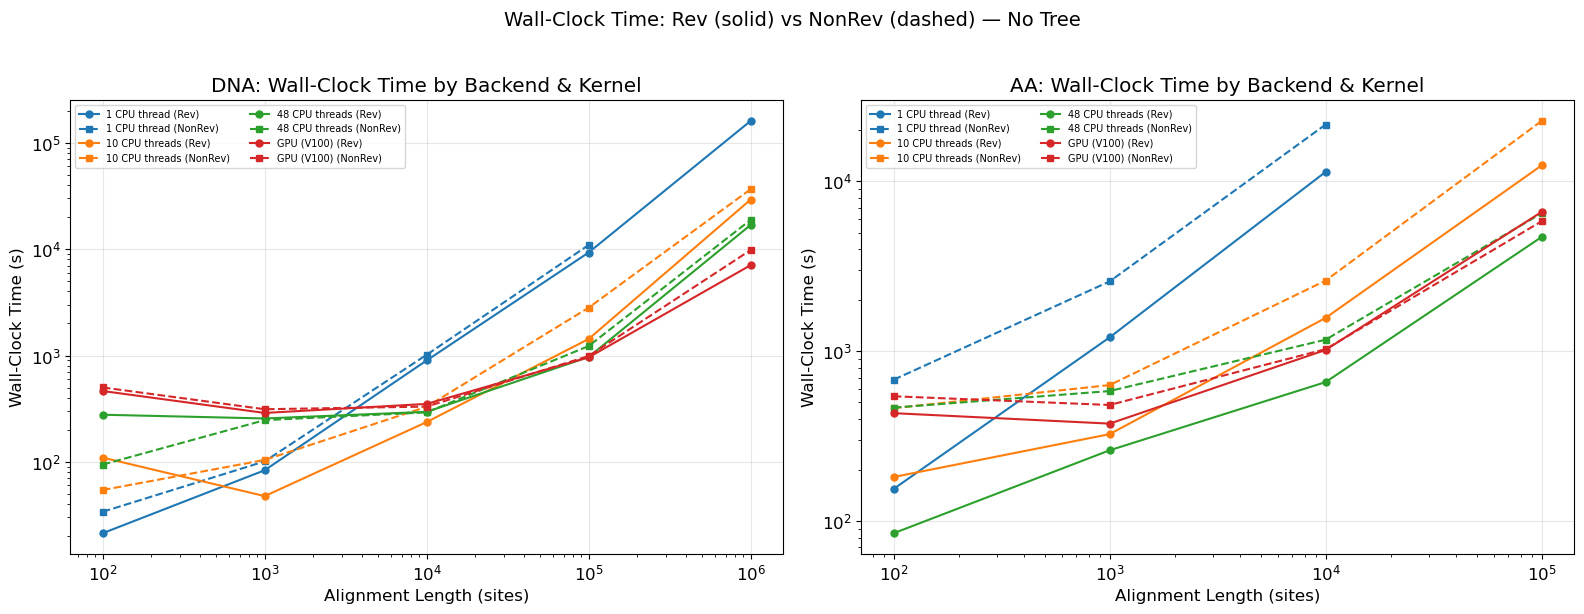

In [21]:
# Combined wall-time line plot: DNA and AA side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

backend_colors_list = {'1 CPU thread': '#1f77b4', '10 CPU threads': '#ff7f0e',
                        '48 CPU threads': '#2ca02c', 'GPU (V100)': '#d62728'}

for ax, dtype, df_sub, title in [(ax1, 'DNA', df_dna, 'DNA'), (ax2, 'AA', df_aa, 'AA')]:
    for backend in backend_order:
        color = backend_colors_list[backend]
        for kernel in ['Kernel-Rev', 'Kernel-NonRev']:
            sub = df_sub[(df_sub['backend_label'] == backend) & (df_sub['kernel_label'] == kernel)]
            if len(sub) == 0: continue
            sub = sub.sort_values('length')
            ls = '-' if kernel == 'Kernel-Rev' else '--'
            marker = 'o' if kernel == 'Kernel-Rev' else 's'
            label = f'{backend} ({kernel.split("-")[1]})'
            ax.plot(sub['length'], sub['wall_time_sec'], ls=ls, marker=marker, color=color,
                    label=label, linewidth=1.5, markersize=5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (s)')
    ax.set_title(f'{title}: Wall-Clock Time by Backend & Kernel')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('Wall-Clock Time: Rev (solid) vs NonRev (dashed) — No Tree', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'combined_notree_walltime_lines.png'), dpi=150, bbox_inches='tight')
plt.show()

## 16. Summary Table: All Results

In [22]:
# Final summary: speedup for every (data_type, length, backend) pair
summary_rows = []
for dtype, df_sub in [('DNA', df_dna), ('AA', df_aa)]:
    for length in sorted(df_sub['length'].unique()):
        for backend in backend_order:
            rev = df_sub[(df_sub['length']==length) & (df_sub['backend_label']==backend) & (df_sub['kernel_label']=='Kernel-Rev')]
            nonrev = df_sub[(df_sub['length']==length) & (df_sub['backend_label']==backend) & (df_sub['kernel_label']=='Kernel-NonRev')]
            if len(rev) == 0 or len(nonrev) == 0:
                continue
            rev_t = rev['wall_time_sec'].values[0]
            nonrev_t = nonrev['wall_time_sec'].values[0]
            rev_lnl = rev['log_likelihood'].values[0] if 'log_likelihood' in rev.columns else None
            nonrev_lnl = nonrev['log_likelihood'].values[0] if 'log_likelihood' in nonrev.columns else None
            lnl_diff = abs(rev_lnl - nonrev_lnl) if rev_lnl is not None and nonrev_lnl is not None else None

            speedup = nonrev_t / rev_t
            if speedup >= 1:
                verdict = f'Rev {speedup:.2f}x FASTER'
            else:
                verdict = f'NonRev {1/speedup:.2f}x FASTER'

            summary_rows.append({
                'Type': dtype, 'Length': f'{length:,}', 'Backend': backend,
                'NonRev (s)': round(nonrev_t, 1), 'Rev (s)': round(rev_t, 1),
                'Speedup': round(speedup, 2), 'Verdict': verdict,
                '|lnL diff|': round(lnl_diff, 2) if lnl_diff is not None else 'N/A'
            })

summary_df = pd.DataFrame(summary_rows)
print('=== FULL SUMMARY: Kernel-Rev vs Kernel-NonRev (No Tree) ===')
print('Speedup > 1 means Rev is faster; < 1 means NonRev is faster')
print()
display(summary_df)

=== FULL SUMMARY: Kernel-Rev vs Kernel-NonRev (No Tree) ===
Speedup > 1 means Rev is faster; < 1 means NonRev is faster



,Type,Length,Backend,NonRev (s),Rev (s),Speedup,Verdict,|lnL diff|
0,DNA,100,1 CPU thread,33.9,21.3,1.59,Rev 1.59x FASTER,2.40
1,DNA,100,10 CPU threads,54.3,109.6,0.50,NonRev 2.02x FASTER,2.40
2,DNA,100,48 CPU threads,94.3,277.3,0.34,NonRev 2.94x FASTER,2.40
3,DNA,100,GPU (V100),500.8,463.5,1.08,Rev 1.08x FASTER,0.00
4,DNA,"1,000",1 CPU thread,101.0,83.3,1.21,Rev 1.21x FASTER,0.00
5,DNA,"1,000",10 CPU threads,104.2,47.6,2.19,Rev 2.19x FASTER,0.00
6,DNA,"1,000",48 CPU threads,246.7,255.8,0.96,NonRev 1.04x FASTER,0.00
7,DNA,"1,000",GPU (V100),312.3,288.2,1.08,Rev 1.08x FASTER,0.00
8,DNA,"10,000",1 CPU thread,1016.0,898.4,1.13,Rev 1.13x FASTER,0.00
9,DNA,"10,000",10 CPU threads,329.6,236.6,1.39,Rev 1.39x FASTER,0.00


---
# Part 4: Two-Phase GPU Kernel Results

The Two-Phase optimization splits each fused REV GPU kernel into:
- **Phase 1**: Compute eigenspace forward-transform products (no thread redundancy)
- **Phase 2**: V^-1 back-transform from shared eigenspace products

This reduces partial LH cost from **2c^3** to **3c^2** (13x reduction for AA c=20).

## 17. Load Two-Phase Results

In [23]:
# Load Two-Phase GPU results
def load_2phase_results():
    """Load 2phase GPU-only results (no-tree runs)."""
    records = []
    lengths = [100, 1000, 10000, 100000, 1000000, 10000000]
    data_types = ['DNA', 'AA']

    for data_type in data_types:
        for length in lengths:
            len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
            if not os.path.isdir(len_dir): continue

            # 2phase Rev (without kernelnonrev in name)
            for pat in [os.path.join(len_dir, f'output_fulltest_2phase_{data_type}_*_OPENACC_*.iqtree')]:
                files = [f for f in glob.glob(pat) if 'kernelnonrev' not in os.path.basename(f)]
                if files:
                    data = parse_iqtree_file(files[0])
                    if data and 'wall_time_sec' in data:
                        data.update(length=length, kernel_label='2Phase-Rev',
                                   backend_label='GPU (V100)', data_type=data_type)
                        records.append(data)
                    break

            # 2phase NonRev
            for pat in [os.path.join(len_dir, f'output_fulltest_2phase_kernelnonrev_{data_type}_*_OPENACC_*.iqtree')]:
                files = glob.glob(pat)
                if files:
                    data = parse_iqtree_file(files[0])
                    if data and 'wall_time_sec' in data:
                        data.update(length=length, kernel_label='2Phase-NonRev',
                                   backend_label='GPU (V100)', data_type=data_type)
                        records.append(data)
                    break

    return pd.DataFrame(records)

df_2p = load_2phase_results()
df_2p_dna = df_2p[df_2p['data_type'] == 'DNA'].copy()
df_2p_aa = df_2p[df_2p['data_type'] == 'AA'].copy()
print(f'Two-Phase records: {len(df_2p)} (DNA: {len(df_2p_dna)}, AA: {len(df_2p_aa)})')
print(f"Lengths: {sorted(df_2p['length'].unique())}")
print(f"Kernels: {sorted(df_2p['kernel_label'].unique())}")
display(df_2p[['data_type','length','kernel_label','best_model','log_likelihood','wall_time_sec']].sort_values(['data_type','length','kernel_label']))

Two-Phase records: 18 (DNA: 10, AA: 8)
Lengths: [100, 1000, 10000, 100000, 1000000]
Kernels: ['2Phase-NonRev', '2Phase-Rev']


,data_type,length,kernel_label,best_model,log_likelihood,wall_time_sec
11,AA,100,2Phase-NonRev,LG+G4,-7.670271e+03,567.1490
10,AA,100,2Phase-Rev,LG+G4,-7.670271e+03,430.4740
13,AA,1000,2Phase-NonRev,LG+G4,-7.782396e+04,505.9250
12,AA,1000,2Phase-Rev,LG+G4,-7.782396e+04,388.5840
15,AA,10000,2Phase-NonRev,LG+G4,-8.073500e+05,1025.5900
14,AA,10000,2Phase-Rev,LG+G4,-8.073500e+05,1030.3600
17,AA,100000,2Phase-NonRev,LG+G4,-7.541977e+06,6768.7860
16,AA,100000,2Phase-Rev,LG+G4,-7.541977e+06,6597.6070
1,DNA,100,2Phase-NonRev,F81+F+ASC+G4,-4.894189e+03,481.8410
0,DNA,100,2Phase-Rev,F81+F+ASC+G4,-4.894189e+03,459.3090


In [24]:
# Build combined GPU comparison: Original Rev, Original NonRev, 2Phase Rev, 2Phase NonRev
# Original no-tree GPU results
df_orig_gpu = df[(df['backend_label'] == 'GPU (V100)')].copy()
df_orig_gpu['kernel_label'] = df_orig_gpu['kernel_label'].map({'Kernel-Rev': 'Fused-Rev', 'Kernel-NonRev': 'Fused-NonRev'})

# Combine
df_gpu_all = pd.concat([df_orig_gpu, df_2p], ignore_index=True)

# Pivot for comparison
for dtype, label in [('AA', 'Amino Acid'), ('DNA', 'DNA')]:
    sub = df_gpu_all[df_gpu_all['data_type'] == dtype]
    if len(sub) == 0: continue
    pivot_time = sub.pivot_table(index='length', columns='kernel_label', values='wall_time_sec', aggfunc='first')
    pivot_lnl = sub.pivot_table(index='length', columns='kernel_label', values='log_likelihood', aggfunc='first')

    # Reorder columns
    col_order = [c for c in ['Fused-NonRev', 'Fused-Rev', '2Phase-NonRev', '2Phase-Rev'] if c in pivot_time.columns]
    pivot_time = pivot_time[col_order]

    # Add speedup columns
    if '2Phase-Rev' in pivot_time.columns and 'Fused-Rev' in pivot_time.columns:
        pivot_time['Speedup (2P-Rev vs Fused-Rev)'] = (pivot_time['Fused-Rev'] / pivot_time['2Phase-Rev']).round(2)
    if '2Phase-Rev' in pivot_time.columns and 'Fused-NonRev' in pivot_time.columns:
        pivot_time['Speedup (2P-Rev vs Fused-NR)'] = (pivot_time['Fused-NonRev'] / pivot_time['2Phase-Rev']).round(2)

    print(f'\n=== GPU Wall-Clock Time Comparison: {label} ===')
    print('Speedup > 1 means Two-Phase is faster')
    display(pivot_time.round(1))

    # lnL comparison
    if len(pivot_lnl.columns) >= 2:
        pivot_lnl = pivot_lnl[[c for c in col_order if c in pivot_lnl.columns]]
        print(f'\nLog-Likelihood ({label}):')
        display(pivot_lnl.round(4))


=== GPU Wall-Clock Time Comparison: Amino Acid ===
Speedup > 1 means Two-Phase is faster


kernel_label,Fused-NonRev,Fused-Rev,2Phase-NonRev,2Phase-Rev,Speedup (2P-Rev vs Fused-Rev),Speedup (2P-Rev vs Fused-NR)
length,,,,,,
100,543.2,431.9,567.1,430.5,1.0,1.3
1000,482.7,374.9,505.9,388.6,1.0,1.2
10000,1028.4,1017.8,1025.6,1030.4,1.0,1.0
100000,5821.0,6608.4,6768.8,6597.6,1.0,0.9



Log-Likelihood (Amino Acid):


kernel_label,Fused-NonRev,Fused-Rev,2Phase-NonRev,2Phase-Rev
length,,,,
100,-7.670271e+03,-7.670271e+03,-7.670271e+03,-7.670271e+03
1000,-7.782396e+04,-7.782396e+04,-7.782396e+04,-7.782396e+04
10000,-8.073500e+05,-8.073500e+05,-8.073500e+05,-8.073500e+05
100000,-7.541977e+06,-7.541977e+06,-7.541977e+06,-7.541977e+06



=== GPU Wall-Clock Time Comparison: DNA ===
Speedup > 1 means Two-Phase is faster


kernel_label,Fused-NonRev,Fused-Rev,2Phase-NonRev,2Phase-Rev,Speedup (2P-Rev vs Fused-Rev),Speedup (2P-Rev vs Fused-NR)
length,,,,,,
100,500.8,463.5,481.8,459.3,1.0,1.1
1000,312.3,288.2,308.8,305.9,0.9,1.0
10000,330.8,350.5,324.0,359.2,1.0,0.9
100000,988.6,960.5,1029.5,966.0,1.0,1.0
1000000,9799.3,7071.2,9610.8,7110.0,1.0,1.4



Log-Likelihood (DNA):


kernel_label,Fused-NonRev,Fused-Rev,2Phase-NonRev,2Phase-Rev
length,,,,
100,-4.894189e+03,-4.894189e+03,-4.894189e+03,-4.894189e+03
1000,-5.618029e+04,-5.618029e+04,-5.618029e+04,-5.618029e+04
10000,-5.642088e+05,-5.642088e+05,-5.642088e+05,-5.642088e+05
100000,-5.692985e+06,-5.692985e+06,-5.692985e+06,-5.692985e+06
1000000,-5.920802e+07,-5.920802e+07,-5.920802e+07,-5.920802e+07


## 18. GPU Wall-Clock Time: Fused vs Two-Phase (Bar Chart)

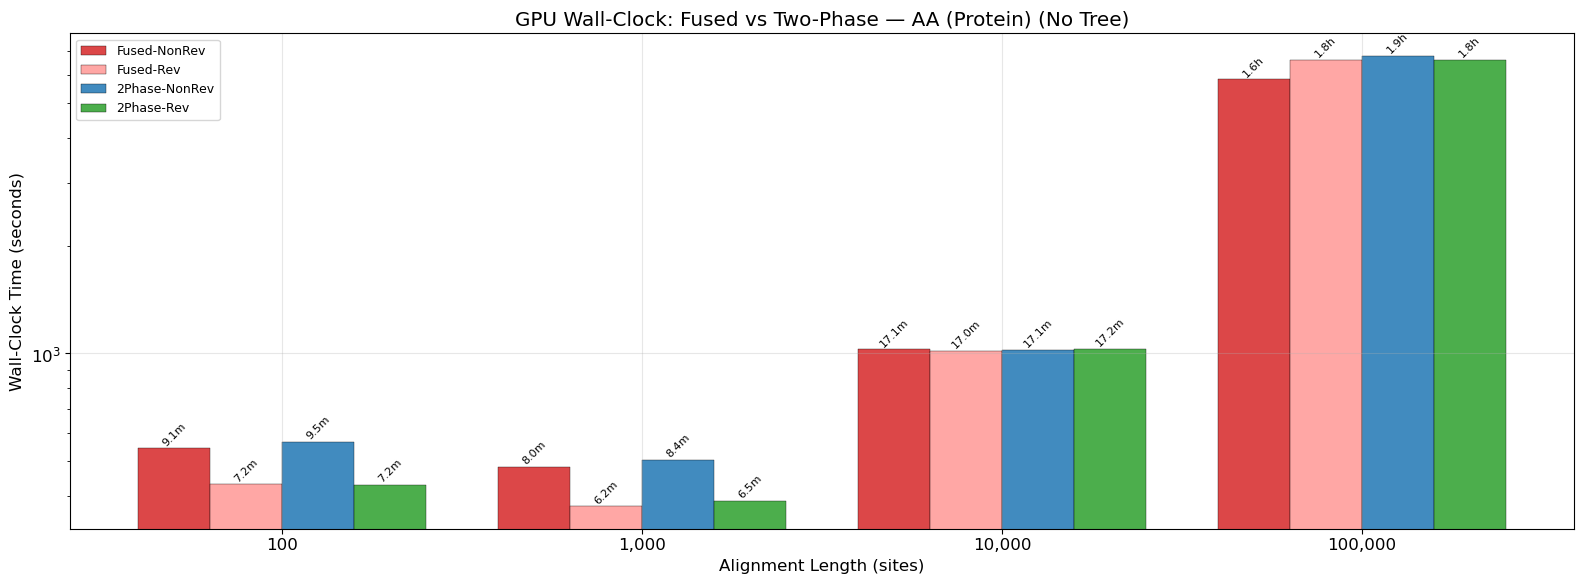

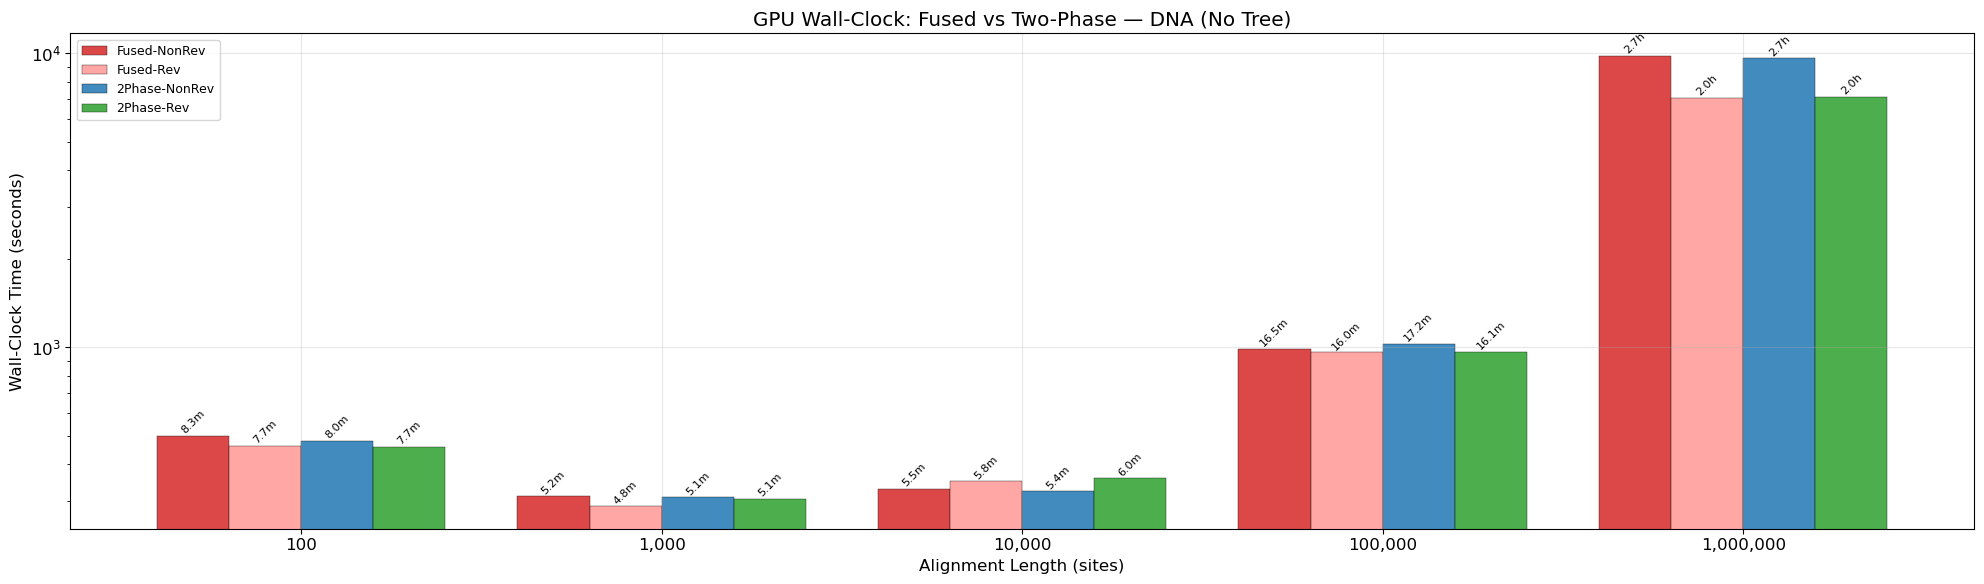

In [25]:
# Grouped bar chart: Fused-Rev, Fused-NonRev, 2Phase-Rev, 2Phase-NonRev per alignment length
kernel_order = ['Fused-NonRev', 'Fused-Rev', '2Phase-NonRev', '2Phase-Rev']
bar_colors = {'Fused-NonRev': '#d62728', 'Fused-Rev': '#ff9896',
              '2Phase-NonRev': '#1f77b4', '2Phase-Rev': '#2ca02c'}

for dtype, label in [('AA', 'AA (Protein)'), ('DNA', 'DNA')]:
    sub = df_gpu_all[df_gpu_all['data_type'] == dtype]
    if len(sub) == 0: continue
    lengths = sorted(sub['length'].unique())
    kernels_present = [k for k in kernel_order if k in sub['kernel_label'].unique()]
    n_kern = len(kernels_present)
    n_len = len(lengths)

    fig, ax = plt.subplots(figsize=(4 * n_len, 6))
    x = np.arange(n_len)
    width = 0.8 / n_kern

    for ki, kernel in enumerate(kernels_present):
        times = []
        for length in lengths:
            row = sub[(sub['length'] == length) & (sub['kernel_label'] == kernel)]
            times.append(row['wall_time_sec'].values[0] if len(row) > 0 else 0)
        offset = (ki - n_kern/2 + 0.5) * width
        bars = ax.bar(x + offset, times, width, label=kernel, color=bar_colors.get(kernel, '#999'),
                      alpha=0.85, edgecolor='black', linewidth=0.3)
        for bar, val in zip(bars, times):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        fmt_time(val), ha='center', va='bottom', fontsize=8, rotation=45)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in lengths])
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'GPU Wall-Clock: Fused vs Two-Phase — {label} (No Tree)')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_2phase_walltime_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 19. Two-Phase Rev vs 48CPU Rev

In [26]:
# Compare Two-Phase GPU Rev vs 48CPU Rev and other baselines
summary_2p = []
for dtype, df_orig_sub in [('DNA', df_dna), ('AA', df_aa)]:
    df_2p_sub = df_2p[df_2p['data_type'] == dtype]
    for length in sorted(set(df_orig_sub['length'].unique()) | set(df_2p_sub['length'].unique())):
        row = {'Type': dtype, 'Length': f'{length:,}'}

        # Original no-tree results
        for backend, col_prefix in [('GPU (V100)', 'GPU'), ('48 CPU threads', '48CPU'),
                                     ('1 CPU thread', '1CPU'), ('10 CPU threads', '10CPU')]:
            for kernel, col_suffix in [('Kernel-Rev', 'Rev'), ('Kernel-NonRev', 'NR')]:
                r = df_orig_sub[(df_orig_sub['length']==length) & (df_orig_sub['backend_label']==backend) & (df_orig_sub['kernel_label']==kernel)]
                if len(r) > 0:
                    row[f'{col_prefix}-{col_suffix}'] = round(r['wall_time_sec'].values[0], 1)

        # 2Phase results
        for kernel, col_suffix in [('2Phase-Rev', '2P-Rev'), ('2Phase-NonRev', '2P-NR')]:
            r = df_2p_sub[(df_2p_sub['length']==length) & (df_2p_sub['kernel_label']==kernel)]
            if len(r) > 0:
                row[col_suffix] = round(r['wall_time_sec'].values[0], 1)

        # Compute key ratios
        if '2P-Rev' in row and 'GPU-Rev' in row:
            row['2P vs Fused'] = f"{row['GPU-Rev']/row['2P-Rev']:.2f}x"
        if '2P-Rev' in row and '48CPU-Rev' in row:
            ratio = row['2P-Rev'] / row['48CPU-Rev']
            tag = 'GPU faster' if ratio < 1 else 'CPU faster'
            row['2P vs 48CPU'] = f"{ratio:.2f}x ({tag})"

        summary_2p.append(row)

df_summary_2p = pd.DataFrame(summary_2p)
# Show key columns
key_cols = ['Type', 'Length', 'GPU-NR', 'GPU-Rev', '2P-NR', '2P-Rev', '48CPU-Rev', '2P vs Fused', '2P vs 48CPU']
key_cols = [c for c in key_cols if c in df_summary_2p.columns]
print('=== Two-Phase GPU Rev vs Baselines ===')
print('GPU-NR/Rev = original fused no-tree GPU, 2P = Two-Phase GPU, 48CPU = 48-thread CPU')
display(df_summary_2p[key_cols])

=== Two-Phase GPU Rev vs Baselines ===
GPU-NR/Rev = original fused no-tree GPU, 2P = Two-Phase GPU, 48CPU = 48-thread CPU


,Type,Length,GPU-NR,GPU-Rev,2P-NR,2P-Rev,48CPU-Rev,2P vs Fused,2P vs 48CPU
0,DNA,100,500.8,463.5,481.8,459.3,277.3,1.01x,1.66x (CPU faster)
1,DNA,"1,000",312.3,288.2,308.8,305.9,255.8,0.94x,1.20x (CPU faster)
2,DNA,"10,000",330.8,350.5,324.0,359.2,295.3,0.98x,1.22x (CPU faster)
3,DNA,"100,000",988.6,960.5,1029.5,966.0,967.3,0.99x,1.00x (GPU faster)
4,DNA,"1,000,000",9799.3,7071.2,9610.8,7110.0,16874.5,0.99x,0.42x (GPU faster)
5,AA,100,543.2,431.9,567.1,430.5,84.9,1.00x,5.07x (CPU faster)
6,AA,"1,000",482.7,374.9,505.9,388.6,261.2,0.96x,1.49x (CPU faster)
7,AA,"10,000",1028.4,1017.8,1025.6,1030.4,658.1,0.99x,1.57x (CPU faster)
8,AA,"100,000",5821.0,6608.4,6768.8,6597.6,4704.7,1.00x,1.40x (CPU faster)


## 20. Correctness: Two-Phase vs Fused lnL Comparison

In [27]:
# Correctness: compare lnL between Two-Phase and Fused kernels
print('=== Log-Likelihood Correctness: Two-Phase vs Fused ===')
for dtype in ['DNA', 'AA']:
    print(f'\n--- {dtype} ---')
    df_2p_sub = df_2p[df_2p['data_type'] == dtype]
    df_orig_gpu = df[(df['data_type'] == dtype) & (df['backend_label'] == 'GPU (V100)')]
    
    for length in sorted(df_2p_sub['length'].unique()):
        results = {}
        # Fused
        for kernel_label, tag in [('Kernel-Rev', 'Fused-Rev'), ('Kernel-NonRev', 'Fused-NR')]:
            r = df_orig_gpu[(df_orig_gpu['length']==length) & (df_orig_gpu['kernel_label']==kernel_label)]
            if len(r) > 0 and 'log_likelihood' in r.columns:
                results[tag] = r['log_likelihood'].values[0]
        # 2Phase
        for kernel_label, tag in [('2Phase-Rev', '2P-Rev'), ('2Phase-NonRev', '2P-NR')]:
            r = df_2p_sub[(df_2p_sub['length']==length) & (df_2p_sub['kernel_label']==kernel_label)]
            if len(r) > 0 and 'log_likelihood' in r.columns:
                results[tag] = r['log_likelihood'].values[0]
        
        # Compare all pairs
        pairs = [('Fused-Rev', '2P-Rev'), ('Fused-NR', '2P-NR'), ('2P-Rev', '2P-NR')]
        diffs = []
        for a, b in pairs:
            if a in results and b in results:
                diff = abs(results[a] - results[b])
                diffs.append(f'{a} vs {b}: {diff:.4f}')
        print(f'  len={length:>8,}: ' + ', '.join(diffs))

=== Log-Likelihood Correctness: Two-Phase vs Fused ===

--- DNA ---
  len=     100: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000, 2P-Rev vs 2P-NR: 0.0000
  len=   1,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000, 2P-Rev vs 2P-NR: 0.0001
  len=  10,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000, 2P-Rev vs 2P-NR: 0.0003
  len= 100,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000, 2P-Rev vs 2P-NR: 0.0105
  len=1,000,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000, 2P-Rev vs 2P-NR: 0.0330

--- AA ---
  len=     100: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000, 2P-Rev vs 2P-NR: 0.0000
  len=   1,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000, 2P-Rev vs 2P-NR: 0.0000
  len=  10,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000, 2P-Rev vs 2P-NR: 0.0000
  len= 100,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000, 2P-Rev vs 2P-NR: 0.0000


---
# Part 5: Gang-Private Shared-Memory Kernel Results (voidglob)

The gang-private approach keeps eigenspace products in on-chip shared memory
(CUDA shared mem via gang-private scratch array) instead of global DRAM.
Applied to INT-INT and TIP-INT kernels for NSTATES>=20 (AA) only.

## 21. Load Gang-Private Results & Compare All GPU Variants

In [28]:
# Load voidglob (gang-private shared-memory) results
def load_voidglob_results():
    records = []
    lengths = [100, 1000, 10000, 100000, 1000000, 10000000]
    for data_type in ['DNA', 'AA']:
        for length in lengths:
            len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
            if not os.path.isdir(len_dir): continue
            for kernel_tag, klabel in [('rev', 'GangPriv-Rev'), ('nonrev', 'GangPriv-NonRev')]:
                if kernel_tag == 'rev':
                    pats = [os.path.join(len_dir, f'output_fulltest_voidglob_{data_type}_*_OPENACC_*.iqtree')]
                    files = []
                    for p in pats:
                        files.extend([f for f in glob.glob(p) if 'kernelnonrev' not in os.path.basename(f)])
                else:
                    pats = [os.path.join(len_dir, f'output_fulltest_voidglob_kernelnonrev_{data_type}_*_OPENACC_*.iqtree')]
                    files = []
                    for p in pats:
                        files.extend(glob.glob(p))
                if files:
                    data = parse_iqtree_file(files[0])
                    if data and 'wall_time_sec' in data:
                        data.update(length=length, kernel_label=klabel,
                                   backend_label='GPU (V100)', data_type=data_type)
                        records.append(data)
    return pd.DataFrame(records)

df_gp = load_voidglob_results()
print(f'Gang-Private records: {len(df_gp)}')
print(f"Types: {sorted(df_gp['data_type'].unique())}, Lengths: {sorted(df_gp['length'].unique())}")
display(df_gp[['data_type','length','kernel_label','best_model','log_likelihood','wall_time_sec']].sort_values(['data_type','length','kernel_label']))

Gang-Private records: 18
Types: ['AA', 'DNA'], Lengths: [100, 1000, 10000, 100000, 1000000]


,data_type,length,kernel_label,best_model,log_likelihood,wall_time_sec
11,AA,100,GangPriv-NonRev,LG+G4,-7.670271e+03,559.1800
10,AA,100,GangPriv-Rev,LG+G4,-7.670271e+03,402.5360
13,AA,1000,GangPriv-NonRev,LG+G4,-7.782396e+04,501.6210
12,AA,1000,GangPriv-Rev,LG+G4,-7.782396e+04,375.9500
15,AA,10000,GangPriv-NonRev,LG+G4,-8.073500e+05,1015.0300
14,AA,10000,GangPriv-Rev,LG+G4,-8.073500e+05,1017.2000
17,AA,100000,GangPriv-NonRev,LG+G4,-7.541977e+06,5839.2310
16,AA,100000,GangPriv-Rev,LG+G4,-7.541977e+06,6627.7750
1,DNA,100,GangPriv-NonRev,F81+F+ASC+G4,-4.894189e+03,506.4160
0,DNA,100,GangPriv-Rev,F81+F+ASC+G4,-4.894189e+03,489.3650


In [29]:
# Build combined GPU comparison: Fused-Rev, Fused-NonRev, 2Phase, GangPrivate
df_orig_gpu = df[(df['backend_label'] == 'GPU (V100)')].copy()
df_orig_gpu['kernel_label'] = df_orig_gpu['kernel_label'].map({'Kernel-Rev': 'Fused-Rev', 'Kernel-NonRev': 'Fused-NonRev'})

df_gpu_all = pd.concat([df_orig_gpu, df_2p, df_gp], ignore_index=True)

for dtype, label in [('AA', 'Amino Acid (c=20)'), ('DNA', 'DNA (c=4)')]:
    sub = df_gpu_all[df_gpu_all['data_type'] == dtype]
    if len(sub) == 0: continue
    pivot = sub.pivot_table(index='length', columns='kernel_label', values='wall_time_sec', aggfunc='first')
    col_order = [c for c in ['Fused-NonRev','Fused-Rev','2Phase-NonRev','2Phase-Rev','GangPriv-NonRev','GangPriv-Rev'] if c in pivot.columns]
    pivot = pivot[col_order]

    # Key speedup columns
    if 'GangPriv-Rev' in pivot.columns:
        if 'Fused-Rev' in pivot.columns:
            pivot['GP-Rev vs Fused-Rev'] = (pivot['Fused-Rev'] / pivot['GangPriv-Rev']).round(2)
        if 'Fused-NonRev' in pivot.columns:
            pivot['GP-Rev vs Fused-NR'] = (pivot['Fused-NonRev'] / pivot['GangPriv-Rev']).round(2)
    if 'GangPriv-NonRev' in pivot.columns and 'Fused-NonRev' in pivot.columns:
        pivot['GP-NR vs Fused-NR'] = (pivot['Fused-NonRev'] / pivot['GangPriv-NonRev']).round(2)

    print(f'\n=== GPU Wall-Clock Time: {label} ===')
    print('Speedup > 1 means new kernel is faster')
    display(pivot.round(1))


=== GPU Wall-Clock Time: Amino Acid (c=20) ===
Speedup > 1 means new kernel is faster


kernel_label,Fused-NonRev,Fused-Rev,2Phase-NonRev,2Phase-Rev,GangPriv-NonRev,GangPriv-Rev,GP-Rev vs Fused-Rev,GP-Rev vs Fused-NR,GP-NR vs Fused-NR
length,,,,,,,,,
100,543.2,431.9,567.1,430.5,559.2,402.5,1.1,1.4,1.0
1000,482.7,374.9,505.9,388.6,501.6,376.0,1.0,1.3,1.0
10000,1028.4,1017.8,1025.6,1030.4,1015.0,1017.2,1.0,1.0,1.0
100000,5821.0,6608.4,6768.8,6597.6,5839.2,6627.8,1.0,0.9,1.0



=== GPU Wall-Clock Time: DNA (c=4) ===
Speedup > 1 means new kernel is faster


kernel_label,Fused-NonRev,Fused-Rev,2Phase-NonRev,2Phase-Rev,GangPriv-NonRev,GangPriv-Rev,GP-Rev vs Fused-Rev,GP-Rev vs Fused-NR,GP-NR vs Fused-NR
length,,,,,,,,,
100,500.8,463.5,481.8,459.3,506.4,489.4,1.0,1.0,1.0
1000,312.3,288.2,308.8,305.9,313.4,288.4,1.0,1.1,1.0
10000,330.8,350.5,324.0,359.2,330.8,354.8,1.0,0.9,1.0
100000,988.6,960.5,1029.5,966.0,971.6,948.2,1.0,1.0,1.0
1000000,9799.3,7071.2,9610.8,7110.0,9572.9,7109.2,1.0,1.4,1.0


## 22. Bar Chart: All GPU Variants (AA)

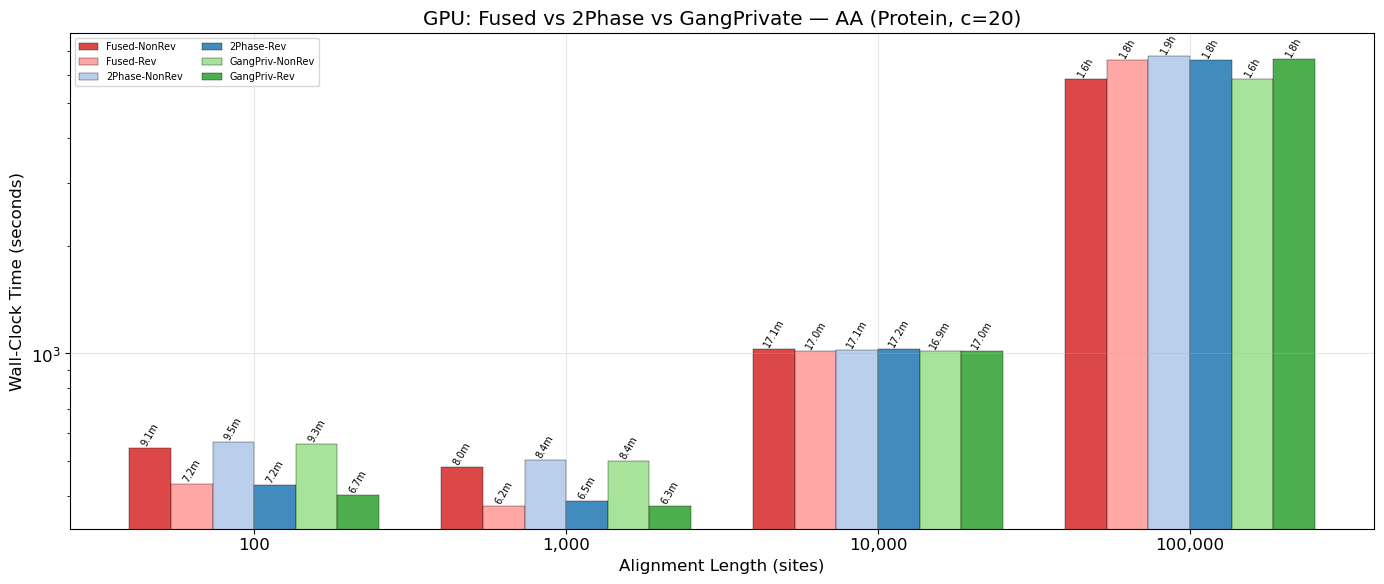

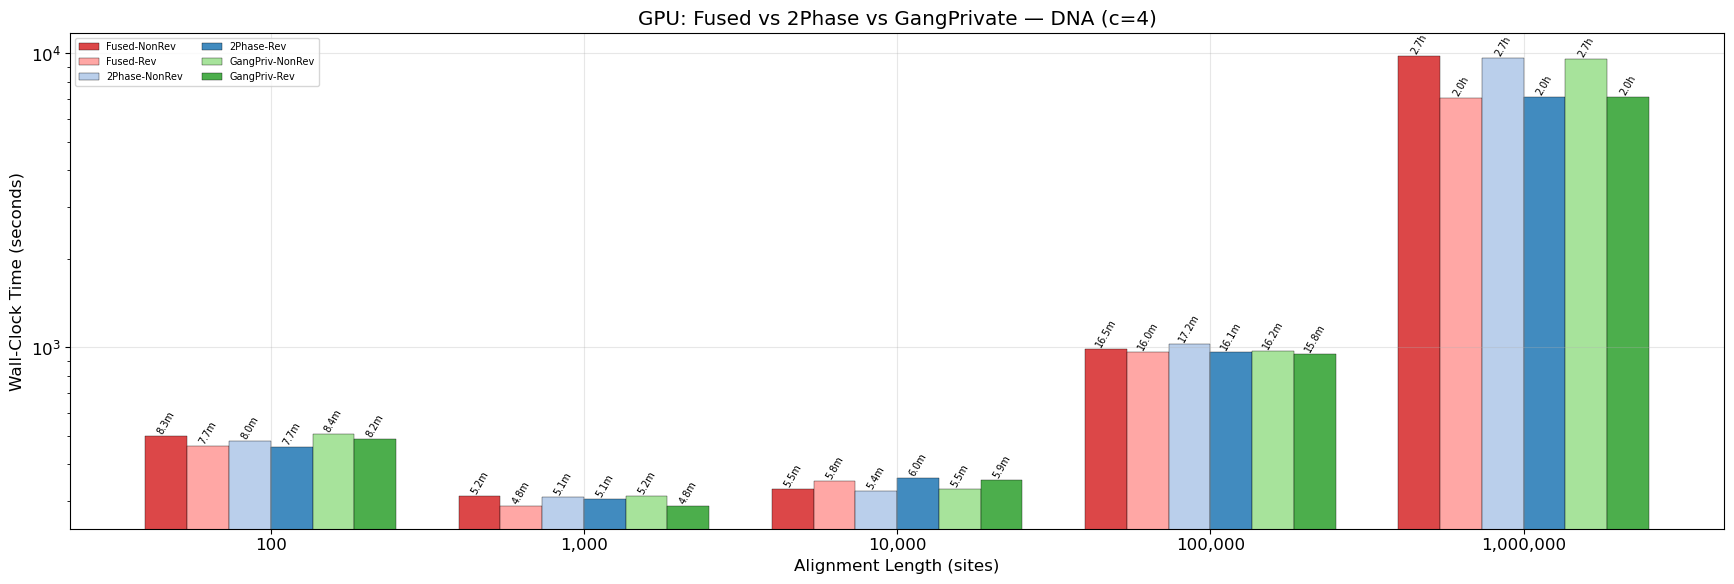

In [30]:
# Bar chart: all GPU variants for AA
kernel_order = ['Fused-NonRev', 'Fused-Rev', '2Phase-NonRev', '2Phase-Rev', 'GangPriv-NonRev', 'GangPriv-Rev']
bar_colors = {'Fused-NonRev': '#d62728', 'Fused-Rev': '#ff9896',
              '2Phase-NonRev': '#aec7e8', '2Phase-Rev': '#1f77b4',
              'GangPriv-NonRev': '#98df8a', 'GangPriv-Rev': '#2ca02c'}

for dtype, label in [('AA', 'AA (Protein, c=20)'), ('DNA', 'DNA (c=4)')]:
    sub = df_gpu_all[df_gpu_all['data_type'] == dtype]
    if len(sub) == 0: continue
    lengths = sorted(sub['length'].unique())
    kernels_present = [k for k in kernel_order if k in sub['kernel_label'].unique()]
    n_kern = len(kernels_present)
    n_len = len(lengths)

    fig, ax = plt.subplots(figsize=(3.5 * n_len, 6))
    x = np.arange(n_len)
    width = 0.8 / n_kern

    for ki, kernel in enumerate(kernels_present):
        times = []
        for length in lengths:
            row = sub[(sub['length'] == length) & (sub['kernel_label'] == kernel)]
            times.append(row['wall_time_sec'].values[0] if len(row) > 0 else 0)
        offset = (ki - n_kern/2 + 0.5) * width
        bars = ax.bar(x + offset, times, width, label=kernel,
                      color=bar_colors.get(kernel, '#999'), alpha=0.85,
                      edgecolor='black', linewidth=0.3)
        for bar, val in zip(bars, times):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        fmt_time(val), ha='center', va='bottom', fontsize=7, rotation=60)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in lengths])
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'GPU: Fused vs 2Phase vs GangPrivate — {label}')
    ax.set_yscale('log')
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_gangpriv_walltime_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 23. Gang-Private GPU Rev vs 48CPU Rev & Correctness

In [31]:
# Compare Gang-Private GPU Rev vs all baselines
summary_gp = []
for dtype, df_orig_sub in [('DNA', df_dna), ('AA', df_aa)]:
    df_gp_sub = df_gp[df_gp['data_type'] == dtype]
    for length in sorted(set(df_orig_sub['length'].unique()) | set(df_gp_sub['length'].unique())):
        row = {'Type': dtype, 'Length': f'{length:,}'}

        # Original no-tree GPU results
        for kernel, col in [('Kernel-Rev', 'Fused-Rev'), ('Kernel-NonRev', 'Fused-NR')]:
            r = df_orig_sub[(df_orig_sub['length']==length) & (df_orig_sub['backend_label']=='GPU (V100)') & (df_orig_sub['kernel_label']==kernel)]
            if len(r) > 0: row[col] = round(r['wall_time_sec'].values[0], 1)

        # Gang-Private
        for kernel, col in [('GangPriv-Rev', 'GP-Rev'), ('GangPriv-NonRev', 'GP-NR')]:
            r = df_gp_sub[(df_gp_sub['length']==length) & (df_gp_sub['kernel_label']==kernel)]
            if len(r) > 0: row[col] = round(r['wall_time_sec'].values[0], 1)

        # 48CPU Rev
        r = df_orig_sub[(df_orig_sub['length']==length) & (df_orig_sub['backend_label']=='48 CPU threads') & (df_orig_sub['kernel_label']=='Kernel-Rev')]
        if len(r) > 0: row['48CPU-Rev'] = round(r['wall_time_sec'].values[0], 1)

        # Speedups
        if 'GP-Rev' in row and 'Fused-Rev' in row:
            row['GP vs Fused'] = f"{row['Fused-Rev']/row['GP-Rev']:.2f}x"
        if 'GP-Rev' in row and 'Fused-NR' in row:
            row['GP vs FusedNR'] = f"{row['Fused-NR']/row['GP-Rev']:.2f}x"
        if 'GP-Rev' in row and '48CPU-Rev' in row:
            ratio = row['GP-Rev'] / row['48CPU-Rev']
            tag = 'GPU faster' if ratio < 1 else 'CPU faster'
            row['GP vs 48CPU'] = f"{ratio:.2f}x ({tag})"

        summary_gp.append(row)

df_sgp = pd.DataFrame(summary_gp)
key_cols = ['Type','Length','Fused-NR','Fused-Rev','GP-NR','GP-Rev','48CPU-Rev','GP vs Fused','GP vs FusedNR','GP vs 48CPU']
key_cols = [c for c in key_cols if c in df_sgp.columns]
print('=== Gang-Private GPU Rev vs All Baselines ===')
print('GP = Gang-Private shared-memory kernel (voidglob)')
display(df_sgp[key_cols])

=== Gang-Private GPU Rev vs All Baselines ===
GP = Gang-Private shared-memory kernel (voidglob)


,Type,Length,Fused-NR,Fused-Rev,GP-NR,GP-Rev,48CPU-Rev,GP vs Fused,GP vs FusedNR,GP vs 48CPU
0,DNA,100,500.8,463.5,506.4,489.4,277.3,0.95x,1.02x,1.76x (CPU faster)
1,DNA,"1,000",312.3,288.2,313.4,288.4,255.8,1.00x,1.08x,1.13x (CPU faster)
2,DNA,"10,000",330.8,350.5,330.8,354.8,295.3,0.99x,0.93x,1.20x (CPU faster)
3,DNA,"100,000",988.6,960.5,971.6,948.2,967.3,1.01x,1.04x,0.98x (GPU faster)
4,DNA,"1,000,000",9799.3,7071.2,9572.9,7109.2,16874.5,0.99x,1.38x,0.42x (GPU faster)
5,AA,100,543.2,431.9,559.2,402.5,84.9,1.07x,1.35x,4.74x (CPU faster)
6,AA,"1,000",482.7,374.9,501.6,376.0,261.2,1.00x,1.28x,1.44x (CPU faster)
7,AA,"10,000",1028.4,1017.8,1015.0,1017.2,658.1,1.00x,1.01x,1.55x (CPU faster)
8,AA,"100,000",5821.0,6608.4,5839.2,6627.8,4704.7,1.00x,0.88x,1.41x (CPU faster)


In [32]:
# Correctness: Gang-Private vs Fused lnL comparison
print('=== Log-Likelihood Correctness: Gang-Private vs Fused ===')
for dtype in ['DNA', 'AA']:
    print(f'\n--- {dtype} ---')
    df_gp_sub = df_gp[df_gp['data_type'] == dtype]
    df_orig_gpu = df[(df['data_type'] == dtype) & (df['backend_label'] == 'GPU (V100)')]
    for length in sorted(df_gp_sub['length'].unique()):
        results = {}
        for kl, tag in [('Kernel-Rev', 'Fused-Rev'), ('Kernel-NonRev', 'Fused-NR')]:
            r = df_orig_gpu[(df_orig_gpu['length']==length) & (df_orig_gpu['kernel_label']==kl)]
            if len(r) > 0 and 'log_likelihood' in r.columns:
                results[tag] = r['log_likelihood'].values[0]
        for kl, tag in [('GangPriv-Rev', 'GP-Rev'), ('GangPriv-NonRev', 'GP-NR')]:
            r = df_gp_sub[(df_gp_sub['length']==length) & (df_gp_sub['kernel_label']==kl)]
            if len(r) > 0 and 'log_likelihood' in r.columns:
                results[tag] = r['log_likelihood'].values[0]
        pairs = [('Fused-Rev', 'GP-Rev'), ('Fused-NR', 'GP-NR'), ('GP-Rev', 'GP-NR')]
        diffs = []
        for a, b in pairs:
            if a in results and b in results:
                diff = abs(results[a] - results[b])
                diffs.append(f'{a} vs {b}: {diff:.4f}')
        print(f'  len={length:>8,}: ' + ', '.join(diffs))

=== Log-Likelihood Correctness: Gang-Private vs Fused ===

--- DNA ---
  len=     100: Fused-Rev vs GP-Rev: 0.0000, Fused-NR vs GP-NR: 0.0000, GP-Rev vs GP-NR: 0.0000
  len=   1,000: Fused-Rev vs GP-Rev: 0.0000, Fused-NR vs GP-NR: 0.0000, GP-Rev vs GP-NR: 0.0001
  len=  10,000: Fused-Rev vs GP-Rev: 0.0000, Fused-NR vs GP-NR: 0.0000, GP-Rev vs GP-NR: 0.0003
  len= 100,000: Fused-Rev vs GP-Rev: 0.0000, Fused-NR vs GP-NR: 0.0000, GP-Rev vs GP-NR: 0.0105
  len=1,000,000: Fused-Rev vs GP-Rev: 0.0000, Fused-NR vs GP-NR: 0.0000, GP-Rev vs GP-NR: 0.0330

--- AA ---
  len=     100: Fused-Rev vs GP-Rev: 0.0000, Fused-NR vs GP-NR: 0.0000, GP-Rev vs GP-NR: 0.0000
  len=   1,000: Fused-Rev vs GP-Rev: 0.0000, Fused-NR vs GP-NR: 0.0000, GP-Rev vs GP-NR: 0.0000
  len=  10,000: Fused-Rev vs GP-Rev: 0.0000, Fused-NR vs GP-NR: 0.0000, GP-Rev vs GP-NR: 0.0000
  len= 100,000: Fused-Rev vs GP-Rev: 0.0000, Fused-NR vs GP-NR: 0.0000, GP-Rev vs GP-NR: 0.0000


---
# Part 6: Gang-Private v1 Results (voidglob_v1)

The v1 run has the actual gang-private code deployed to the server
(previous voidglob run was missing the code changes).

## 24. Load voidglob_v1 & Compare All GPU Variants

In [33]:
# Load voidglob_v1 results
def load_voidglobv1_results():
    records = []
    lengths = [100, 1000, 10000, 100000, 1000000]
    for data_type in ['DNA', 'AA']:
        for length in lengths:
            len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
            if not os.path.isdir(len_dir): continue
            for kernel_tag, klabel in [('rev', 'GPv1-Rev'), ('nonrev', 'GPv1-NonRev')]:
                if kernel_tag == 'rev':
                    pats = [os.path.join(len_dir, f'output_fulltest_voidglob_v1_{data_type}_*_OPENACC_*.iqtree')]
                    files = []
                    for p in pats:
                        files.extend([f for f in glob.glob(p) if 'kernelnonrev' not in os.path.basename(f)])
                else:
                    pats = [os.path.join(len_dir, f'output_fulltest_voidglob_kernelnonrev_v1_{data_type}_*_OPENACC_*.iqtree')]
                    files = []
                    for p in pats:
                        files.extend(glob.glob(p))
                if files:
                    data = parse_iqtree_file(files[0])
                    if data and 'wall_time_sec' in data:
                        data.update(length=length, kernel_label=klabel,
                                   backend_label='GPU (V100)', data_type=data_type)
                        records.append(data)
    return pd.DataFrame(records)

df_gpv1 = load_voidglobv1_results()
print(f'GPv1 records: {len(df_gpv1)}')
display(df_gpv1[['data_type','length','kernel_label','best_model','log_likelihood','wall_time_sec']].sort_values(['data_type','length','kernel_label']))

GPv1 records: 15


,data_type,length,kernel_label,best_model,log_likelihood,wall_time_sec
9,AA,100,GPv1-NonRev,LG+G4,-7.670271e+03,555.7540
8,AA,100,GPv1-Rev,LG+G4,-7.670271e+03,406.0360
11,AA,1000,GPv1-NonRev,LG+G4,-7.782396e+04,500.7690
10,AA,1000,GPv1-Rev,LG+G4,-7.782396e+04,462.2710
13,AA,10000,GPv1-NonRev,LG+G4,-8.073500e+05,1017.6000
12,AA,10000,GPv1-Rev,LG+G4,-8.073500e+05,1702.3400
14,AA,100000,GPv1-NonRev,LG+G4,-7.541977e+06,5829.3950
1,DNA,100,GPv1-NonRev,F81+F+ASC+G4,-4.894189e+03,503.4350
0,DNA,100,GPv1-Rev,F81+F+ASC+G4,-4.894189e+03,463.7750
3,DNA,1000,GPv1-NonRev,F81+F+G4,-5.618029e+04,299.3960


In [34]:
# Combined comparison: Fused vs 2Phase vs GangPriv(old) vs GPv1(actual)
df_orig_gpu2 = df[(df['backend_label'] == 'GPU (V100)')].copy()
df_orig_gpu2['kernel_label'] = df_orig_gpu2['kernel_label'].map({'Kernel-Rev': 'Fused-Rev', 'Kernel-NonRev': 'Fused-NonRev'})

df_all_gpu = pd.concat([df_orig_gpu2, df_2p, df_gp, df_gpv1], ignore_index=True)

for dtype, label in [('AA', 'Amino Acid (c=20)'), ('DNA', 'DNA (c=4)')]:
    sub = df_all_gpu[df_all_gpu['data_type'] == dtype]
    if len(sub) == 0: continue
    pivot = sub.pivot_table(index='length', columns='kernel_label', values='wall_time_sec', aggfunc='first')
    col_order = [c for c in ['Fused-NonRev','Fused-Rev','2Phase-NonRev','2Phase-Rev',
                             'GangPriv-NonRev','GangPriv-Rev','GPv1-NonRev','GPv1-Rev'] if c in pivot.columns]
    pivot = pivot[col_order]

    # Key speedup columns
    if 'GPv1-Rev' in pivot.columns and 'Fused-Rev' in pivot.columns:
        pivot['v1-Rev vs Fused-Rev'] = (pivot['Fused-Rev'] / pivot['GPv1-Rev']).round(2)
    if 'GPv1-Rev' in pivot.columns and 'Fused-NonRev' in pivot.columns:
        pivot['v1-Rev vs Fused-NR'] = (pivot['Fused-NonRev'] / pivot['GPv1-Rev']).round(2)
    if 'GPv1-NonRev' in pivot.columns and 'Fused-NonRev' in pivot.columns:
        pivot['v1-NR vs Fused-NR'] = (pivot['Fused-NonRev'] / pivot['GPv1-NonRev']).round(2)

    print(f'\n=== GPU Wall-Clock Time: {label} ===')
    print('Speedup > 1 means new kernel is faster')
    display(pivot.round(1))


=== GPU Wall-Clock Time: Amino Acid (c=20) ===
Speedup > 1 means new kernel is faster


kernel_label,Fused-NonRev,Fused-Rev,2Phase-NonRev,2Phase-Rev,GangPriv-NonRev,GangPriv-Rev,GPv1-NonRev,GPv1-Rev,v1-Rev vs Fused-Rev,v1-Rev vs Fused-NR,v1-NR vs Fused-NR
length,,,,,,,,,,,
100,543.2,431.9,567.1,430.5,559.2,402.5,555.8,406.0,1.1,1.3,1.0
1000,482.7,374.9,505.9,388.6,501.6,376.0,500.8,462.3,0.8,1.0,1.0
10000,1028.4,1017.8,1025.6,1030.4,1015.0,1017.2,1017.6,1702.3,0.6,0.6,1.0
100000,5821.0,6608.4,6768.8,6597.6,5839.2,6627.8,5829.4,NaN,NaN,NaN,1.0



=== GPU Wall-Clock Time: DNA (c=4) ===
Speedup > 1 means new kernel is faster


kernel_label,Fused-NonRev,Fused-Rev,2Phase-NonRev,2Phase-Rev,GangPriv-NonRev,GangPriv-Rev,GPv1-NonRev,GPv1-Rev,v1-Rev vs Fused-Rev,v1-Rev vs Fused-NR,v1-NR vs Fused-NR
length,,,,,,,,,,,
100,500.8,463.5,481.8,459.3,506.4,489.4,503.4,463.8,1.0,1.1,1.0
1000,312.3,288.2,308.8,305.9,313.4,288.4,299.4,301.7,1.0,1.0,1.0
10000,330.8,350.5,324.0,359.2,330.8,354.8,328.9,339.8,1.0,1.0,1.0
100000,988.6,960.5,1029.5,966.0,971.6,948.2,975.7,954.4,1.0,1.0,1.0
1000000,9799.3,7071.2,9610.8,7110.0,9572.9,7109.2,NaN,NaN,NaN,NaN,NaN


## 25. GPv1 Rev vs Baselines + Correctness

In [35]:
# GPv1 vs all baselines
summary_v1 = []
for dtype, df_orig_sub in [('DNA', df_dna), ('AA', df_aa)]:
    df_v1_sub = df_gpv1[df_gpv1['data_type'] == dtype]
    for length in sorted(set(df_orig_sub['length'].unique()) | set(df_v1_sub['length'].unique())):
        row = {'Type': dtype, 'Length': f'{length:,}'}
        for kernel, col in [('Kernel-Rev', 'Fused-Rev'), ('Kernel-NonRev', 'Fused-NR')]:
            r = df_orig_sub[(df_orig_sub['length']==length) & (df_orig_sub['backend_label']=='GPU (V100)') & (df_orig_sub['kernel_label']==kernel)]
            if len(r) > 0: row[col] = round(r['wall_time_sec'].values[0], 1)
        for kernel, col in [('GPv1-Rev', 'v1-Rev'), ('GPv1-NonRev', 'v1-NR')]:
            r = df_v1_sub[(df_v1_sub['length']==length) & (df_v1_sub['kernel_label']==kernel)]
            if len(r) > 0: row[col] = round(r['wall_time_sec'].values[0], 1)
        r = df_orig_sub[(df_orig_sub['length']==length) & (df_orig_sub['backend_label']=='48 CPU threads') & (df_orig_sub['kernel_label']=='Kernel-Rev')]
        if len(r) > 0: row['48CPU-Rev'] = round(r['wall_time_sec'].values[0], 1)
        if 'v1-Rev' in row and 'Fused-Rev' in row:
            row['v1 vs Fused'] = f"{row['Fused-Rev']/row['v1-Rev']:.2f}x"
        if 'v1-Rev' in row and 'Fused-NR' in row:
            row['v1 vs FusedNR'] = f"{row['Fused-NR']/row['v1-Rev']:.2f}x"
        if 'v1-Rev' in row and '48CPU-Rev' in row:
            ratio = row['v1-Rev'] / row['48CPU-Rev']
            tag = 'GPU faster' if ratio < 1 else 'CPU faster'
            row['v1 vs 48CPU'] = f"{ratio:.2f}x ({tag})"
        summary_v1.append(row)

df_sv1 = pd.DataFrame(summary_v1)
key_cols = ['Type','Length','Fused-NR','Fused-Rev','v1-NR','v1-Rev','48CPU-Rev','v1 vs Fused','v1 vs FusedNR','v1 vs 48CPU']
key_cols = [c for c in key_cols if c in df_sv1.columns]
print('=== Gang-Private v1 (actual code deployed) vs All Baselines ===')
display(df_sv1[key_cols])

=== Gang-Private v1 (actual code deployed) vs All Baselines ===


,Type,Length,Fused-NR,Fused-Rev,v1-NR,v1-Rev,48CPU-Rev,v1 vs Fused,v1 vs FusedNR,v1 vs 48CPU
0,DNA,100,500.8,463.5,503.4,463.8,277.3,1.00x,1.08x,1.67x (CPU faster)
1,DNA,"1,000",312.3,288.2,299.4,301.7,255.8,0.96x,1.04x,1.18x (CPU faster)
2,DNA,"10,000",330.8,350.5,328.9,339.8,295.3,1.03x,0.97x,1.15x (CPU faster)
3,DNA,"100,000",988.6,960.5,975.7,954.4,967.3,1.01x,1.04x,0.99x (GPU faster)
4,DNA,"1,000,000",9799.3,7071.2,NaN,NaN,16874.5,NaN,NaN,NaN
5,AA,100,543.2,431.9,555.8,406.0,84.9,1.06x,1.34x,4.78x (CPU faster)
6,AA,"1,000",482.7,374.9,500.8,462.3,261.2,0.81x,1.04x,1.77x (CPU faster)
7,AA,"10,000",1028.4,1017.8,1017.6,1702.3,658.1,0.60x,0.60x,2.59x (CPU faster)
8,AA,"100,000",5821.0,6608.4,5829.4,NaN,4704.7,NaN,NaN,NaN


In [36]:
# Correctness check
print('=== Log-Likelihood: GPv1 vs Fused ===')
for dtype in ['DNA', 'AA']:
    print(f'\n--- {dtype} ---')
    df_v1_sub = df_gpv1[df_gpv1['data_type'] == dtype]
    df_orig_gpu2 = df[(df['data_type'] == dtype) & (df['backend_label'] == 'GPU (V100)')]
    for length in sorted(df_v1_sub['length'].unique()):
        results = {}
        for kl, tag in [('Kernel-Rev', 'Fused-Rev'), ('Kernel-NonRev', 'Fused-NR')]:
            r = df_orig_gpu2[(df_orig_gpu2['length']==length) & (df_orig_gpu2['kernel_label']==kl)]
            if len(r) > 0: results[tag] = r['log_likelihood'].values[0]
        for kl, tag in [('GPv1-Rev', 'v1-Rev'), ('GPv1-NonRev', 'v1-NR')]:
            r = df_v1_sub[(df_v1_sub['length']==length) & (df_v1_sub['kernel_label']==kl)]
            if len(r) > 0: results[tag] = r['log_likelihood'].values[0]
        diffs = []
        for a, b in [('Fused-Rev','v1-Rev'),('Fused-NR','v1-NR'),('v1-Rev','v1-NR')]:
            if a in results and b in results:
                diffs.append(f'{a} vs {b}: {abs(results[a]-results[b]):.4f}')
        print(f'  len={length:>8,}: ' + ', '.join(diffs))

=== Log-Likelihood: GPv1 vs Fused ===

--- DNA ---
  len=     100: Fused-Rev vs v1-Rev: 0.0000, Fused-NR vs v1-NR: 0.0000, v1-Rev vs v1-NR: 0.0000
  len=   1,000: Fused-Rev vs v1-Rev: 0.0000, Fused-NR vs v1-NR: 0.0000, v1-Rev vs v1-NR: 0.0001
  len=  10,000: Fused-Rev vs v1-Rev: 0.0000, Fused-NR vs v1-NR: 0.0000, v1-Rev vs v1-NR: 0.0003
  len= 100,000: Fused-Rev vs v1-Rev: 0.0000, Fused-NR vs v1-NR: 0.0000, v1-Rev vs v1-NR: 0.0105

--- AA ---
  len=     100: Fused-Rev vs v1-Rev: 0.0000, Fused-NR vs v1-NR: 0.0000, v1-Rev vs v1-NR: 0.0000
  len=   1,000: Fused-Rev vs v1-Rev: 0.0000, Fused-NR vs v1-NR: 0.0000, v1-Rev vs v1-NR: 0.0000
  len=  10,000: Fused-Rev vs v1-Rev: 0.0000, Fused-NR vs v1-NR: 0.0000, v1-Rev vs v1-NR: 0.0000
  len= 100,000: Fused-NR vs v1-NR: 0.0000


## 26. Bar Chart: All GPU Variants Including GPv1

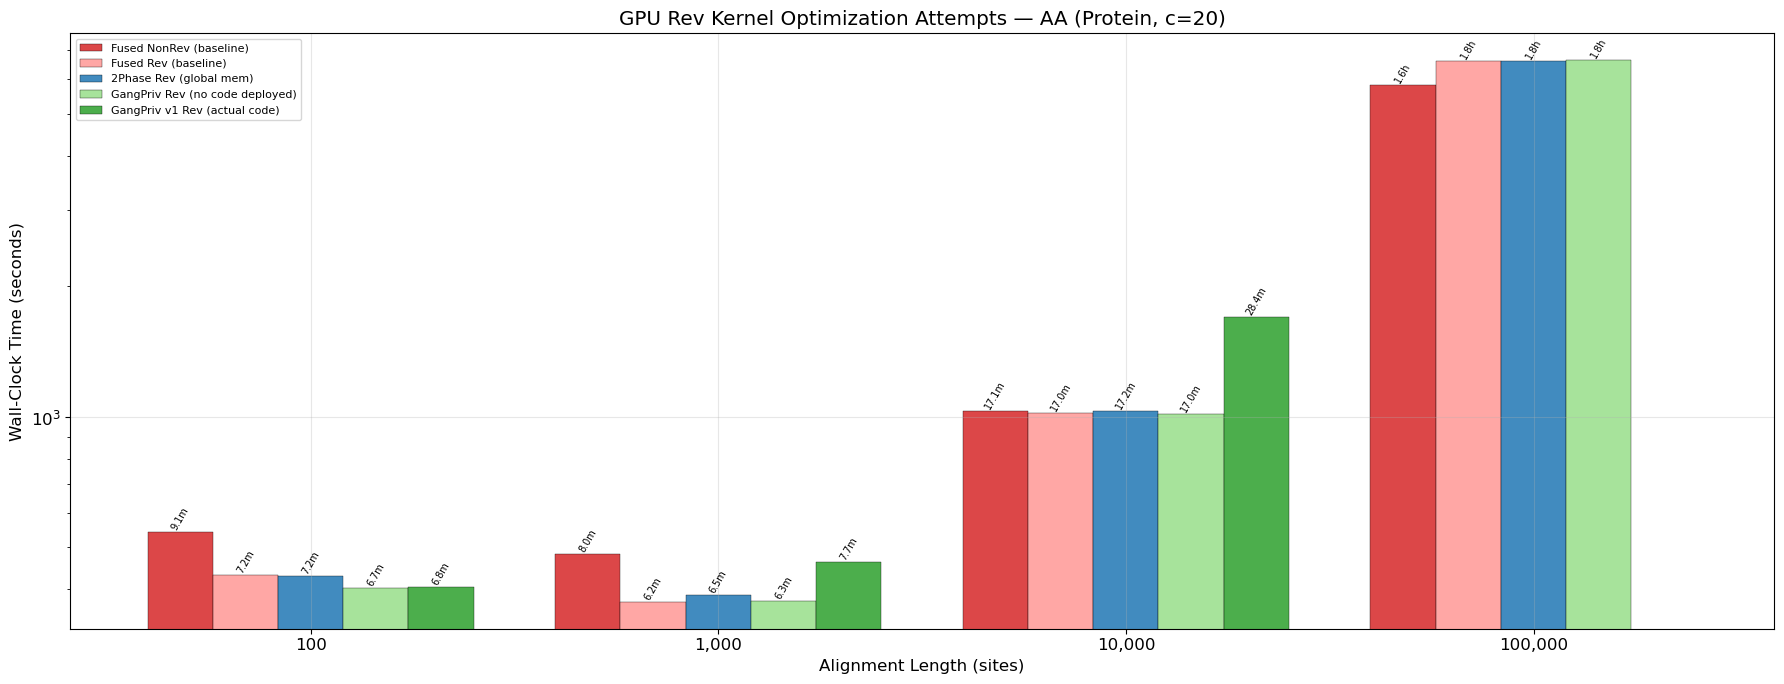

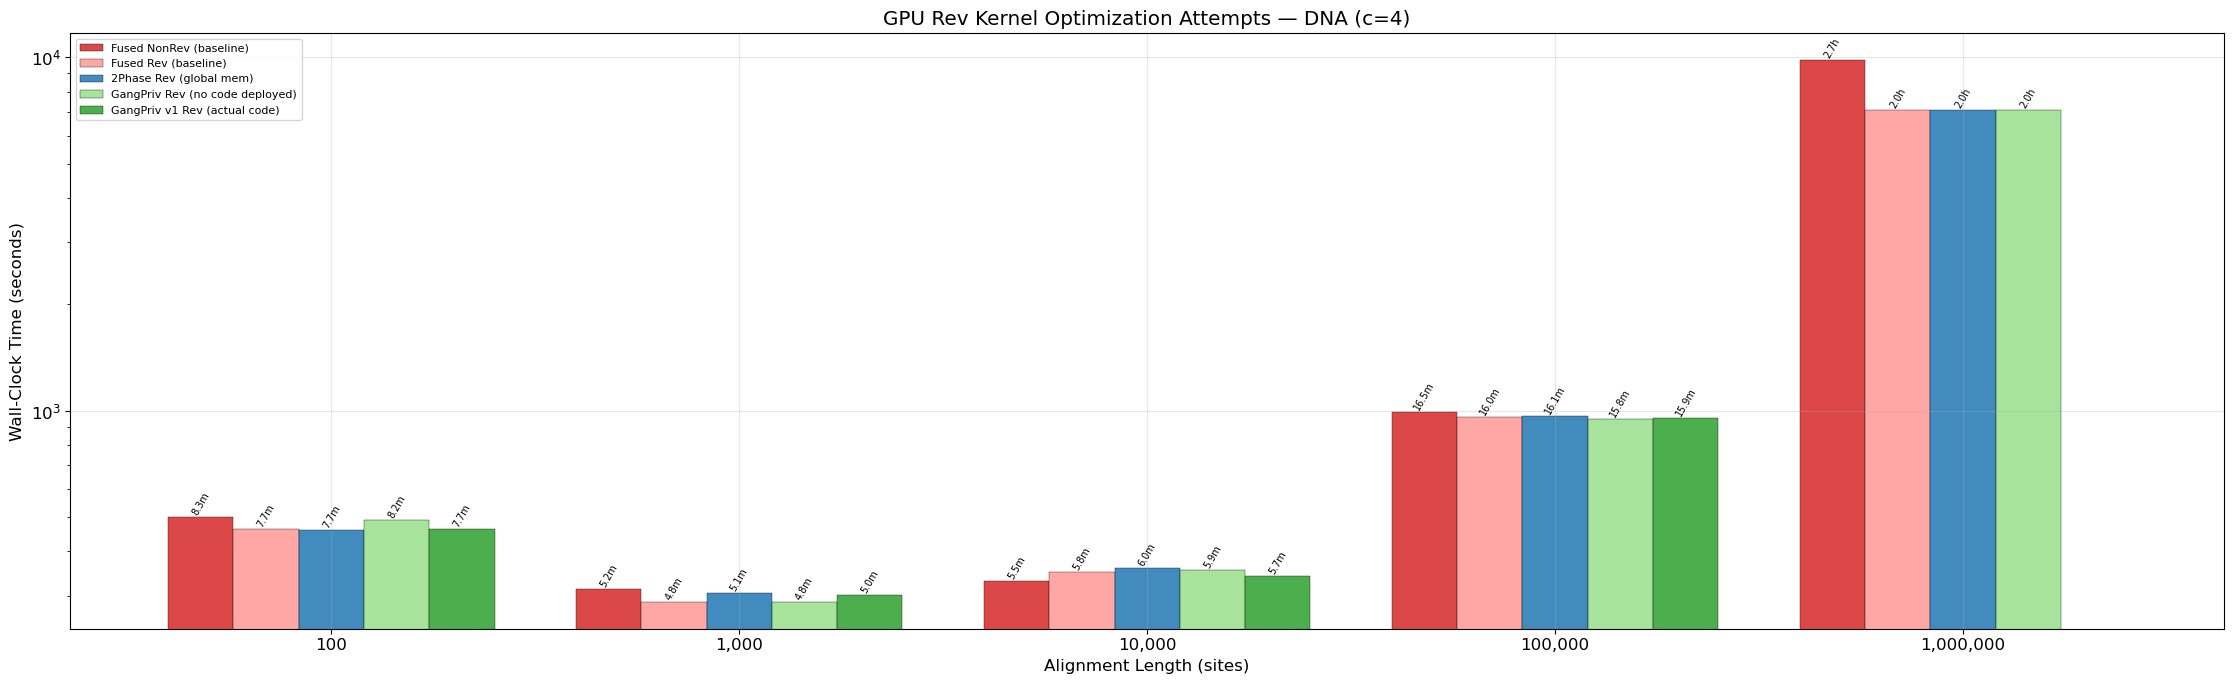

In [37]:
# Bar chart: ALL GPU variants including GPv1 — with Fused baselines
kernel_order_all = ['Fused-NonRev', 'Fused-Rev', '2Phase-Rev', 'GangPriv-Rev', 'GPv1-Rev']
bar_colors_all = {'Fused-NonRev': '#d62728', 'Fused-Rev': '#ff9896',
                  '2Phase-Rev': '#1f77b4',
                  'GangPriv-Rev': '#98df8a', 'GPv1-Rev': '#2ca02c'}
bar_labels = {'Fused-NonRev': 'Fused NonRev (baseline)', 'Fused-Rev': 'Fused Rev (baseline)',
              '2Phase-Rev': '2Phase Rev (global mem)',
              'GangPriv-Rev': 'GangPriv Rev (no code deployed)',
              'GPv1-Rev': 'GangPriv v1 Rev (actual code)'}

# Rebuild df_orig_gpu2 fresh
df_orig_gpu_fresh = df[(df['backend_label'] == 'GPU (V100)')].copy()
df_orig_gpu_fresh['kernel_label'] = df_orig_gpu_fresh['kernel_label'].map({'Kernel-Rev': 'Fused-Rev', 'Kernel-NonRev': 'Fused-NonRev'})
df_all_gpu_final = pd.concat([df_orig_gpu_fresh, df_2p, df_gp, df_gpv1], ignore_index=True)

for dtype, label in [('AA', 'AA (Protein, c=20)'), ('DNA', 'DNA (c=4)')]:
    sub = df_all_gpu_final[df_all_gpu_final['data_type'] == dtype]
    if len(sub) == 0: continue
    lengths = sorted(sub['length'].unique())
    kernels_present = [k for k in kernel_order_all if k in sub['kernel_label'].unique()]
    n_kern = len(kernels_present)
    n_len = len(lengths)

    fig, ax = plt.subplots(figsize=(4.5 * n_len, 7))
    x = np.arange(n_len)
    width = 0.8 / n_kern

    for ki, kernel in enumerate(kernels_present):
        times = []
        for length in lengths:
            row = sub[(sub['length'] == length) & (sub['kernel_label'] == kernel)]
            times.append(row['wall_time_sec'].values[0] if len(row) > 0 else 0)
        offset = (ki - n_kern/2 + 0.5) * width
        lbl = bar_labels.get(kernel, kernel)
        bars = ax.bar(x + offset, times, width, label=lbl,
                      color=bar_colors_all.get(kernel, '#999'), alpha=0.85,
                      edgecolor='black', linewidth=0.3)
        for bar, val in zip(bars, times):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        fmt_time(val), ha='center', va='bottom', fontsize=7, rotation=60)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in lengths])
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'GPU Rev Kernel Optimization Attempts — {label}')
    ax.set_yscale('log')
    ax.legend(fontsize=8, loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_all_gpu_variants.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 7: Two-Phase v1 Results (2phase_v1) — ACTUAL CODE DEPLOYED

Previous 2phase results ran without the code changes on the server.
This is the real Two-Phase test with code properly deployed.

## 27. Load 2phase_v1 & Compare

In [38]:
# Load 2phase_v1 results
def load_2phasev1_results():
    records = []
    lengths = [100, 1000, 10000, 100000, 1000000]
    for data_type in ['DNA', 'AA']:
        for length in lengths:
            len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
            if not os.path.isdir(len_dir): continue
            for kernel_tag, klabel in [('rev', '2Pv1-Rev'), ('nonrev', '2Pv1-NonRev')]:
                if kernel_tag == 'rev':
                    files = [f for f in glob.glob(os.path.join(len_dir, '*2phase*v1*.iqtree'))
                             if 'kernelnonrev' not in os.path.basename(f)]
                else:
                    files = [f for f in glob.glob(os.path.join(len_dir, '*2phase*kernelnonrev*v1*.iqtree'))]
                if files:
                    data = parse_iqtree_file(files[0])
                    if data and 'wall_time_sec' in data:
                        data.update(length=length, kernel_label=klabel,
                                   backend_label='GPU (V100)', data_type=data_type)
                        records.append(data)
    return pd.DataFrame(records)

df_2pv1 = load_2phasev1_results()
print(f'2Phase-v1 records: {len(df_2pv1)}')
display(df_2pv1[['data_type','length','kernel_label','best_model','log_likelihood','wall_time_sec']].sort_values(['data_type','length','kernel_label']))

2Phase-v1 records: 17


,data_type,length,kernel_label,best_model,log_likelihood,wall_time_sec
10,AA,100,2Pv1-NonRev,LG+G4,-7.670271e+03,546.0770
9,AA,100,2Pv1-Rev,LG+G4,-7.670271e+03,447.5260
12,AA,1000,2Pv1-NonRev,LG+G4,-7.782396e+04,525.4650
11,AA,1000,2Pv1-Rev,LG+G4,-7.782396e+04,371.7560
14,AA,10000,2Pv1-NonRev,LG+G4,-8.073500e+05,1055.5300
13,AA,10000,2Pv1-Rev,LG+G4,-8.073500e+05,720.8750
16,AA,100000,2Pv1-NonRev,LG+G4,-7.541977e+06,5865.5860
15,AA,100000,2Pv1-Rev,LG+G4,-7.541977e+06,3951.6170
1,DNA,100,2Pv1-NonRev,F81+F+ASC+G4,-4.894189e+03,486.8150
0,DNA,100,2Pv1-Rev,F81+F+ASC+G4,-4.894189e+03,497.0890


In [39]:
# Full comparison table: Fused vs 2Phase(no code) vs 2Phasev1(actual) vs GangPrivv1
df_orig_gpu_f = df[(df['backend_label'] == 'GPU (V100)')].copy()
df_orig_gpu_f['kernel_label'] = df_orig_gpu_f['kernel_label'].map({'Kernel-Rev': 'Fused-Rev', 'Kernel-NonRev': 'Fused-NonRev'})

df_all_final = pd.concat([df_orig_gpu_f, df_2pv1, df_gpv1], ignore_index=True)

for dtype, label in [('AA', 'Amino Acid (c=20)'), ('DNA', 'DNA (c=4)')]:
    sub = df_all_final[df_all_final['data_type'] == dtype]
    if len(sub) == 0: continue
    pivot = sub.pivot_table(index='length', columns='kernel_label', values='wall_time_sec', aggfunc='first')
    col_order = [c for c in ['Fused-NonRev','Fused-Rev','2Pv1-NonRev','2Pv1-Rev','GPv1-NonRev','GPv1-Rev'] if c in pivot.columns]
    pivot = pivot[col_order]

    if '2Pv1-Rev' in pivot.columns and 'Fused-Rev' in pivot.columns:
        pivot['2Pv1 vs Fused-Rev'] = (pivot['Fused-Rev'] / pivot['2Pv1-Rev']).round(2)
    if '2Pv1-Rev' in pivot.columns and 'Fused-NonRev' in pivot.columns:
        pivot['2Pv1 vs Fused-NR'] = (pivot['Fused-NonRev'] / pivot['2Pv1-Rev']).round(2)

    print(f'\n=== GPU Wall-Clock Time: {label} ===')
    print('Speedup > 1 means new kernel is faster')
    display(pivot.round(1))


=== GPU Wall-Clock Time: Amino Acid (c=20) ===
Speedup > 1 means new kernel is faster


kernel_label,Fused-NonRev,Fused-Rev,2Pv1-NonRev,2Pv1-Rev,GPv1-NonRev,GPv1-Rev,2Pv1 vs Fused-Rev,2Pv1 vs Fused-NR
length,,,,,,,,
100,543.2,431.9,546.1,447.5,555.8,406.0,1.0,1.2
1000,482.7,374.9,525.5,371.8,500.8,462.3,1.0,1.3
10000,1028.4,1017.8,1055.5,720.9,1017.6,1702.3,1.4,1.4
100000,5821.0,6608.4,5865.6,3951.6,5829.4,NaN,1.7,1.5



=== GPU Wall-Clock Time: DNA (c=4) ===
Speedup > 1 means new kernel is faster


kernel_label,Fused-NonRev,Fused-Rev,2Pv1-NonRev,2Pv1-Rev,GPv1-NonRev,GPv1-Rev,2Pv1 vs Fused-Rev,2Pv1 vs Fused-NR
length,,,,,,,,
100,500.8,463.5,486.8,497.1,503.4,463.8,0.9,1.0
1000,312.3,288.2,316.5,325.0,299.4,301.7,0.9,1.0
10000,330.8,350.5,337.9,394.2,328.9,339.8,0.9,0.8
100000,988.6,960.5,985.0,1010.7,975.7,954.4,1.0,1.0
1000000,9799.3,7071.2,NaN,6978.0,NaN,NaN,1.0,1.4


## 28. 2Phase-v1 vs All Baselines + Correctness

In [40]:
# 2Pv1 vs all baselines
summary_2pv1 = []
for dtype, df_orig_sub in [('DNA', df_dna), ('AA', df_aa)]:
    df_v1_sub = df_2pv1[df_2pv1['data_type'] == dtype]
    for length in sorted(set(df_orig_sub['length'].unique()) | set(df_v1_sub['length'].unique())):
        row = {'Type': dtype, 'Length': f'{length:,}'}
        for kernel, col in [('Kernel-Rev', 'Fused-Rev'), ('Kernel-NonRev', 'Fused-NR')]:
            r = df_orig_sub[(df_orig_sub['length']==length) & (df_orig_sub['backend_label']=='GPU (V100)') & (df_orig_sub['kernel_label']==kernel)]
            if len(r) > 0: row[col] = round(r['wall_time_sec'].values[0], 1)
        for kernel, col in [('2Pv1-Rev', '2Pv1-Rev'), ('2Pv1-NonRev', '2Pv1-NR')]:
            r = df_v1_sub[(df_v1_sub['length']==length) & (df_v1_sub['kernel_label']==kernel)]
            if len(r) > 0: row[col] = round(r['wall_time_sec'].values[0], 1)
        r = df_orig_sub[(df_orig_sub['length']==length) & (df_orig_sub['backend_label']=='48 CPU threads') & (df_orig_sub['kernel_label']=='Kernel-Rev')]
        if len(r) > 0: row['48CPU-Rev'] = round(r['wall_time_sec'].values[0], 1)
        if '2Pv1-Rev' in row and 'Fused-Rev' in row:
            row['2Pv1 vs Fused'] = f"{row['Fused-Rev']/row['2Pv1-Rev']:.2f}x"
        if '2Pv1-Rev' in row and 'Fused-NR' in row:
            row['2Pv1 vs FusedNR'] = f"{row['Fused-NR']/row['2Pv1-Rev']:.2f}x"
        if '2Pv1-Rev' in row and '48CPU-Rev' in row:
            ratio = row['2Pv1-Rev'] / row['48CPU-Rev']
            tag = 'GPU faster' if ratio < 1 else 'CPU faster'
            row['2Pv1 vs 48CPU'] = f"{ratio:.2f}x ({tag})"
        summary_2pv1.append(row)

df_s2pv1 = pd.DataFrame(summary_2pv1)
key_cols = ['Type','Length','Fused-NR','Fused-Rev','2Pv1-NR','2Pv1-Rev','48CPU-Rev','2Pv1 vs Fused','2Pv1 vs FusedNR','2Pv1 vs 48CPU']
key_cols = [c for c in key_cols if c in df_s2pv1.columns]
print('=== Two-Phase v1 (actual code deployed) vs All Baselines ===')
display(df_s2pv1[key_cols])

=== Two-Phase v1 (actual code deployed) vs All Baselines ===


,Type,Length,Fused-NR,Fused-Rev,2Pv1-NR,2Pv1-Rev,48CPU-Rev,2Pv1 vs Fused,2Pv1 vs FusedNR,2Pv1 vs 48CPU
0,DNA,100,500.8,463.5,486.8,497.1,277.3,0.93x,1.01x,1.79x (CPU faster)
1,DNA,"1,000",312.3,288.2,316.5,325.0,255.8,0.89x,0.96x,1.27x (CPU faster)
2,DNA,"10,000",330.8,350.5,337.9,394.2,295.3,0.89x,0.84x,1.33x (CPU faster)
3,DNA,"100,000",988.6,960.5,985.0,1010.7,967.3,0.95x,0.98x,1.04x (CPU faster)
4,DNA,"1,000,000",9799.3,7071.2,NaN,6978.0,16874.5,1.01x,1.40x,0.41x (GPU faster)
5,AA,100,543.2,431.9,546.1,447.5,84.9,0.97x,1.21x,5.27x (CPU faster)
6,AA,"1,000",482.7,374.9,525.5,371.8,261.2,1.01x,1.30x,1.42x (CPU faster)
7,AA,"10,000",1028.4,1017.8,1055.5,720.9,658.1,1.41x,1.43x,1.10x (CPU faster)
8,AA,"100,000",5821.0,6608.4,5865.6,3951.6,4704.7,1.67x,1.47x,0.84x (GPU faster)


In [41]:
# Correctness
print('=== Log-Likelihood: 2Phase-v1 vs Fused ===')
for dtype in ['DNA', 'AA']:
    print(f'\n--- {dtype} ---')
    df_v1_sub = df_2pv1[df_2pv1['data_type'] == dtype]
    df_orig_gpu_c = df[(df['data_type'] == dtype) & (df['backend_label'] == 'GPU (V100)')]
    for length in sorted(df_v1_sub['length'].unique()):
        results = {}
        for kl, tag in [('Kernel-Rev', 'Fused-Rev'), ('Kernel-NonRev', 'Fused-NR')]:
            r = df_orig_gpu_c[(df_orig_gpu_c['length']==length) & (df_orig_gpu_c['kernel_label']==kl)]
            if len(r) > 0: results[tag] = r['log_likelihood'].values[0]
        for kl, tag in [('2Pv1-Rev', '2Pv1-Rev'), ('2Pv1-NonRev', '2Pv1-NR')]:
            r = df_v1_sub[(df_v1_sub['length']==length) & (df_v1_sub['kernel_label']==kl)]
            if len(r) > 0: results[tag] = r['log_likelihood'].values[0]
        diffs = []
        for a, b in [('Fused-Rev','2Pv1-Rev'),('Fused-NR','2Pv1-NR'),('2Pv1-Rev','2Pv1-NR')]:
            if a in results and b in results:
                diffs.append(f'{a} vs {b}: {abs(results[a]-results[b]):.4f}')
        print(f'  len={length:>8,}: ' + ', '.join(diffs))

=== Log-Likelihood: 2Phase-v1 vs Fused ===

--- DNA ---
  len=     100: Fused-Rev vs 2Pv1-Rev: 0.0000, Fused-NR vs 2Pv1-NR: 0.0000, 2Pv1-Rev vs 2Pv1-NR: 0.0000
  len=   1,000: Fused-Rev vs 2Pv1-Rev: 0.0000, Fused-NR vs 2Pv1-NR: 0.0000, 2Pv1-Rev vs 2Pv1-NR: 0.0001
  len=  10,000: Fused-Rev vs 2Pv1-Rev: 0.0000, Fused-NR vs 2Pv1-NR: 0.0000, 2Pv1-Rev vs 2Pv1-NR: 0.0003
  len= 100,000: Fused-Rev vs 2Pv1-Rev: 0.0000, Fused-NR vs 2Pv1-NR: 0.0000, 2Pv1-Rev vs 2Pv1-NR: 0.0105
  len=1,000,000: Fused-Rev vs 2Pv1-Rev: 0.0000

--- AA ---
  len=     100: Fused-Rev vs 2Pv1-Rev: 0.0000, Fused-NR vs 2Pv1-NR: 0.0000, 2Pv1-Rev vs 2Pv1-NR: 0.0000
  len=   1,000: Fused-Rev vs 2Pv1-Rev: 0.0000, Fused-NR vs 2Pv1-NR: 0.0000, 2Pv1-Rev vs 2Pv1-NR: 0.0000
  len=  10,000: Fused-Rev vs 2Pv1-Rev: 0.0000, Fused-NR vs 2Pv1-NR: 0.0000, 2Pv1-Rev vs 2Pv1-NR: 0.0000
  len= 100,000: Fused-Rev vs 2Pv1-Rev: 0.0000, Fused-NR vs 2Pv1-NR: 0.0000, 2Pv1-Rev vs 2Pv1-NR: 0.0000


## 29. Final Bar Chart: All Experiments

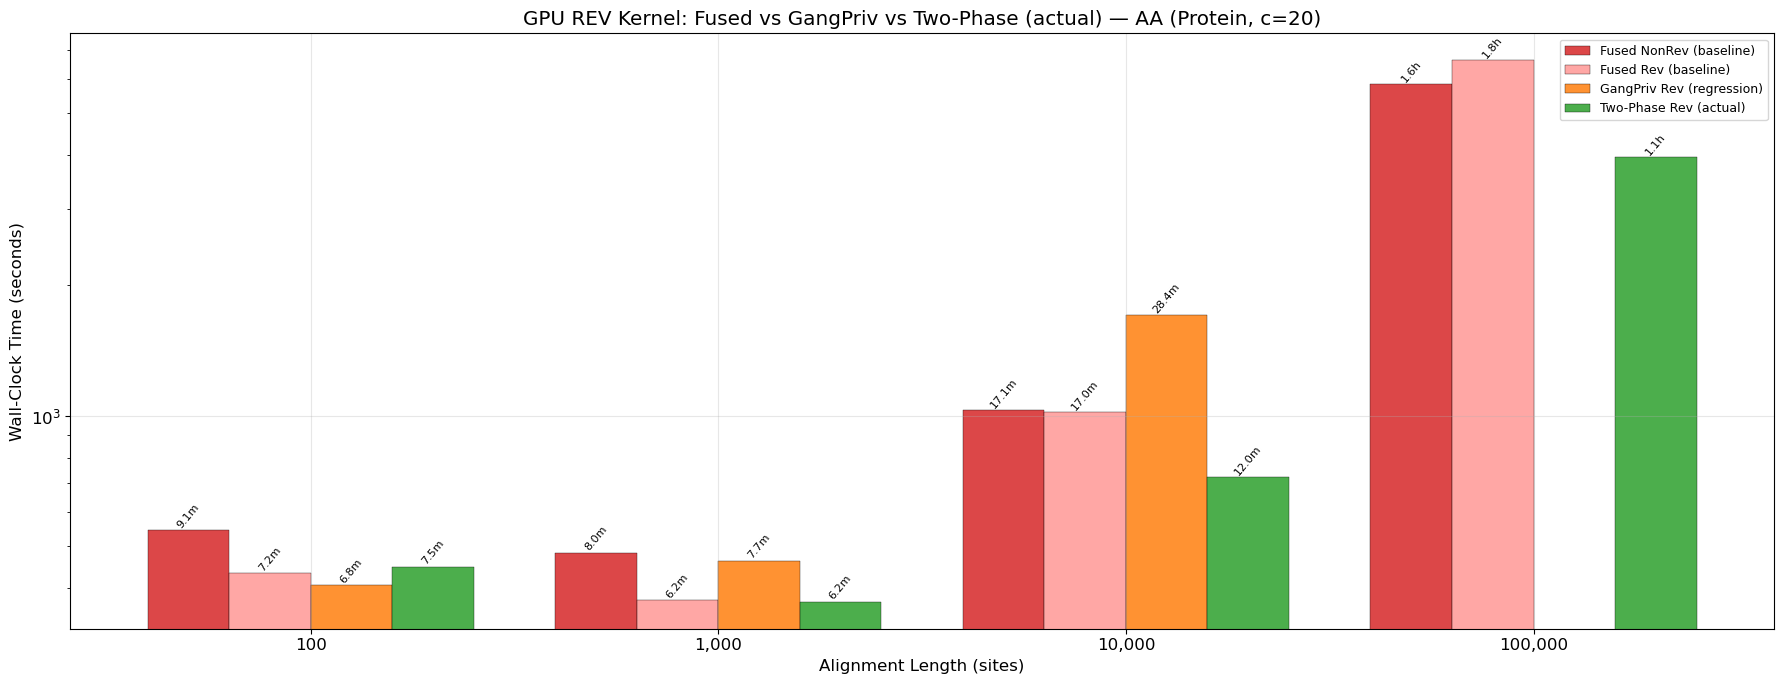

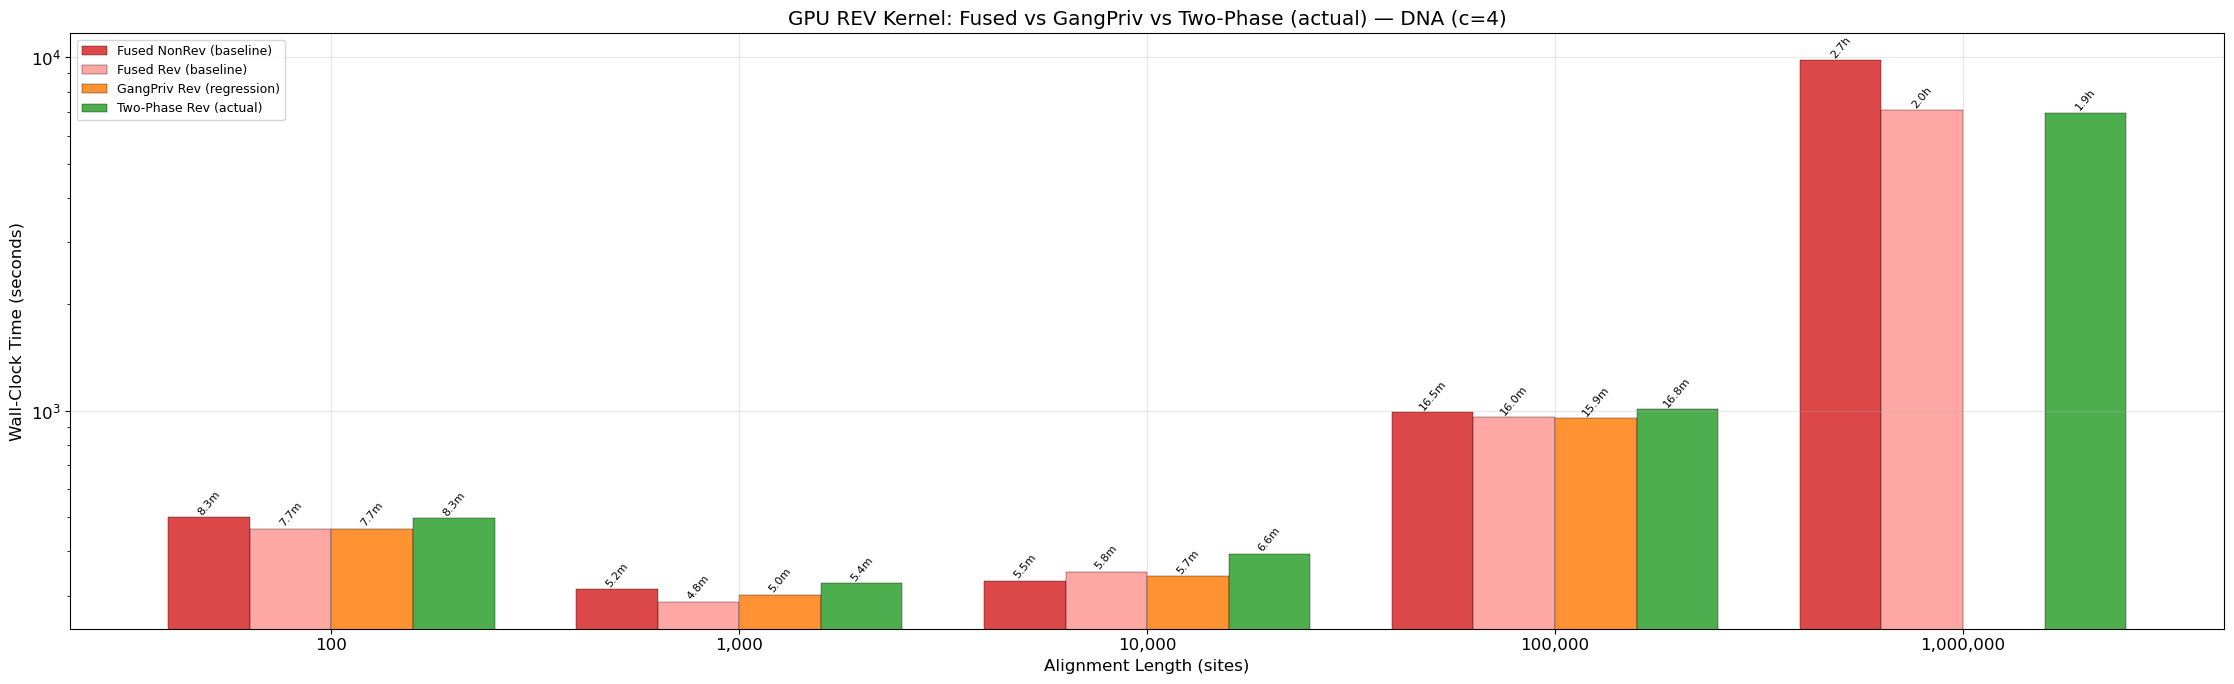

In [42]:
# Final bar chart: Fused baseline + all actual experiments (GPv1 + 2Pv1)
kernel_order_final = ['Fused-NonRev', 'Fused-Rev', 'GPv1-Rev', '2Pv1-Rev']
bar_colors_final = {'Fused-NonRev': '#d62728', 'Fused-Rev': '#ff9896',
                    'GPv1-Rev': '#ff7f0e', '2Pv1-Rev': '#2ca02c'}
bar_labels_final = {'Fused-NonRev': 'Fused NonRev (baseline)',
                    'Fused-Rev': 'Fused Rev (baseline)',
                    'GPv1-Rev': 'GangPriv Rev (regression)',
                    '2Pv1-Rev': 'Two-Phase Rev (actual)'}

df_final = pd.concat([df_orig_gpu_f, df_gpv1, df_2pv1], ignore_index=True)

for dtype, label in [('AA', 'AA (Protein, c=20)'), ('DNA', 'DNA (c=4)')]:
    sub = df_final[df_final['data_type'] == dtype]
    if len(sub) == 0: continue
    lengths = sorted(sub['length'].unique())
    kernels_present = [k for k in kernel_order_final if k in sub['kernel_label'].unique()]
    n_kern = len(kernels_present)
    n_len = len(lengths)

    fig, ax = plt.subplots(figsize=(4.5 * n_len, 7))
    x = np.arange(n_len)
    width = 0.8 / n_kern

    for ki, kernel in enumerate(kernels_present):
        times = []
        for length in lengths:
            row = sub[(sub['length'] == length) & (sub['kernel_label'] == kernel)]
            times.append(row['wall_time_sec'].values[0] if len(row) > 0 else 0)
        offset = (ki - n_kern/2 + 0.5) * width
        lbl = bar_labels_final.get(kernel, kernel)
        bars = ax.bar(x + offset, times, width, label=lbl,
                      color=bar_colors_final.get(kernel, '#999'), alpha=0.85,
                      edgecolor='black', linewidth=0.3)
        for bar, val in zip(bars, times):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        fmt_time(val), ha='center', va='bottom', fontsize=8, rotation=50)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in lengths])
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'GPU REV Kernel: Fused vs GangPriv vs Two-Phase (actual) — {label}')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_final_gpu_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 30. CPU vs GPU vs Two-Phase: Full Comparison

In [43]:
# Build full dataset: all CPU backends + GPU fused + GPU 2Phase-v1
all_rows = []

# Original no-tree data (all backends, both kernels)
for _, row in df.iterrows():
    bl = row['backend_label']
    kl = row['kernel_label']
    short_b = bl.replace(' CPU threads', 'CPU').replace(' CPU thread', 'CPU').replace('GPU (V100)', 'GPU')
    short_k = kl.replace('Kernel-', '')
    all_rows.append({
        'data_type': row['data_type'], 'length': row['length'],
        'config': f'{short_b} {short_k}',
        'wall_time_sec': row['wall_time_sec'],
        'group': 'CPU' if 'CPU' in bl else 'GPU-Fused'
    })

# 2Phase v1
for _, row in df_2pv1.iterrows():
    short_k = row['kernel_label'].replace('2Pv1-', '')
    all_rows.append({
        'data_type': row['data_type'], 'length': row['length'],
        'config': f'GPU 2Phase-{short_k}',
        'wall_time_sec': row['wall_time_sec'],
        'group': 'GPU-2Phase'
    })

df_full = pd.DataFrame(all_rows)

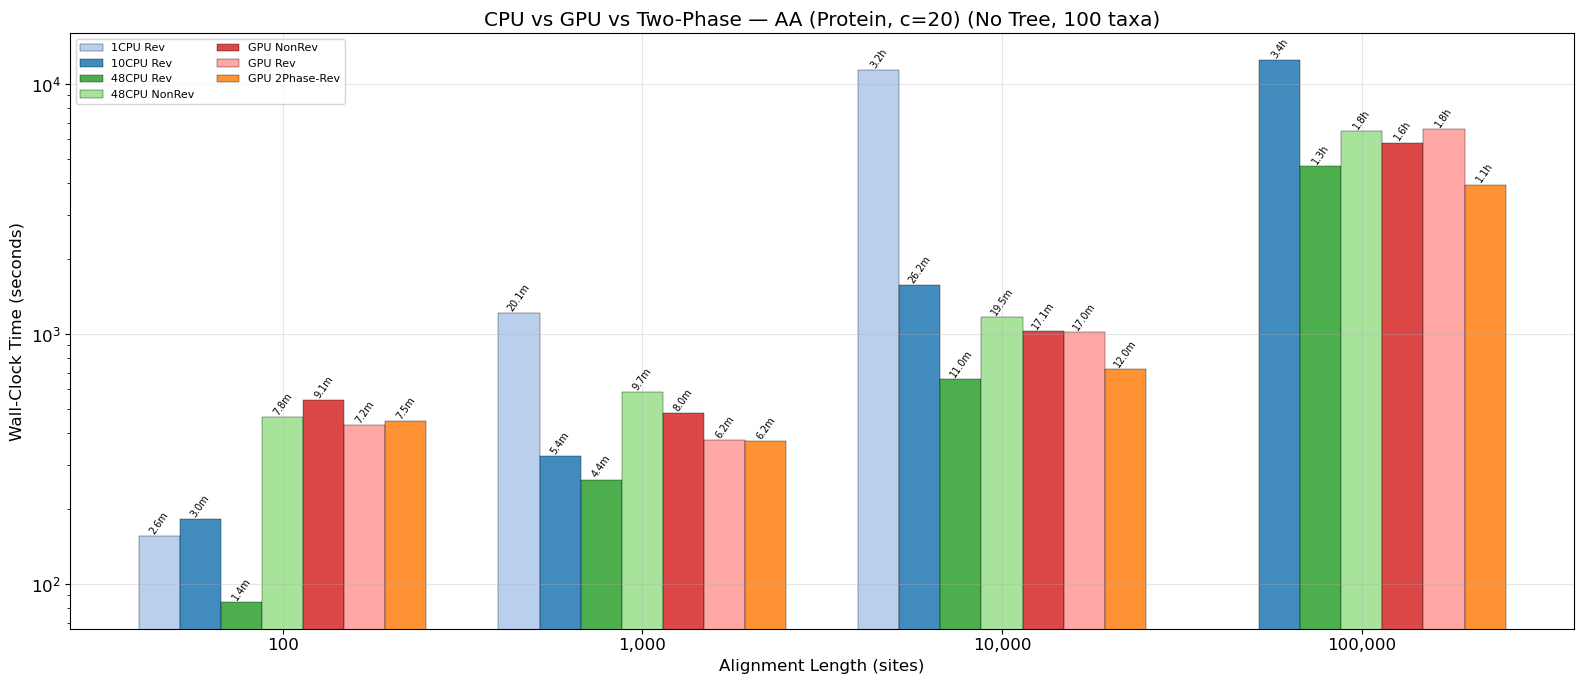

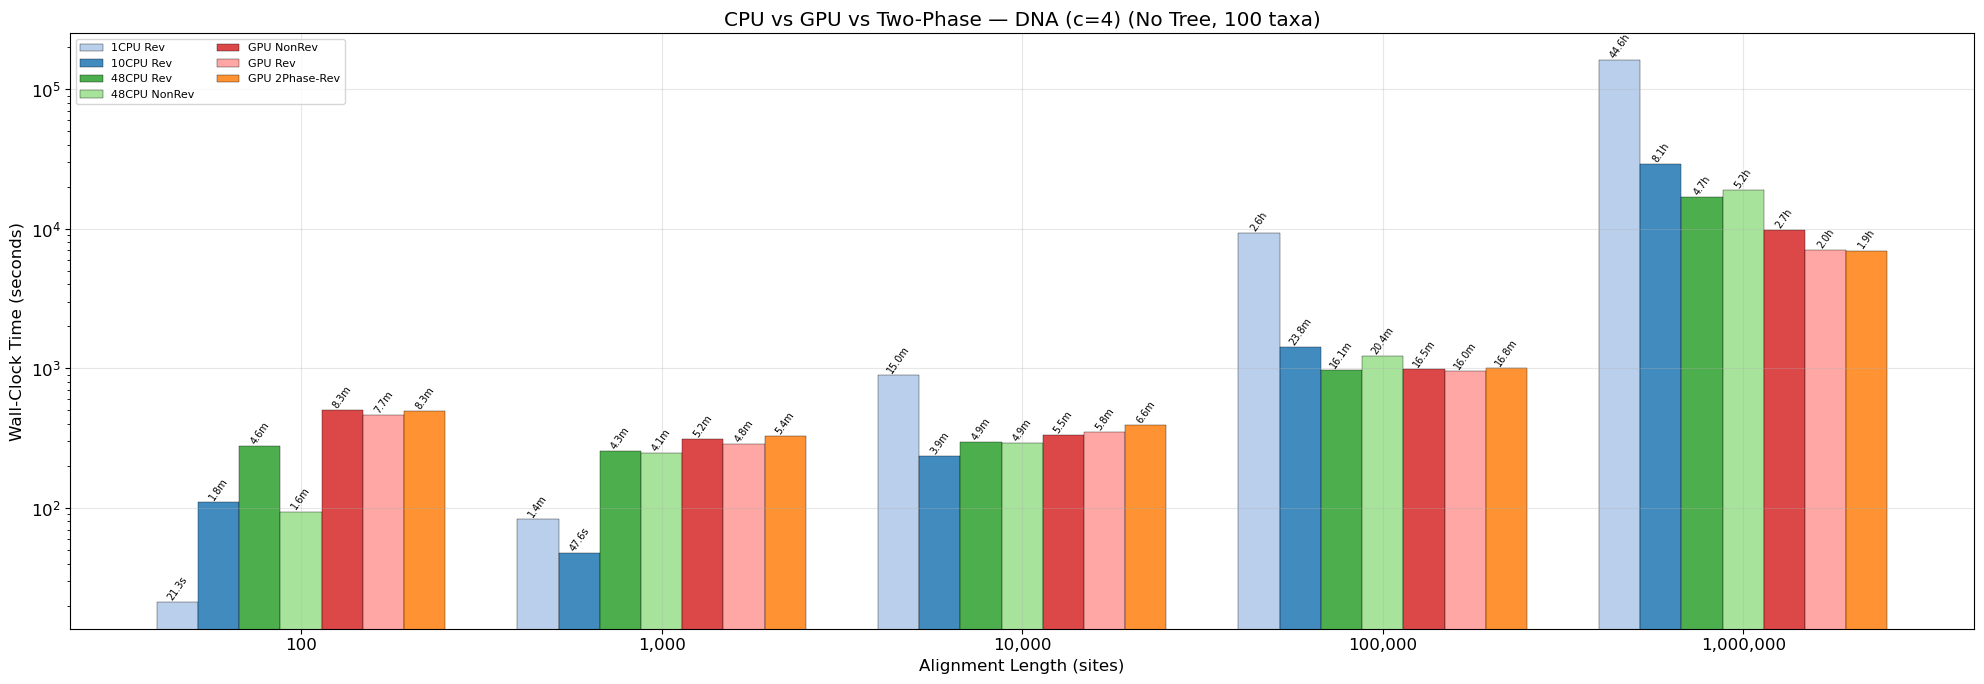

In [44]:
# Bar chart: key configs side by side per alignment length
key_configs = ['1CPU Rev', '10CPU Rev', '48CPU Rev', '48CPU NonRev', 'GPU NonRev', 'GPU Rev', 'GPU 2Phase-Rev']
config_colors = {
    '1CPU Rev': '#aec7e8', '10CPU Rev': '#1f77b4', 
    '48CPU Rev': '#2ca02c', '48CPU NonRev': '#98df8a',
    'GPU NonRev': '#d62728', 'GPU Rev': '#ff9896',
    'GPU 2Phase-Rev': '#ff7f0e'
}

for dtype, label in [('AA', 'AA (Protein, c=20)'), ('DNA', 'DNA (c=4)')]:
    sub = df_full[df_full['data_type'] == dtype]
    lengths = sorted(sub['length'].unique())
    configs_present = [c for c in key_configs if c in sub['config'].unique()]
    n_cfg = len(configs_present)
    n_len = len(lengths)

    fig, ax = plt.subplots(figsize=(4 * n_len, 7))
    x = np.arange(n_len)
    width = 0.8 / n_cfg

    for ci, cfg in enumerate(configs_present):
        times = []
        for length in lengths:
            row = sub[(sub['length'] == length) & (sub['config'] == cfg)]
            times.append(row['wall_time_sec'].values[0] if len(row) > 0 else 0)
        offset = (ci - n_cfg/2 + 0.5) * width
        bars = ax.bar(x + offset, times, width, label=cfg,
                      color=config_colors.get(cfg, '#999'), alpha=0.85,
                      edgecolor='black', linewidth=0.3)
        for bar, val in zip(bars, times):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        fmt_time(val), ha='center', va='bottom', fontsize=7, rotation=55)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in lengths])
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'CPU vs GPU vs Two-Phase — {label} (No Tree, 100 taxa)')
    ax.set_yscale('log')
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_cpu_vs_gpu_2phase.png'), dpi=150, bbox_inches='tight')
    plt.show()

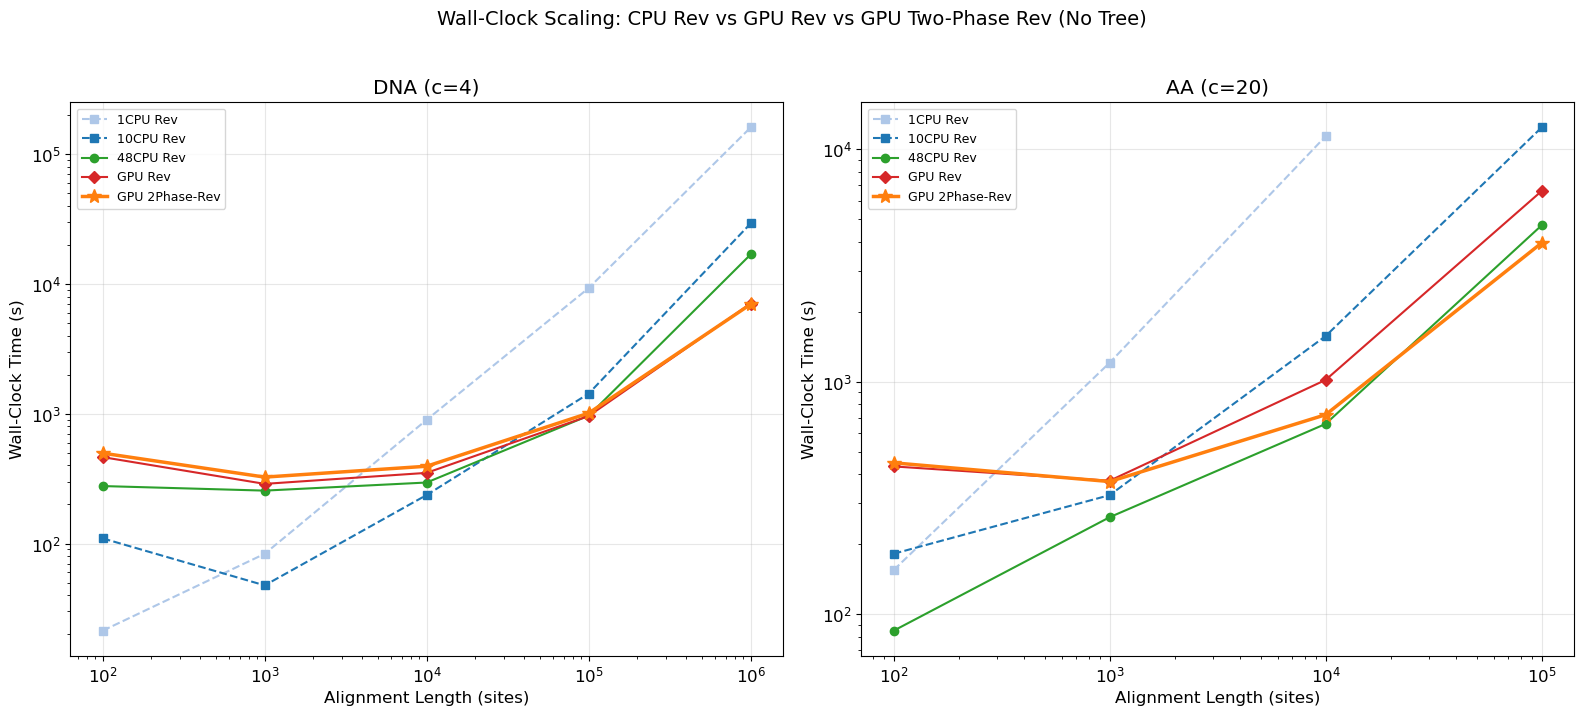

In [45]:
# Line plot: wall-clock scaling by alignment length, all backends
line_configs = ['1CPU Rev', '10CPU Rev', '48CPU Rev', 'GPU Rev', 'GPU 2Phase-Rev']
line_styles = {
    '1CPU Rev': ('--', 's', '#aec7e8'),
    '10CPU Rev': ('--', 's', '#1f77b4'),
    '48CPU Rev': ('-', 'o', '#2ca02c'),
    'GPU Rev': ('-', 'D', '#d62728'),
    'GPU 2Phase-Rev': ('-', '*', '#ff7f0e'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, dtype, label in [(ax1, 'DNA', 'DNA (c=4)'), (ax2, 'AA', 'AA (c=20)')]:
    sub = df_full[df_full['data_type'] == dtype]
    for cfg in line_configs:
        data = sub[sub['config'] == cfg].sort_values('length')
        if len(data) == 0: continue
        ls, marker, color = line_styles[cfg]
        ms = 10 if marker == '*' else 6
        lw = 2.5 if '2Phase' in cfg else 1.5
        ax.plot(data['length'], data['wall_time_sec'], ls=ls, marker=marker,
                color=color, label=cfg, linewidth=lw, markersize=ms)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (s)')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Wall-Clock Scaling: CPU Rev vs GPU Rev vs GPU Two-Phase Rev (No Tree)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'scaling_cpu_vs_gpu_2phase.png'), dpi=150, bbox_inches='tight')
plt.show()

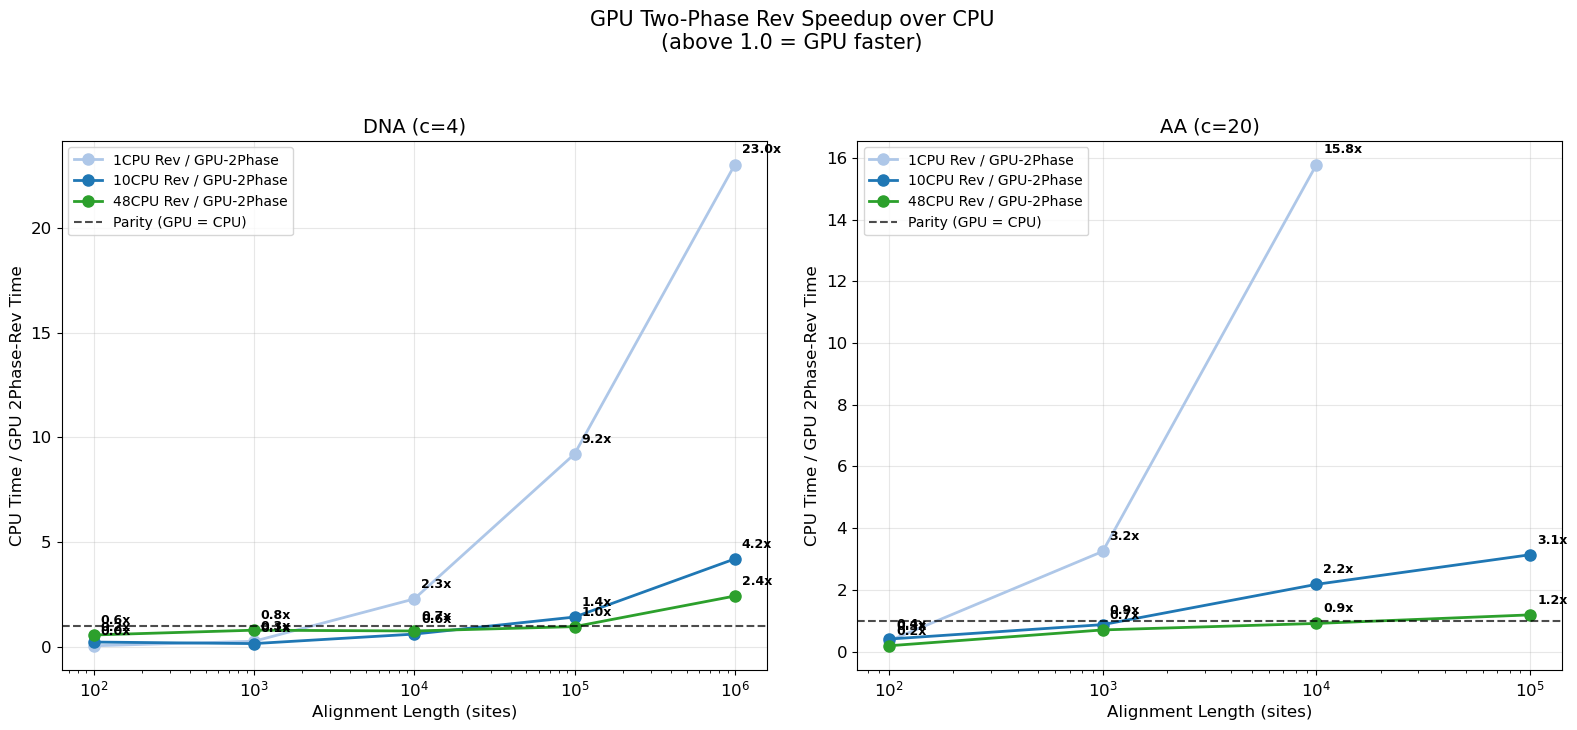

In [46]:
# GPU 2Phase-Rev speedup over each CPU backend
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cpu_configs = ['1CPU Rev', '10CPU Rev', '48CPU Rev']
cpu_colors = {'1CPU Rev': '#aec7e8', '10CPU Rev': '#1f77b4', '48CPU Rev': '#2ca02c'}

for ax, dtype, label in [(axes[0], 'DNA', 'DNA (c=4)'), (axes[1], 'AA', 'AA (c=20)')]:
    sub = df_full[df_full['data_type'] == dtype]
    gpu2p = sub[sub['config'] == 'GPU 2Phase-Rev'].set_index('length')['wall_time_sec'].to_dict()

    for cfg in cpu_configs:
        data = sub[sub['config'] == cfg].sort_values('length')
        if len(data) == 0: continue
        lens, ratios = [], []
        for _, row in data.iterrows():
            l = row['length']
            if l in gpu2p:
                lens.append(l)
                ratios.append(row['wall_time_sec'] / gpu2p[l])  # CPU/GPU > 1 = GPU faster
        if lens:
            ax.plot(lens, ratios, marker='o', color=cpu_colors[cfg],
                    label=f'{cfg} / GPU-2Phase', linewidth=2, markersize=8)
            for l, r in zip(lens, ratios):
                ax.annotate(f'{r:.1f}x', (l, r), textcoords='offset points',
                           xytext=(5, 8), ha='left', fontsize=9, fontweight='bold')

    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label='Parity (GPU = CPU)')
    ax.set_xscale('log')
    ax.set_xlabel('Alignment Length (sites)', fontsize=12)
    ax.set_ylabel('CPU Time / GPU 2Phase-Rev Time', fontsize=12)
    ax.set_title(label, fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('GPU Two-Phase Rev Speedup over CPU\n(above 1.0 = GPU faster)', fontsize=15, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'gpu_2phase_vs_cpu_speedup.png'), dpi=150, bbox_inches='tight')
plt.show()

## 31. Bar Chart: 1CPU, 10CPU, 48CPU Rev vs GPU Two-Phase Rev

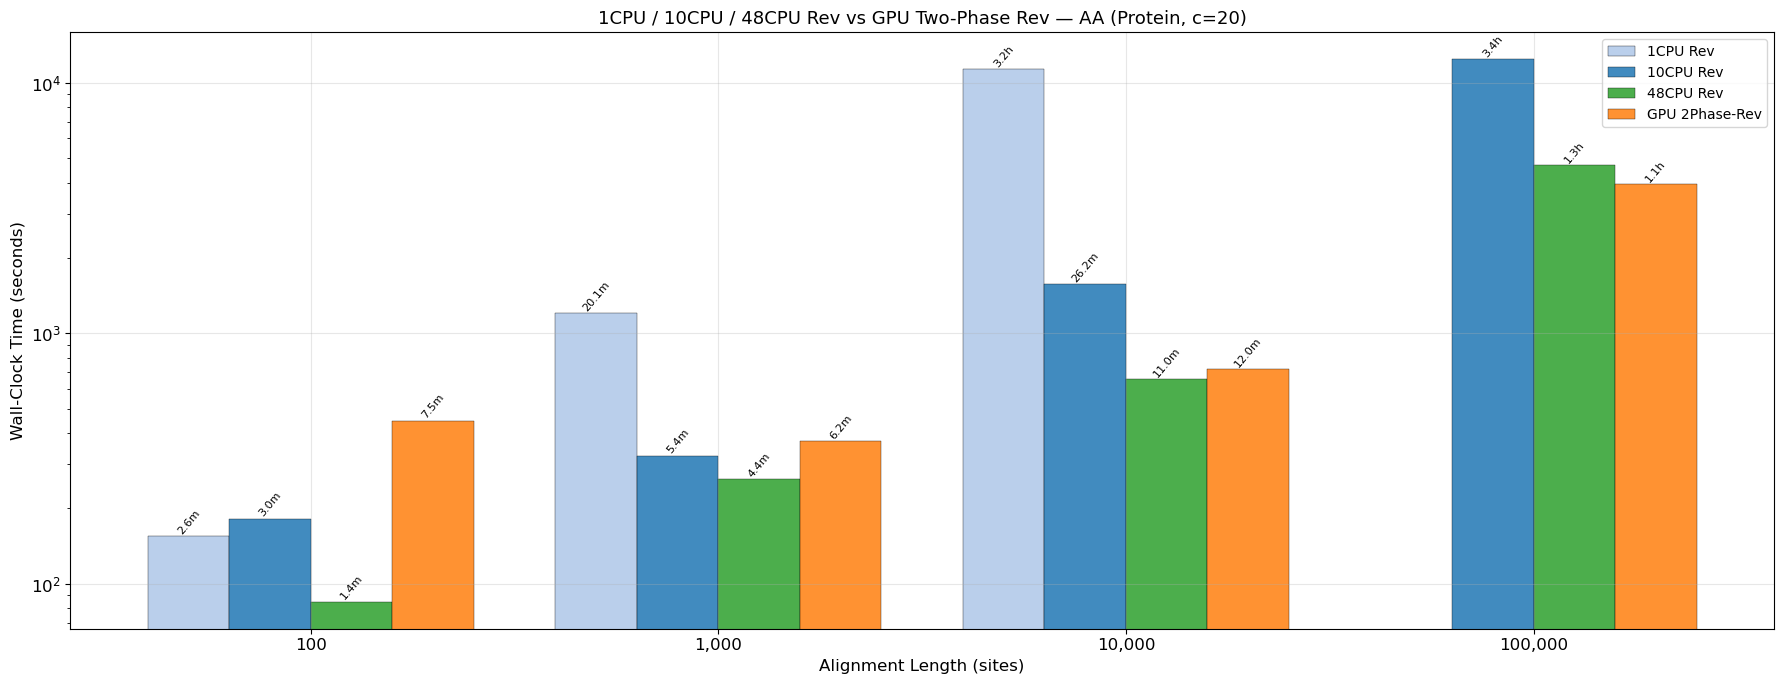

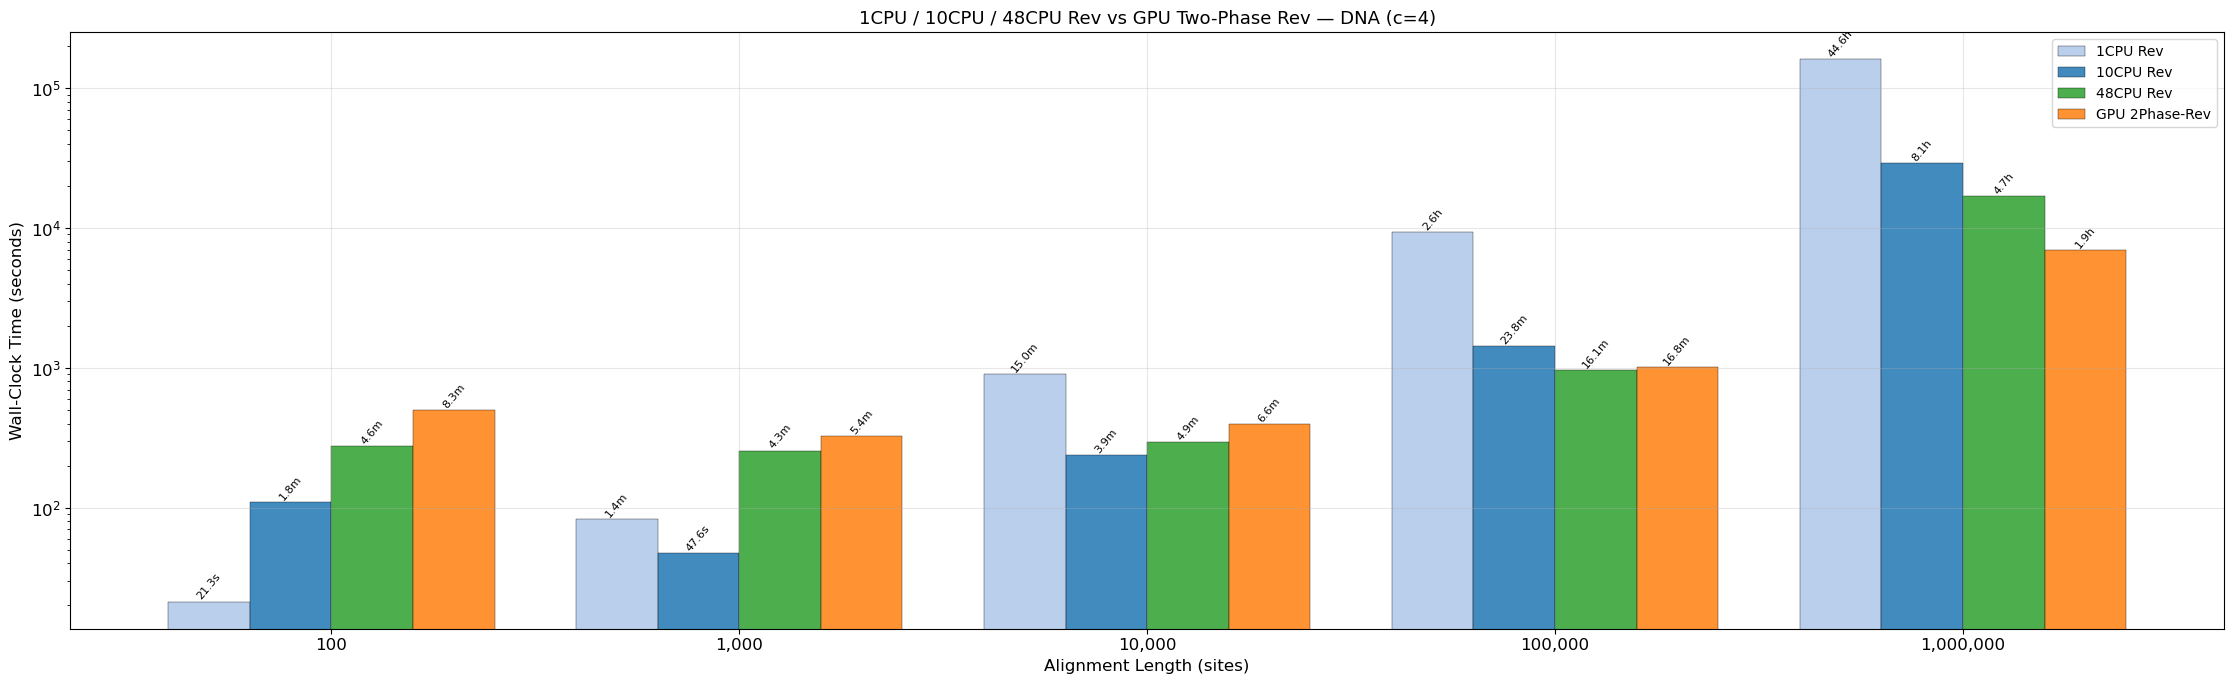

In [47]:
# Bar chart: 1CPU Rev, 10CPU Rev, 48CPU Rev, GPU 2Phase-Rev
compare_configs = ['1CPU Rev', '10CPU Rev', '48CPU Rev', 'GPU 2Phase-Rev']
compare_colors = {'1CPU Rev': '#aec7e8', '10CPU Rev': '#1f77b4',
                  '48CPU Rev': '#2ca02c', 'GPU 2Phase-Rev': '#ff7f0e'}

for dtype, label in [('AA', 'AA (Protein, c=20)'), ('DNA', 'DNA (c=4)')]:
    sub = df_full[df_full['data_type'] == dtype]
    lengths = sorted(sub['length'].unique())
    configs_present = [c for c in compare_configs if c in sub['config'].unique()]
    n_cfg = len(configs_present)
    n_len = len(lengths)

    fig, ax = plt.subplots(figsize=(4.5 * n_len, 7))
    x = np.arange(n_len)
    width = 0.8 / n_cfg

    for ci, cfg in enumerate(configs_present):
        times = []
        for length in lengths:
            row = sub[(sub['length'] == length) & (sub['config'] == cfg)]
            times.append(row['wall_time_sec'].values[0] if len(row) > 0 else 0)
        offset = (ci - n_cfg/2 + 0.5) * width
        bars = ax.bar(x + offset, times, width, label=cfg,
                      color=compare_colors.get(cfg, '#999'), alpha=0.85,
                      edgecolor='black', linewidth=0.3)
        for bar, val in zip(bars, times):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        fmt_time(val), ha='center', va='bottom', fontsize=8, rotation=50)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in lengths])
    ax.set_xlabel('Alignment Length (sites)', fontsize=12)
    ax.set_ylabel('Wall-Clock Time (seconds)', fontsize=12)
    ax.set_title(f'1CPU / 10CPU / 48CPU Rev vs GPU Two-Phase Rev — {label}', fontsize=13)
    ax.set_yscale('log')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_cpu_tiers_vs_gpu_2phase.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 32. Wall-Clock Time: Rev vs NonRev vs 2Phase — All Backends (AA & DNA)

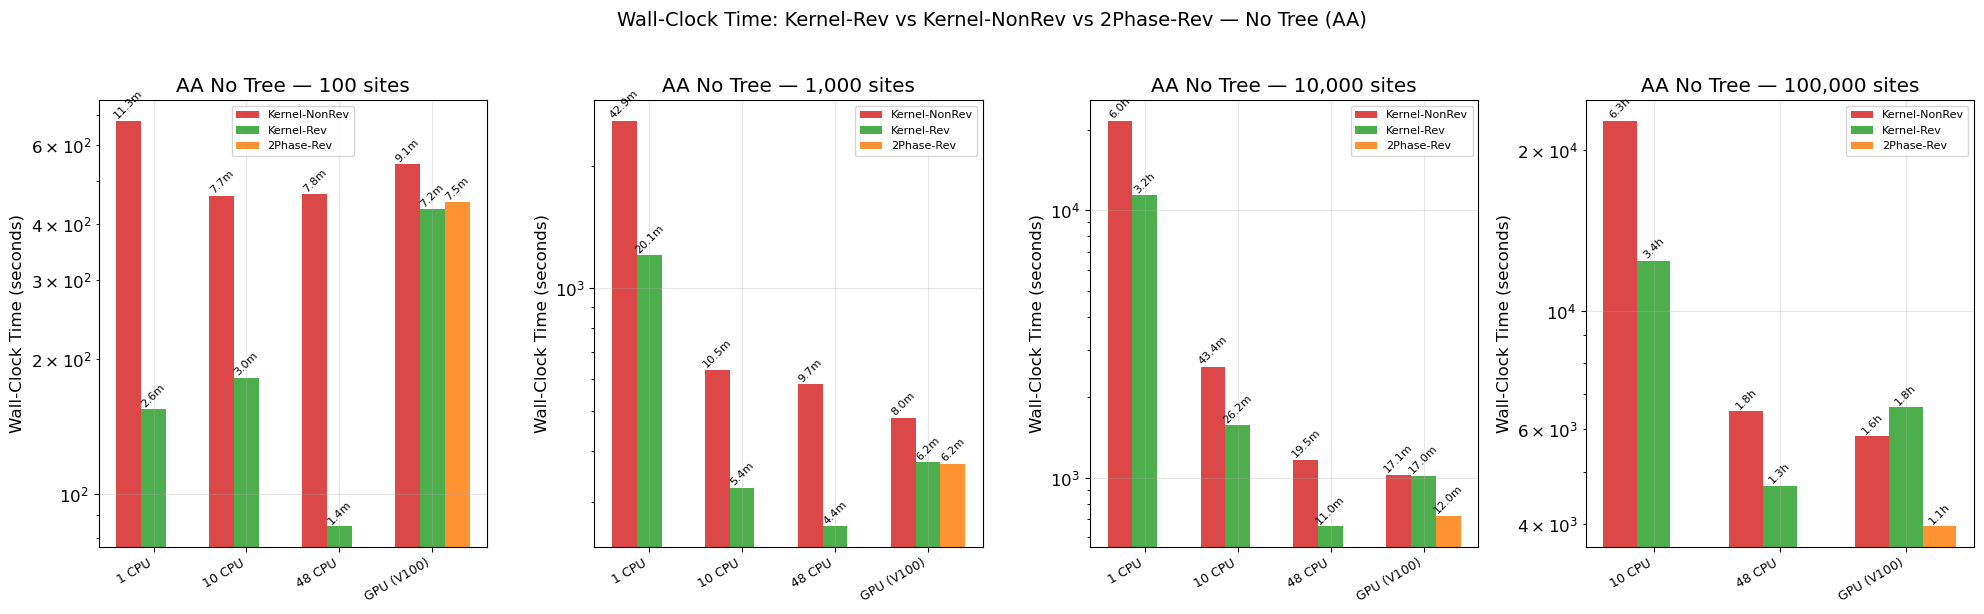

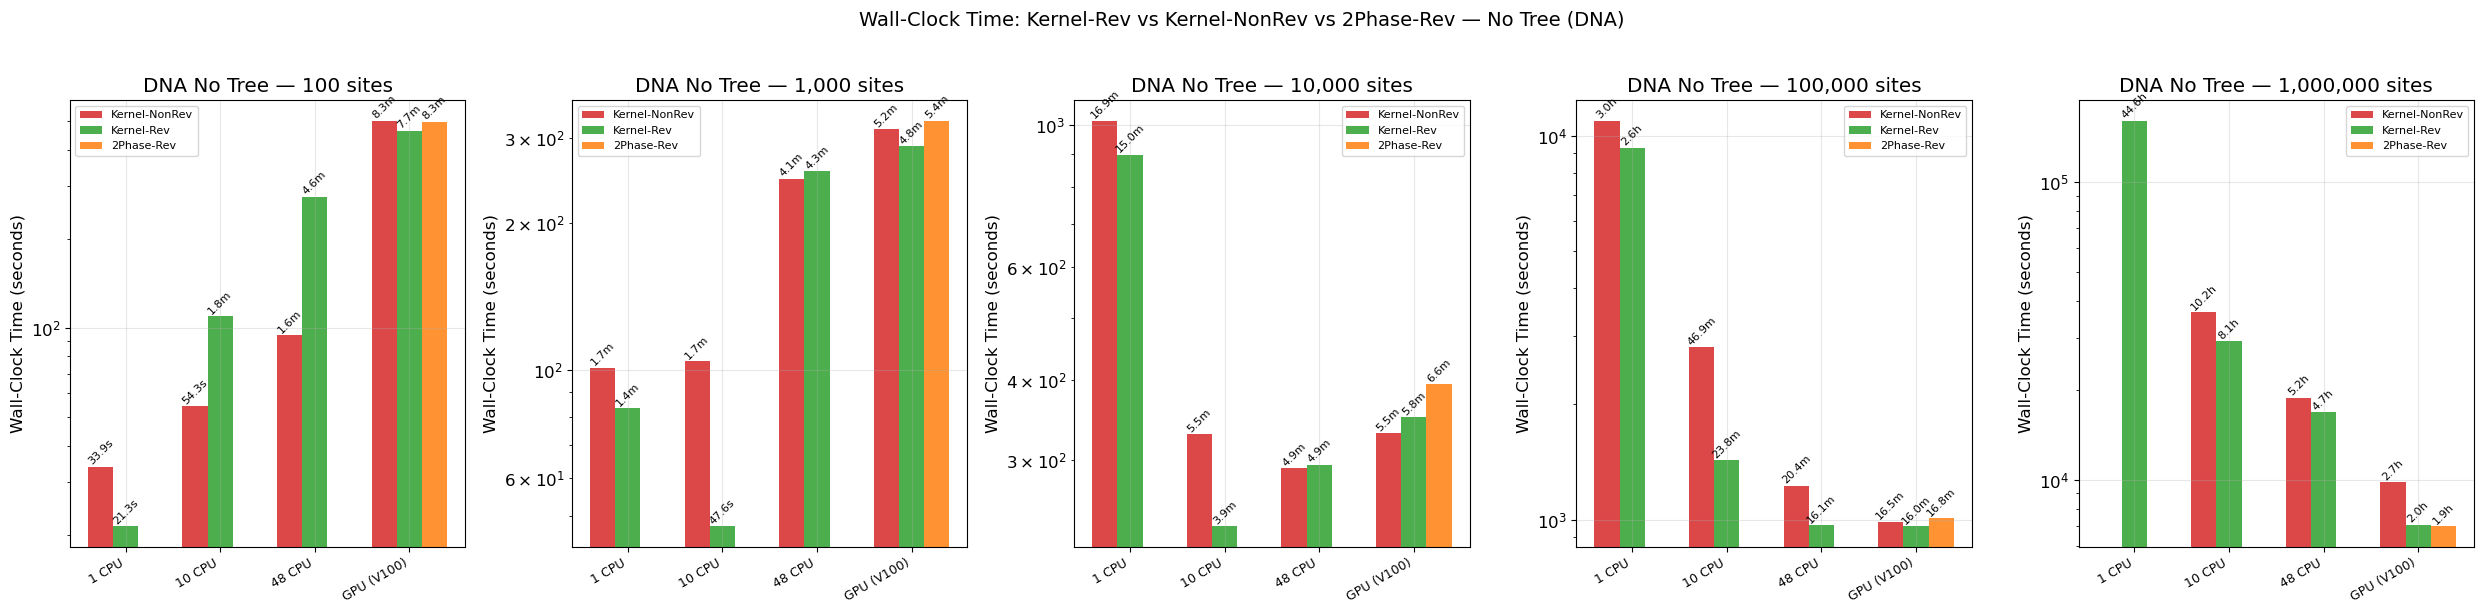

In [48]:
# Match the style of aa_notree_walltime_comparison.png
# One subplot per alignment length, x-axis = backends, grouped bars = kernel variants

backend_order_full = ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']

for dtype, label_prefix in [('AA', 'AA'), ('DNA', 'DNA')]:
    # Combine original no-tree + 2phase v1
    df_orig_dt = df[df['data_type'] == dtype].copy()
    df_2pv1_dt = df_2pv1[df_2pv1['data_type'] == dtype].copy()

    # Get all lengths that have data
    all_lengths = sorted(set(df_orig_dt['length'].unique()) | set(df_2pv1_dt['length'].unique()))
    # Filter to lengths that have at least some GPU data
    lengths_with_gpu = [l for l in all_lengths
                        if len(df_orig_dt[(df_orig_dt['length']==l) & (df_orig_dt['backend_label']=='GPU (V100)')]) > 0]

    n = len(lengths_with_gpu)
    if n == 0: continue

    fig, axes = plt.subplots(1, n, figsize=(5*n, 6), sharey=False)
    if n == 1: axes = [axes]

    kernel_labels_plot = ['Kernel-NonRev', 'Kernel-Rev', '2Phase-Rev']
    kernel_colors_plot = {'Kernel-NonRev': '#d62728', 'Kernel-Rev': '#2ca02c', '2Phase-Rev': '#ff7f0e'}
    kernel_display = {'Kernel-NonRev': 'Kernel-NonRev', 'Kernel-Rev': 'Kernel-Rev', '2Phase-Rev': '2Phase-Rev'}

    for ax, length in zip(axes, lengths_with_gpu):
        backends_present = []
        for b in backend_order_full:
            if len(df_orig_dt[(df_orig_dt['length']==length) & (df_orig_dt['backend_label']==b)]) > 0:
                backends_present.append(b)

        x = np.arange(len(backends_present))
        n_kern = 3  # NonRev, Rev, 2Phase
        width = 0.8 / n_kern

        for ki, kl in enumerate(kernel_labels_plot):
            times = []
            for b in backends_present:
                if kl == '2Phase-Rev':
                    # 2Phase only exists for GPU
                    if b == 'GPU (V100)':
                        r = df_2pv1_dt[(df_2pv1_dt['length']==length) & (df_2pv1_dt['kernel_label']=='2Pv1-Rev')]
                        times.append(r['wall_time_sec'].values[0] if len(r) > 0 else 0)
                    else:
                        times.append(0)
                else:
                    r = df_orig_dt[(df_orig_dt['length']==length) & (df_orig_dt['backend_label']==b) & (df_orig_dt['kernel_label']==kl)]
                    times.append(r['wall_time_sec'].values[0] if len(r) > 0 else 0)

            offset = (ki - n_kern/2 + 0.5) * width
            bars = ax.bar(x + offset, times, width, label=kernel_display[kl],
                          color=kernel_colors_plot[kl], alpha=0.85)
            for bar, val in zip(bars, times):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                            fmt_time(val), ha='center', va='bottom', fontsize=8, rotation=45)

        ax.set_xticks(x)
        ax.set_xticklabels([b.replace(' threads','').replace(' thread','') for b in backends_present],
                           rotation=30, ha='right', fontsize=9)
        ax.set_ylabel('Wall-Clock Time (seconds)')
        ax.set_title(f'{label_prefix} No Tree — {length:,} sites')
        ax.set_yscale('log')
        ax.legend(fontsize=8)

    plt.suptitle(f'Wall-Clock Time: Kernel-Rev vs Kernel-NonRev vs 2Phase-Rev — No Tree ({label_prefix})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_notree_walltime_with_2phase.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 8: Final GPU Two-Phase Results (rev/nonrev tags)

Latest Two-Phase GPU results with `output_fulltest_rev_*` and `output_fulltest_nonrev_*` tags.
Includes AA 100K sites.

## 33. Load Final GPU Results & Compare with All CPU Backends

In [49]:
# Load final rev/nonrev GPU results
def load_final_gpu_results():
    records = []
    for data_type in ['DNA', 'AA']:
        for length in [100, 1000, 10000, 100000, 1000000]:
            len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
            if not os.path.isdir(len_dir): continue
            for tag, klabel in [('rev', 'GPU-2P-Rev'), ('nonrev', 'GPU-2P-NonRev')]:
                pat = os.path.join(len_dir, f'output_fulltest_{tag}_{data_type}_*_OPENACC_*.iqtree')
                files = sorted(glob.glob(pat))
                if files:
                    data = parse_iqtree_file(files[0])
                    if data and 'wall_time_sec' in data:
                        data.update(length=length, kernel_label=klabel,
                                   backend_label='GPU (V100)', data_type=data_type)
                        records.append(data)
    return pd.DataFrame(records)

df_final_gpu = load_final_gpu_results()
print(f'Final GPU records: {len(df_final_gpu)}')
display(df_final_gpu[['data_type','length','kernel_label','best_model','log_likelihood','wall_time_sec']].sort_values(['data_type','length','kernel_label']))

Final GPU records: 18


,data_type,length,kernel_label,best_model,log_likelihood,wall_time_sec
11,AA,100,GPU-2P-NonRev,LG+G4,-7.670271e+03,549.6400
10,AA,100,GPU-2P-Rev,LG+G4,-7.670271e+03,430.0870
13,AA,1000,GPU-2P-NonRev,LG+G4,-7.782396e+04,475.0560
12,AA,1000,GPU-2P-Rev,LG+G4,-7.782396e+04,382.2540
15,AA,10000,GPU-2P-NonRev,LG+G4,-8.073500e+05,1059.9900
14,AA,10000,GPU-2P-Rev,LG+G4,-8.073500e+05,732.7110
17,AA,100000,GPU-2P-NonRev,LG+G4,-7.541977e+06,5866.0430
16,AA,100000,GPU-2P-Rev,LG+G4,-7.541977e+06,3994.5870
1,DNA,100,GPU-2P-NonRev,F81+F+ASC+G4,-4.894189e+03,478.4140
0,DNA,100,GPU-2P-Rev,F81+F+ASC+G4,-4.894189e+03,485.9870


In [50]:
# Full comparison: all CPU + old GPU fused + new GPU 2Phase
# Rebuild df_full with corrected backend naming
all_rows2 = []

# CPU no-tree results (all backends)
for _, row in df.iterrows():
    bl = row['backend_label']
    kl = row['kernel_label']
    short_b = bl.replace(' CPU threads', 'CPU').replace(' CPU thread', 'CPU').replace('GPU (V100)', 'GPU')
    short_k = kl.replace('Kernel-', '')
    all_rows2.append({
        'data_type': row['data_type'], 'length': row['length'],
        'config': f'{short_b} {short_k}',
        'wall_time_sec': row['wall_time_sec'],
    })

# New GPU 2Phase results (rename for clarity)
for _, row in df_final_gpu.iterrows():
    short_k = row['kernel_label'].replace('GPU-2P-', '')
    all_rows2.append({
        'data_type': row['data_type'], 'length': row['length'],
        'config': f'GPU-2P {short_k}',
        'wall_time_sec': row['wall_time_sec'],
    })

df_full2 = pd.DataFrame(all_rows2)

In [51]:
# Summary table
summary_final = []
for dtype in ['AA', 'DNA']:
    sub = df_full2[df_full2['data_type'] == dtype]
    for length in sorted(sub['length'].unique()):
        row = {'Type': dtype, 'Length': f'{length:,}'}
        for cfg in ['1CPU Rev', '10CPU Rev', '48CPU Rev', '48CPU NonRev',
                    'GPU Rev', 'GPU NonRev', 'GPU-2P Rev', 'GPU-2P NonRev']:
            r = sub[(sub['length']==length) & (sub['config']==cfg)]
            if len(r) > 0: row[cfg] = round(r['wall_time_sec'].values[0], 1)
        if 'GPU-2P Rev' in row and '48CPU Rev' in row:
            ratio = row['GPU-2P Rev'] / row['48CPU Rev']
            tag = 'GPU!' if ratio < 1 else 'CPU'
            row['2P vs 48CPU'] = f'{ratio:.2f}x ({tag})'
        if 'GPU-2P Rev' in row and 'GPU Rev' in row:
            row['2P vs Fused'] = f"{row['GPU Rev']/row['GPU-2P Rev']:.2f}x"
        summary_final.append(row)

df_sf = pd.DataFrame(summary_final)
key_cols = ['Type','Length','1CPU Rev','10CPU Rev','48CPU Rev','GPU Rev','GPU-2P Rev','2P vs Fused','2P vs 48CPU']
key_cols = [c for c in key_cols if c in df_sf.columns]
print('=== Final: CPU Rev vs GPU Fused Rev vs GPU Two-Phase Rev ===')
display(df_sf[key_cols])

=== Final: CPU Rev vs GPU Fused Rev vs GPU Two-Phase Rev ===


,Type,Length,1CPU Rev,10CPU Rev,48CPU Rev,GPU Rev,GPU-2P Rev,2P vs Fused,2P vs 48CPU
0,AA,100,154.8,181.9,84.9,431.9,430.1,1.00x,5.07x (CPU)
1,AA,"1,000",1207.2,325.0,261.2,374.9,382.3,0.98x,1.46x (CPU)
2,AA,"10,000",11376.1,1571.8,658.1,1017.8,732.7,1.39x,1.11x (CPU)
3,AA,"100,000",NaN,12406.6,4704.7,6608.4,3994.6,1.65x,0.85x (GPU!)
4,DNA,100,21.3,109.6,277.3,463.5,486.0,0.95x,1.75x (CPU)
5,DNA,"1,000",83.3,47.6,255.8,288.2,312.6,0.92x,1.22x (CPU)
6,DNA,"10,000",898.4,236.6,295.3,350.5,373.3,0.94x,1.26x (CPU)
7,DNA,"100,000",9299.0,1429.4,967.3,960.5,987.1,0.97x,1.02x (CPU)
8,DNA,"1,000,000",160646.4,29249.8,16874.5,7071.2,6918.6,1.02x,0.41x (GPU!)


## 34. Wall-Clock Bar Charts: All Backends + GPU Two-Phase

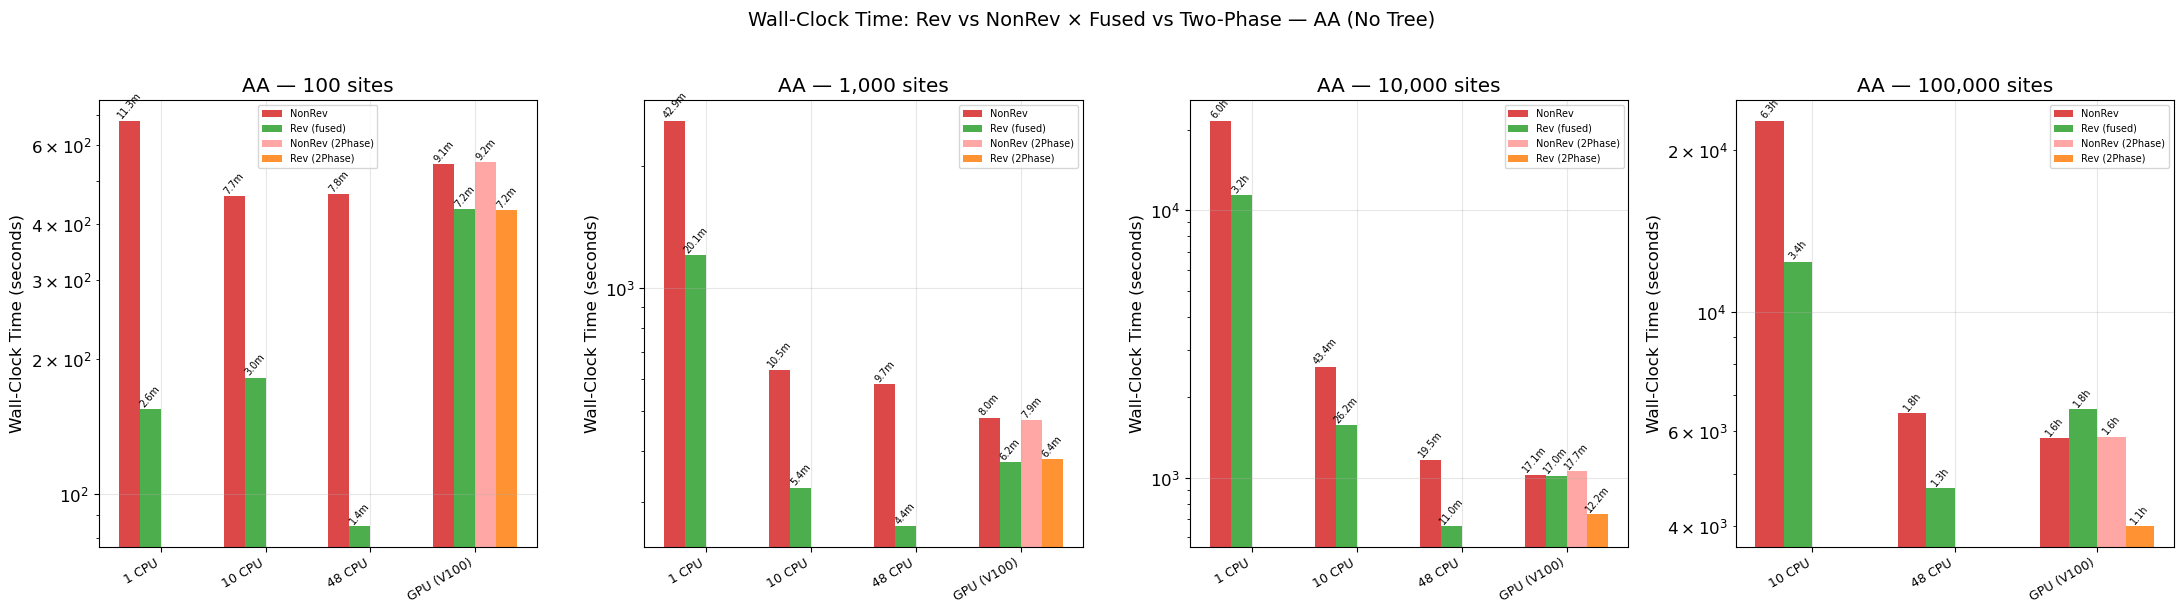

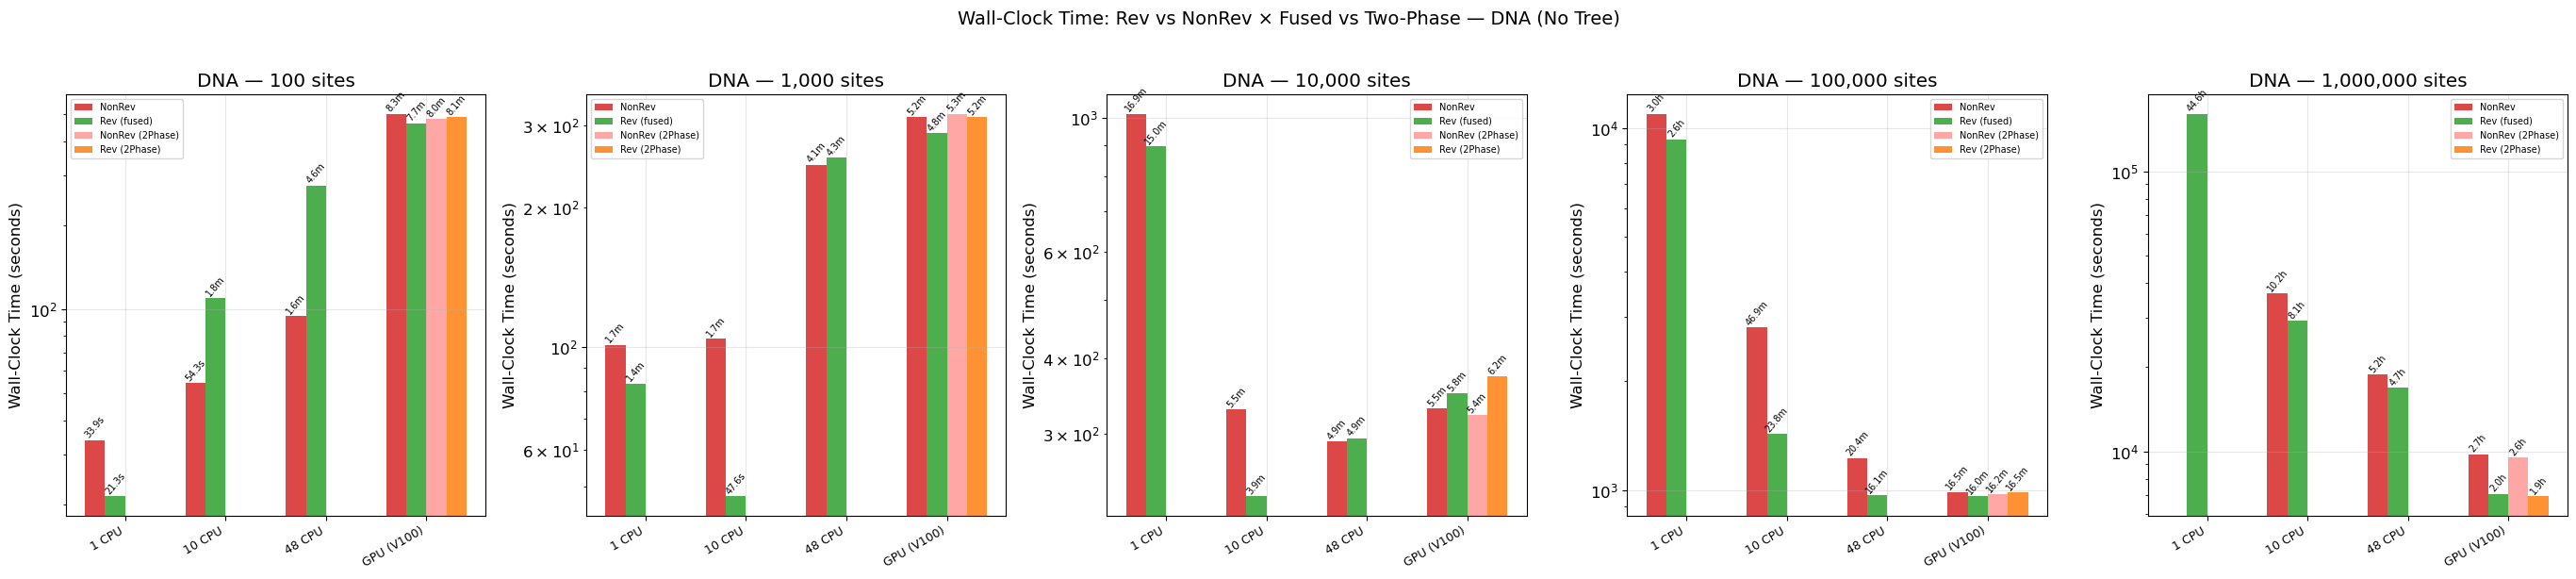

In [52]:
# Bar chart: all backends, 4 kernel variants
# CPU: NonRev + Rev (fused, same as always)
# GPU: Fused-NonRev + Fused-Rev + 2Phase-NonRev + 2Phase-Rev

backend_order_plot = ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']

for dtype, label_prefix in [('AA', 'AA'), ('DNA', 'DNA')]:
    df_orig_dt = df[df['data_type'] == dtype].copy()
    df_gpu_dt = df_final_gpu[df_final_gpu['data_type'] == dtype].copy()

    all_lengths = sorted(set(df_orig_dt['length'].unique()) | set(df_gpu_dt['length'].unique()))
    lengths_with_gpu = [l for l in all_lengths
                        if len(df_orig_dt[(df_orig_dt['length']==l) & (df_orig_dt['backend_label']=='GPU (V100)')]) > 0
                        or len(df_gpu_dt[df_gpu_dt['length']==l]) > 0]

    n = len(lengths_with_gpu)
    if n == 0: continue

    fig, axes = plt.subplots(1, n, figsize=(5.5*n, 6), sharey=False)
    if n == 1: axes = [axes]

    # 4 kernel variants
    kernel_list = ['Kernel-NonRev', 'Kernel-Rev', 'GPU-2P-NonRev', 'GPU-2P-Rev']
    kcolors = {'Kernel-NonRev': '#d62728', 'Kernel-Rev': '#2ca02c',
               'GPU-2P-NonRev': '#ff9896', 'GPU-2P-Rev': '#ff7f0e'}
    kdisplay = {'Kernel-NonRev': 'NonRev', 'Kernel-Rev': 'Rev (fused)',
                'GPU-2P-NonRev': 'NonRev (2Phase)', 'GPU-2P-Rev': 'Rev (2Phase)'}

    for ax, length in zip(axes, lengths_with_gpu):
        backends_present = []
        for b in backend_order_plot:
            if len(df_orig_dt[(df_orig_dt['length']==length) & (df_orig_dt['backend_label']==b)]) > 0:
                backends_present.append(b)

        x = np.arange(len(backends_present))
        # CPU positions get 2 bars (NR + Rev), GPU gets 4 bars
        n_kern = 4
        width = 0.8 / n_kern

        for ki, kl in enumerate(kernel_list):
            times = []
            for b in backends_present:
                if kl.startswith('GPU-2P'):
                    # 2Phase only at GPU position
                    if b == 'GPU (V100)':
                        r = df_gpu_dt[(df_gpu_dt['length']==length) & (df_gpu_dt['kernel_label']==kl)]
                        times.append(r['wall_time_sec'].values[0] if len(r) > 0 else 0)
                    else:
                        times.append(0)
                else:
                    r = df_orig_dt[(df_orig_dt['length']==length) & (df_orig_dt['backend_label']==b) & (df_orig_dt['kernel_label']==kl)]
                    times.append(r['wall_time_sec'].values[0] if len(r) > 0 else 0)

            offset = (ki - n_kern/2 + 0.5) * width
            bars = ax.bar(x + offset, times, width, label=kdisplay[kl],
                          color=kcolors[kl], alpha=0.85)
            for bar, val in zip(bars, times):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                            fmt_time(val), ha='center', va='bottom', fontsize=7, rotation=50)

        ax.set_xticks(x)
        ax.set_xticklabels([b.replace(' threads','').replace(' thread','') for b in backends_present],
                           rotation=30, ha='right', fontsize=9)
        ax.set_ylabel('Wall-Clock Time (seconds)')
        ax.set_title(f'{label_prefix} — {length:,} sites')
        ax.set_yscale('log')
        ax.legend(fontsize=7)

    plt.suptitle(f'Wall-Clock Time: Rev vs NonRev × Fused vs Two-Phase — {label_prefix} (No Tree)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_final_walltime_all_backends.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

In [53]:
# Correctness check
print('=== Log-Likelihood: Final GPU 2Phase vs Fused Baseline ===')
for dtype in ['DNA', 'AA']:
    print(f'\n--- {dtype} ---')
    df_gf = df_final_gpu[df_final_gpu['data_type'] == dtype]
    df_orig_gpu = df[(df['data_type'] == dtype) & (df['backend_label'] == 'GPU (V100)')]
    for length in sorted(df_gf['length'].unique()):
        results = {}
        for kl, tag in [('Kernel-Rev', 'Fused-Rev'), ('Kernel-NonRev', 'Fused-NR')]:
            r = df_orig_gpu[(df_orig_gpu['length']==length) & (df_orig_gpu['kernel_label']==kl)]
            if len(r) > 0: results[tag] = r['log_likelihood'].values[0]
        for kl, tag in [('GPU-2P-Rev', '2P-Rev'), ('GPU-2P-NonRev', '2P-NR')]:
            r = df_gf[(df_gf['length']==length) & (df_gf['kernel_label']==kl)]
            if len(r) > 0: results[tag] = r['log_likelihood'].values[0]
        diffs = []
        for a, b in [('Fused-Rev','2P-Rev'),('Fused-NR','2P-NR')]:
            if a in results and b in results:
                diffs.append(f'{a} vs {b}: {abs(results[a]-results[b]):.4f}')
        print(f'  len={length:>8,}: ' + ', '.join(diffs))

=== Log-Likelihood: Final GPU 2Phase vs Fused Baseline ===

--- DNA ---
  len=     100: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000
  len=   1,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000
  len=  10,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000
  len= 100,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000
  len=1,000,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000

--- AA ---
  len=     100: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000
  len=   1,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000
  len=  10,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000
  len= 100,000: Fused-Rev vs 2P-Rev: 0.0000, Fused-NR vs 2P-NR: 0.0000


## 35. CPU NonRev/Rev vs GPU Two-Phase NonRev/Rev

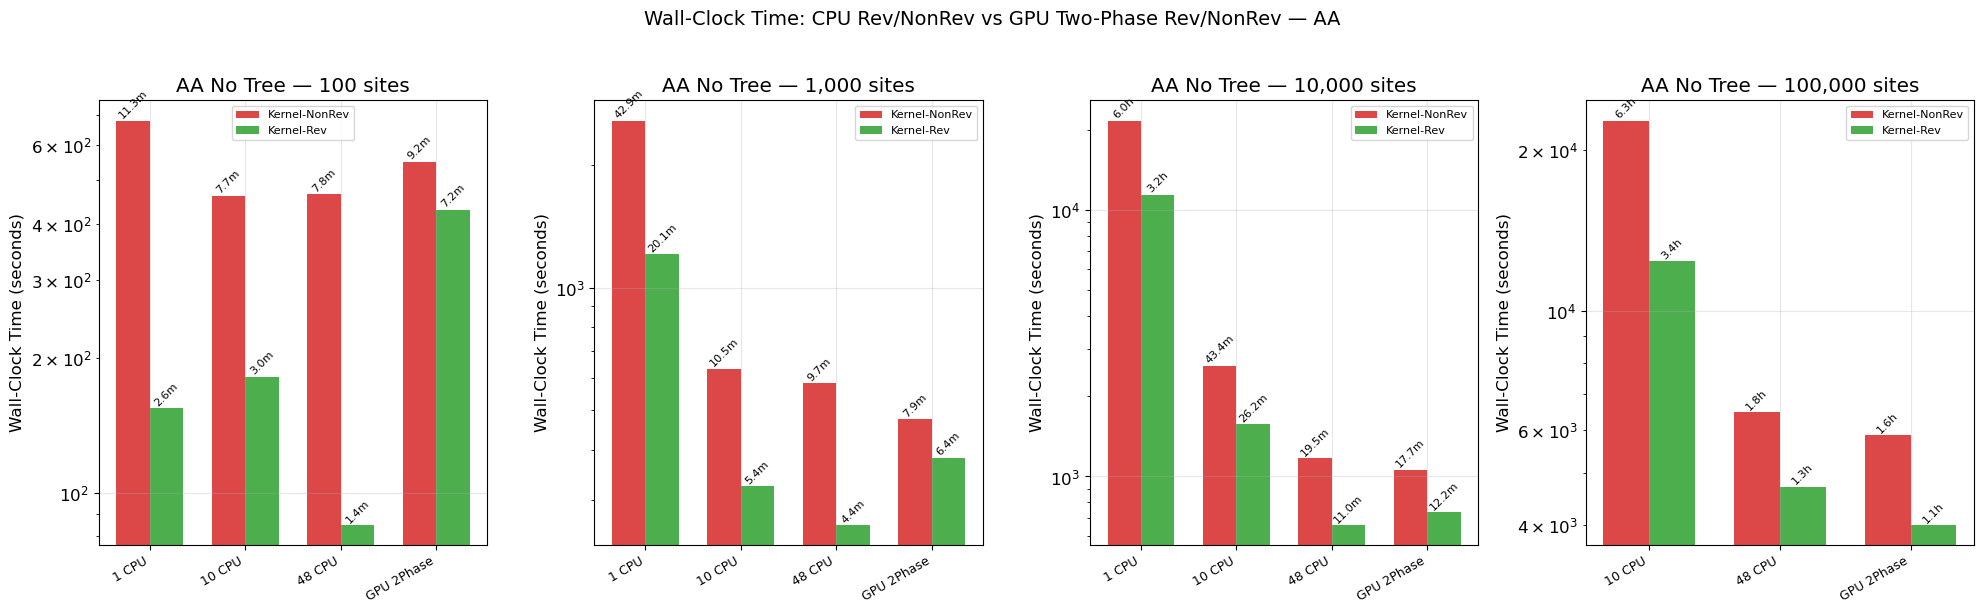

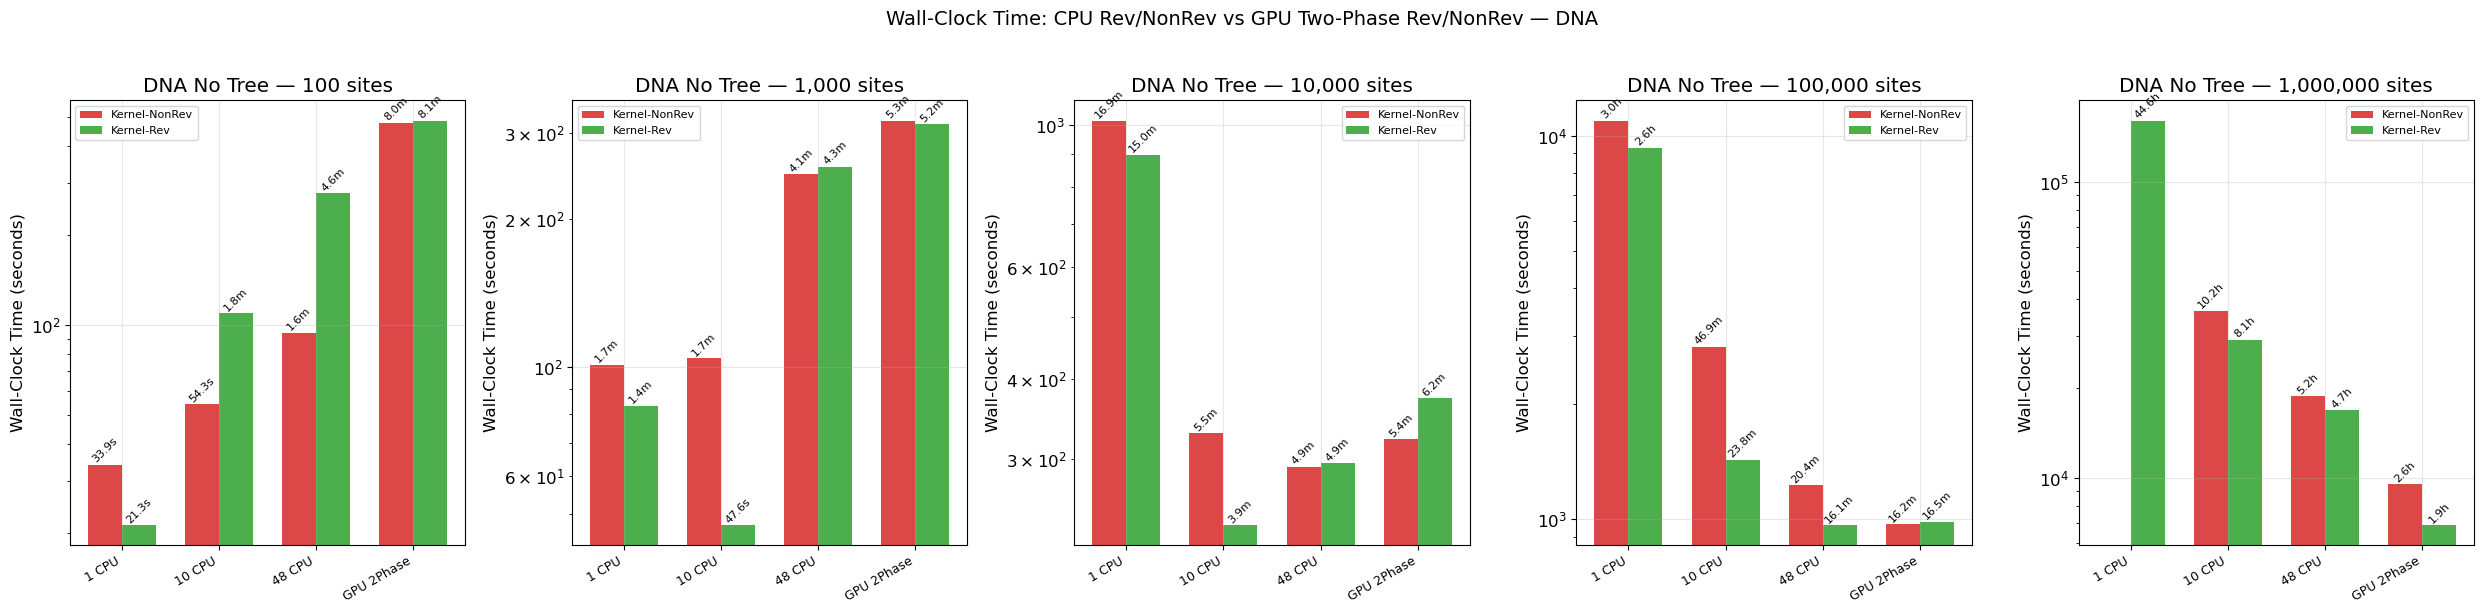

In [54]:
# Bar chart: CPU NonRev + Rev (fused) vs GPU 2Phase NonRev + Rev
# Each backend gets 2 bars: NonRev (red) + Rev (green)
# Backends: 1CPU, 10CPU, 48CPU, GPU-2Phase

for dtype, label_prefix in [('AA', 'AA'), ('DNA', 'DNA')]:
    df_orig_dt = df[df['data_type'] == dtype].copy()
    df_gpu_dt = df_final_gpu[df_final_gpu['data_type'] == dtype].copy()

    all_lengths = sorted(set(df_orig_dt['length'].unique()) | set(df_gpu_dt['length'].unique()))
    lengths_plot = [l for l in all_lengths
                    if len(df_gpu_dt[df_gpu_dt['length']==l]) > 0]

    n = len(lengths_plot)
    if n == 0: continue

    fig, axes = plt.subplots(1, n, figsize=(5*n, 6), sharey=False)
    if n == 1: axes = [axes]

    # Backends: CPU tiers + GPU-2Phase as a single backend
    backend_list = ['1 CPU', '10 CPU', '48 CPU', 'GPU 2Phase']

    for ax, length in zip(axes, lengths_plot):
        backends_present = []
        for b in backend_list:
            if b == 'GPU 2Phase':
                if len(df_gpu_dt[df_gpu_dt['length']==length]) > 0:
                    backends_present.append(b)
            else:
                bl_full = b.replace('1 CPU','1 CPU thread').replace('10 CPU','10 CPU threads').replace('48 CPU','48 CPU threads')
                if len(df_orig_dt[(df_orig_dt['length']==length) & (df_orig_dt['backend_label']==bl_full)]) > 0:
                    backends_present.append(b)

        x = np.arange(len(backends_present))
        width = 0.35

        nonrev_times = []
        rev_times = []
        for b in backends_present:
            if b == 'GPU 2Phase':
                r_nr = df_gpu_dt[(df_gpu_dt['length']==length) & (df_gpu_dt['kernel_label']=='GPU-2P-NonRev')]
                r_rev = df_gpu_dt[(df_gpu_dt['length']==length) & (df_gpu_dt['kernel_label']=='GPU-2P-Rev')]
            else:
                bl_full = b.replace('1 CPU','1 CPU thread').replace('10 CPU','10 CPU threads').replace('48 CPU','48 CPU threads')
                r_nr = df_orig_dt[(df_orig_dt['length']==length) & (df_orig_dt['backend_label']==bl_full) & (df_orig_dt['kernel_label']=='Kernel-NonRev')]
                r_rev = df_orig_dt[(df_orig_dt['length']==length) & (df_orig_dt['backend_label']==bl_full) & (df_orig_dt['kernel_label']=='Kernel-Rev')]
            nonrev_times.append(r_nr['wall_time_sec'].values[0] if len(r_nr) > 0 else 0)
            rev_times.append(r_rev['wall_time_sec'].values[0] if len(r_rev) > 0 else 0)

        bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev',
                       color='#d62728', alpha=0.85)
        bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev',
                       color='#2ca02c', alpha=0.85)

        for bar, val in zip(bars1, nonrev_times):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        fmt_time(val), ha='center', va='bottom', fontsize=8, rotation=45)
        for bar, val in zip(bars2, rev_times):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        fmt_time(val), ha='center', va='bottom', fontsize=8, rotation=45)

        ax.set_xticks(x)
        ax.set_xticklabels(backends_present, rotation=30, ha='right', fontsize=9)
        ax.set_ylabel('Wall-Clock Time (seconds)')
        ax.set_title(f'{label_prefix} No Tree — {length:,} sites')
        ax.set_yscale('log')
        ax.legend(fontsize=8)

    plt.suptitle(f'Wall-Clock Time: CPU Rev/NonRev vs GPU Two-Phase Rev/NonRev — {label_prefix}',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_cpu_vs_gpu2phase_revnonrev.png'),
                dpi=150, bbox_inches='tight')
    plt.show()